# Fig.4 : WT vs ML2 - Thermal activity

In [1]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import pingouin as pg
import scikit_posthocs as sp
import h5py
import zarr
import logging

from pathlib import Path
from numpy import typing as npt
from typing import TYPE_CHECKING
from matplotlib import rcParams
from scipy.stats import sem, wilcoxon, shapiro, mannwhitneyu, chi2_contingency, fisher_exact
from scipy.signal import butter, filtfilt, savgol_filter 
from itertools import combinations
from scipy.stats import sem


### Directory for fig saving

In [2]:
# Définir le chemin de base et le répertoire à créer
base_dir = "U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/spyking_analysis/plot_for_fig/Plot_svg_illustrator"
saving_dir = os.path.join(base_dir, "Plot_Fig_4_WT_vs_ML2_Thq")

# Vérifier si le répertoire existe, sinon le créer
if not os.path.exists(saving_dir):
    os.makedirs(saving_dir)
    print(f"Le répertoire '{saving_dir}' a été créé avec succès.")
else:
    print(f"Le répertoire '{saving_dir}' existe déjà.")

Le répertoire 'U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/spyking_analysis/plot_for_fig/Plot_svg_illustrator\Plot_Fig_4_WT_vs_ML2_Thq' existe déjà.


For svg texte

In [3]:
# Forcer l'utilisation du texte en tant que texte dans SVG
rcParams['svg.fonttype'] = 'none'
rcParams['font.family'] = 'Myriad Pro'

# plt.rcParams.update({
#     'axes.labelsize': 16,   # Taille des labels des axes
#     'xtick.labelsize': 16,  # Taille des labels des ticks sur l'axe x
#     'ytick.labelsize': 16,  # Taille des labels des ticks sur l'axe y
#     'legend.fontsize': 10   # Taille de la police de la légende
# })

plt.rcParams.update({
    'axes.labelsize': 20,   # Taille des labels des axes
    'xtick.labelsize': 18,  # Taille des labels des ticks sur l'axe x
    'ytick.labelsize': 18,  # Taille des labels des ticks sur l'axe y
    'legend.fontsize': 12   # Taille de la police de la légende
})

#

### Fig 4.B - Exemple rec for ML2 thermic cool stim one shank

In [13]:
# Data file path
data_path = "U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/Converter_circus"
sel_folder = "2024.02.29"
sel_rec = 'allego_7__uid0229-15-01-23'

full_folder = os.path.join(data_path, sel_folder, sel_rec)
print (f'path for full folder : {full_folder}')

if os.path.exists(full_folder):
    print(f"Le dossier existe: {full_folder}")
else:
    print(f"Le dossier n'existe pas: {full_folder}")


# .dat file Path
dat_file = sel_rec + '_spy.dat'
# print(dat_file)

dat_file_path = os.path.join (full_folder,dat_file)
print (f'\npath for .dat : {dat_file_path}')


# Zarr and lfp data path
zarr_path = 'U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/Analysis_stef'
zarr_folder = sel_folder
zarr_file = sel_rec 
# zarr_file = sel_rec + '_spy'
zarr_folder_path = os.path.join(zarr_path, zarr_folder, zarr_file)

    # Vérification que le chemin est correct
print(f"\nzarr file path : {zarr_folder_path}")

    # Ouvrir les fichiers zarr
raw_data = zarr.open(os.path.join(zarr_folder_path, 'raw', 'dataset.zarr'), mode="r")
ephys_res = zarr.open(os.path.join(zarr_folder_path, 'processed', 'ephys.zarr'), mode="r")

# Affichage de quelques informations sur les datasets
print(f"Contenu de raw_data : {list(raw_data.keys())}")
print(f"Contenu de ephys_res : {list(ephys_res.keys())}")


# Circus sorting path
sorting_fold = os.path.join(full_folder, sel_rec +'_spy')
sorting_path = Path(sorting_fold)
print (f'\npath for circus sorting : {sorting_path}')

gui_fold = os.path.join(sorting_fold, sel_rec + '_spy.GUI')
gui_path = Path(gui_fold)
print (f'\npath for circus-GUI : {gui_fold}')


# cluster_info.tsv file path
clusinfo_path = os.path.join(gui_fold, 'cluster_info.tsv')

# Vérifier si le fichier existe avant de tenter de le lire
if os.path.exists(clusinfo_path):
    print ('')
    clusinfo_df = pd.read_csv(clusinfo_path, sep='\t')  # Fichier tabulé
else:
    raise FileNotFoundError(f"Fichier introuvable : {clusinfo_path}")


path for full folder : U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/Converter_circus\2024.02.29\allego_7__uid0229-15-01-23
Le dossier existe: U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/Converter_circus\2024.02.29\allego_7__uid0229-15-01-23

path for .dat : U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/Converter_circus\2024.02.29\allego_7__uid0229-15-01-23\allego_7__uid0229-15-01-23_spy.dat

zarr file path : U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/Analysis_stef\2024.02.29\allego_7__uid0229-15-01-23
Contenu de raw_data : ['adcs', 'channels']
Contenu de ephys_res : ['down_fact', 'lfps', 'sample_rate']

path for circus sorting : U:\PhD\Experimentation\Electrophysiology\S1_recordings_Analysis\Converter_circus\2024.02.29\allego_7__uid0229-15-01-23\allego_7__uid0229-15-01-23_spy

path for circus-GUI : U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/Converter_circus\2024.02.29\allego_7__uid0229-15

In [14]:
####### LFPs + ADCs from zarr #######
mapping = np.load(gui_fold + "/channel_map.npy").reshape(-1, 8)
lfps = ephys_res["lfps/channels/1"][:]
lfps -= np.median(lfps, axis=0)
adcs = ephys_res["lfps/adcs/1"][:]
stim_present = (adcs[1,:] > 1).astype(int)
t_lfps = ephys_res["lfps/timestamps/1"][:]
srate_acq = (t_lfps.size - 1) / (t_lfps[-1] - t_lfps[0])
np.sum(adcs[0,:]>3.) > t_lfps.size/2
select_times = np.logical_and(t_lfps>115., t_lfps< 135.)

####### Sampling rate for acquisition #######
f_sample_raw = 30000.0


####### Création du dataset pour spiketimes et amplitudes #######
dataset = {}
merged = list(sorting_path.glob("*.result.hdf5"))

if len(merged) != 1:
    logging.warning("Several or none .result.hdf5 file detected. Aborting!")
else:
    with h5py.File(merged[0], "r") as spike_in:
        dataset["spiketimes"] = {}
        dataset["amplitudes"] = {}  # Ajout pour les amplitudes

        for temp in spike_in["spiketimes"].items():
            # Extraction des données de spiketimes
            spiketimes_data = temp[1][:] / f_sample_raw
            dataset["spiketimes"][temp[0]] = spiketimes_data

            # Vérification de la présence d'amplitudes
            if "amplitudes" in spike_in:
                amplitudes_data = spike_in["amplitudes"][temp[0]][:]
                dataset["amplitudes"][temp[0]] = amplitudes_data
            else:
                logging.warning(f"No amplitudes found for {temp[0]}")


####### Selection des neurones valides ######
# Filtrer les neurones valides
valid_df = clusinfo_df.loc[clusinfo_df['group'].isin(['good', 'mua'])]

# Liste des neurones valides (pas les index, mais les valeurs)
valid_all = valid_df['cluster_id'].tolist()

# Récupérer les neurones valides par shank
n_shanks = 4
valid_per_sh = {}
for i_sh in range(n_shanks):
    valid_inds = valid_df.loc[valid_df['sh'] == float(i_sh), 'cluster_id'].tolist()
    valid_per_sh[f'sh#{i_sh}'] = valid_inds

# On transforme les indices dans valid_all en clés correspondant aux sous-clés 'temp_x'
valid_keys = [f'temp_{i}' for i in valid_all]

####### Here we infer the temperature timecourse #######
if TYPE_CHECKING:
    # Type annotations
    Abool = npt.NDArray[np.bool_]
    Afloat = npt.NDArray[np.float64]
    Aint = npt.NDArray[np.int_]


def infer_stim_times(stim_signal, tstamp, th_dur=15.0):

    """Infer stimulus start/stop times from the stimulus signal ttl.

    Args:
        stim_signal (Afloat): stimulus signal ttl .
        t_lfps (Afloat): tstemp of the lfp.
        th_dur (float): duration threshold (in seconds) to infer valid times

    Returns:
        tuple(Afloat): stimulus start times, stimulus end times.

    """

    up_inds = np.where(np.diff(stim_signal) > 0.5)[0][1:] # stim signal goes up, excluding recording start
    down_inds = np.where(np.diff(stim_signal) < -0.5)[0][1:] # stim signal goes down, excluding recording start
    
    t_up = tstamp[up_inds]
    t_down = tstamp[down_inds]
    
    valid_up = np.diff(t_up) > th_dur # this is 15. seconds 
    valid_up = np.concatenate(([True], valid_up)) # the first up is always valid
    
    valid_down = np.diff(t_down) > th_dur
    valid_down = np.concatenate((valid_down, [True])) # the last down is always valid
    
    # n_stims = np.sum(valid_up)
    
    t_stim_start = t_up[valid_up]
    t_stim_end = t_down[valid_down]

    return t_stim_start, t_stim_end


t_stim_start, t_stim_end = infer_stim_times(stim_signal=stim_present, 
                                                tstamp=t_lfps)

n_stims = t_stim_start.size

valid_temp_profile = np.max(adcs[0,:]) > 2.0

if valid_temp_profile:
    
    therm_stim = 10. * adcs[0,:]

else:
    # Load the temperature profile file
    temp_file = 'U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/Analysis_stef/temp15_mean_profile.xlsx'
    temp_df = pd.read_excel(temp_file)
    temp_profile = temp_df['Temperature'].values
    n_temps = temp_profile.size

    time_interp = [np.linspace(t_stim_start[i], t_stim_end[i], n_temps) for  i in range(n_stims)]
    time_interp = np.hstack(time_interp)
    temp_interp = np.tile(temp_profile, n_stims)
    therm_stim = np.interp(t_lfps, time_interp, temp_interp)



####### Infer ascending and descending phases #######
thr_temp = 34

descending_start = t_stim_start  # this correspons to the beginning of the descending phase of the stimulus, thus with the beginning of the stimulus
descending_end = np.zeros(n_stims)
ascending_start = np.zeros(n_stims)
ascending_end = np.zeros(n_stims)

for i in range(n_stims):
    mask = t_lfps > t_stim_start[i]
    mask &= t_lfps < t_stim_end[i]
    ther_sel = therm_stim[mask]
    descending_end[i] = t_stim_start[i] + t_lfps[np.argmin(ther_sel)]
    mask_asc = ther_sel > thr_temp
    ind_end = np.where(mask_asc==True)[0][0]
    ascending_end[i] = t_stim_start[i] + t_lfps[ind_end]
ascending_start = descending_end
thr_temp = 34

descending_start = t_stim_start  # Correspond au début de la phase descendante du stimulus
descending_end = np.zeros(n_stims)  # Initialisation de la fin de la phase descendante
ascending_start = np.zeros(n_stims)  # Initialisation du début de la phase ascendante
ascending_end = np.zeros(n_stims)  # Initialisation de la fin de la phase ascendante

for i in range(n_stims):
    mask = t_lfps > t_stim_start[i]
    mask &= t_lfps < t_stim_end[i]
    ther_sel = therm_stim[mask]
    
    # Définir la fin de la phase descendante comme le point où la température est minimale
    descending_end[i] = t_stim_start[i] + t_lfps[np.argmin(ther_sel)]
    
    # Déterminer le début de la phase ascendante, basé sur le seuil de température
    mask_asc = ther_sel > thr_temp
    ind_end = np.where(mask_asc==True)[0][0]
    ascending_end[i] = t_stim_start[i] + t_lfps[ind_end]
    
    # La phase ascendante commence là où la phase descendante se termine
    ascending_start[i] = descending_end[i]

# ####### Parameters for the PSTH #######
win_size = 0.2 # seconds, it is the binning size
dt_before = 10. # seconds before stimuus
dt_after = 15. # seconds after stimulus



####### Définir les périodes pour chaque stimulus #######
time_periods = {}

for i in range(n_stims):
    # Calcul des bornes pour chaque période en fonction du stimulus
    baseline_start = t_stim_start[i] - dt_before
    baseline_end = t_stim_start[i]
    stim_start = t_stim_start[i]
    stim_end = descending_end[i]
    post_stim_start = descending_end[i]
    post_stim_end = t_stim_start[i] + dt_after

    # Enregistrer les périodes dans un dictionnaire
    time_periods[i] = {
        "Baseline": (baseline_start, baseline_end),
        "Stim": (stim_start, stim_end),
        "Post-Stim": (post_stim_start, post_stim_end)
    }

In [15]:
# This is to plot the temperature profile on the raster
mask_raster = t_lfps > descending_start[0] - dt_before - 10
mask_raster &= t_lfps < descending_start[0] + dt_after + 10
t_plot_raster = t_lfps[mask_raster] - descending_start[0]
temp_plot_raster = therm_stim[mask_raster]

# Définir la fonction de lissage avec une moyenne mobile
def moving_average(data, window_size):
    return np.convolve(data, np.ones(window_size)/window_size, mode='same')

# Paramètres de la fenêtre de lissage
window_size = 300  # Taille de la fenêtre (par exemple, 10 points)

# Lissage de la température avec la moyenne mobile
temp_plot_smoothed_raster = moving_average(temp_plot_raster, window_size)

min : -79.7391357421875, max : 58.305885314941406
Valeur minimale arrondie: -80.0, Valeur maximale arrondie: 60.0


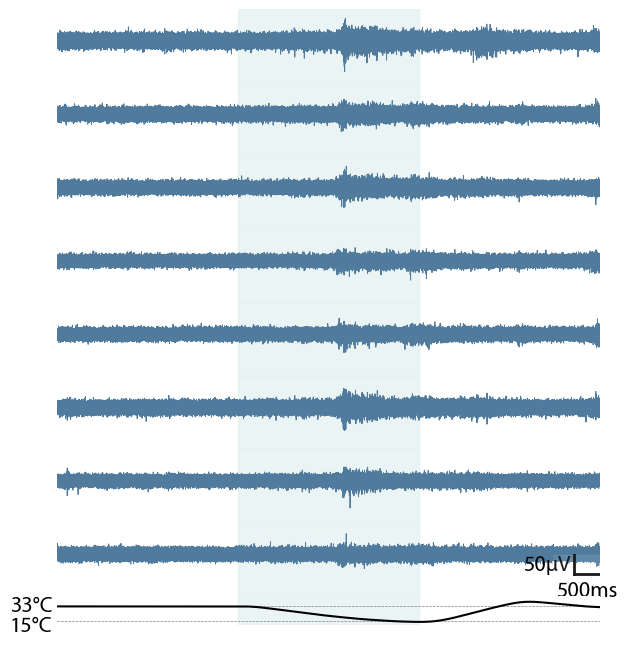

In [16]:
# Charger les données du fichier brut
dat_file = dat_file_path  # Chemin vers votre fichier .dat
data = np.fromfile(dat_file, dtype=np.float32)  # Charger les données brutes

channel_map = np.load(gui_fold + "/channel_map.npy").reshape(-1, 8)

n_shanks, channels_per_shank = channel_map.shape  # Dimensions du mapping
n_channels = n_shanks * channels_per_shank  # Nombre total de canaux

assert data.size % n_channels == 0, "Le nombre de canaux ne correspond pas aux données chargées."

# Paramètres
sampling_rate = 30000  # Fréquence d'échantillonnage

# Reshape des données
data_reshaped = data.reshape((-1, n_channels))

# Réorganiser les canaux selon le mapping
mapped_indices = channel_map.flatten()
data_mapped = data_reshaped[:, mapped_indices]

# Sélection d'un shank spécifique
shank_id = 0  
shank_channels = channel_map[shank_id]  
data_shank = data_mapped[:, shank_channels]  

id_stim = 7 #3

for i in range(n_stims):
    # Calcul des bornes pour chaque période en fonction du stimulus
    stim_start = t_stim_start[id_stim]
    stim_end = descending_end[id_stim]

# Définir la période d'affichage
stim_duration = stim_end - stim_start

start_time = stim_start - stim_duration
end_time = stim_end + stim_duration

start_sample = int(start_time * sampling_rate)
end_sample = int(end_time * sampling_rate)

# Extraire les données pour cette plage
data_to_plot = data_shank[start_sample:end_sample, :]
time = np.arange(start_sample, end_sample) / sampling_rate  

# Inverser l'ordre pour affichage correct
shank_channels_reversed = shank_channels[::-1]  
data_to_plot_reversed = data_to_plot[:, ::-1]  

# Calculer les limites de l'axe Y
y_max = np.max(data_to_plot_reversed)
y_min = np.min(data_to_plot_reversed)

y_max_rounded = np.ceil(y_max / 10) * 10
y_min_rounded = np.floor(y_min / 10) * 10

print(f"min : {y_min}, max : {y_max}")
print(f"Valeur minimale arrondie: {y_min_rounded}, Valeur maximale arrondie: {y_max_rounded}")


# === Création des subplots ===
fig, axs = plt.subplots(nrows=channels_per_shank + 1, ncols=1, figsize=(7, 1 * channels_per_shank), gridspec_kw={'height_ratios': [1] * channels_per_shank + [0.4]})

# Tracer les signaux des électrodes
for i in range(channels_per_shank):
    real_channel = shank_channels_reversed[i]  
    axs[i].plot(time, data_to_plot_reversed[:, i], color="#507b9c", linewidth=0.7, alpha=1)
    axs[i].axis('off')
    axs[i].axvspan(stim_start, stim_end, color='#D9EAEA', alpha=0.5, label='Cool stim', zorder=0)
    axs[i].set_xlim(start_time, end_time)
    # axs[i].set_ylim(y_min_tac, y_max_tac)
    # axs[i].set_ylim(y_min, y_max)
    axs[i].set_ylim(-108.42, 82.80)

# === Tracer la temp subplot ===

# Tracer les signaux des électrodes
for i in range(n_stims):
    # Masque ajusté pour les données de température
    mask = (t_lfps >= time.min()) & (t_lfps <= time.max())  # S'assurer que t_lfps est dans la plage de 'time'
    # Appliquer la condition de stimulation pour la température
    mask &= (t_lfps > t_stim_start[id_stim] - 2 * stim_duration) & (t_lfps < t_stim_start[id_stim] + 2 * stim_duration)
    # Extraire les données de température basées sur le masque ajusté
    t_plot = t_lfps[mask] - t_stim_start[3]  # Décalage pour aligner la période de stimulation
    t_plot = t_plot - t_plot.min() + time.min()
    temp_plot = therm_stim[mask]

# Définir la fonction de lissage avec une moyenne mobile
def moving_average(data, window_size):
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')

# Paramètres de la fenêtre de lissage
window_size = 5  # Taille de la fenêtre (par exemple, 10 points)

# Lissage de la température avec la moyenne mobile
temp_plot_smoothed = moving_average(temp_plot, window_size)

# Tracage de la température
axs[-1].plot(t_plot[window_size-1:], temp_plot_smoothed, color='k', linewidth=1.5)  # Aligner le temps avec les données lissées

# Réajuster la plage temporelle de la période de stimulation
axs[-1].axvspan(stim_start, stim_end, color='#D9EAEA', alpha=0.5, label='Cool stim', zorder=0)

# Ré-ajuster les limites de x et y sur axs[-1]
axs[-1].set_xlim(time.min(), time.max())
axs[-1].tick_params(axis='y', which='both', length=0)
axs[-1].set_yticks([12, 36])
axs[-1].set_yticklabels(['15°C', '33°C'], fontsize=16)
axs[-1].set_ylim(10, 46)

# Ajouter deux lignes horizontales fines à y = 33 et y = 15
axs[-1].axhline(y=33, color='grey', linewidth=0.5, linestyle='--', zorder=0)  # Ligne à y = 33
axs[-1].axhline(y=15, color='grey', linewidth=0.5, linestyle='--', zorder=0)  # Ligne à y = 15


# Supprimer l'axe des X et les bordures du haut et droite
axs[-1].get_xaxis().set_visible(False)  # Cache l'axe des X
axs[-1].spines['top'].set_visible(False)  # Cache la bordure du haut
axs[-1].spines['right'].set_visible(False)  # Cache la bordure de droite
axs[-1].spines['bottom'].set_visible(False)  # Cache la bordure de droite
axs[-1].spines['left'].set_visible(False)  # Cache la bordure de droite



# === boîte de légende en bas à droite du dernier subplot ===
# Choisir le subplot 7 (indice 6, car les indices commencent à 0)
shank_id = 7  # On veut placer la boîte dans le subplot 7

# Positionner la boîte en bas à droite du subplot 7
origin_x = end_time - 0.5  # Position en X (temps)
origin_y = y_min + (y_max - y_min) * 0.2  # Position en Y (amplitude)

# Ajouter une boîte blanche pour améliorer la visibilité
legend_box = patches.FancyBboxPatch((origin_x - 0.2, origin_y - 10), 1.2, 60, 
                                    boxstyle="round,pad=0.2", edgecolor='white', 
                                    facecolor='white', alpha=0.1, lw=0.5, zorder=20)
axs[shank_id].add_patch(legend_box)  # Ajouter la boîte de légende dans le subplot 7

# Ajouter l’échelle de temps (barre horizontale)
time_x_end = origin_x + 0.5  # Longueur = 0.5 seconde
axs[shank_id].plot([origin_x, time_x_end], [origin_y, origin_y], color='black', linewidth=2, zorder=12)
axs[shank_id].text((origin_x + time_x_end) / 2, origin_y - 17, "500ms", fontsize=16, ha='center', va='top')

# Ajouter l’échelle d’amplitude (barre verticale)
amp_y_end = origin_y + 50  # Hauteur = 50 µV
axs[shank_id].plot([origin_x, origin_x], [origin_y, amp_y_end], color='black', linewidth=2, zorder=12)
axs[shank_id].text(origin_x - 1, (origin_y + amp_y_end) / 2, "50µV", fontsize=16, ha='left', va='center')

# Ajuster l'espacement des subplots sans les décaler
fig.subplots_adjust(hspace=0.001)

# Sauvegarder la figure
plt.savefig(os.path.join(saving_dir, '4Ba_ML2_cool_cont_raw_traces.png'), format='png', dpi=300)
plt.savefig(os.path.join(saving_dir, '4Ba_ML2_cool_cont_raw_traces.svg'), format='svg', dpi=300)

plt.show()

#

### Fig 4.Bbis - Exemple rec LFP for ML2 thermic cool stim one shank

In [17]:
# Data file path
data_path = "U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/Converter_circus"
sel_folder = "2024.02.29"
sel_rec = 'allego_77__uid0229-15-01-23'

full_folder = os.path.join(data_path, sel_folder, sel_rec)
print (f'path for full folder : {full_folder}')

if os.path.exists(full_folder):
    print(f"Le dossier existe: {full_folder}")
else:
    print(f"Le dossier n'existe pas: {full_folder}")


# .dat file Path
dat_file = sel_rec + '_spy.dat'
# print(dat_file)

dat_file_path = os.path.join (full_folder,dat_file)
print (f'\npath for .dat : {dat_file_path}')


# Zarr and lfp data path
zarr_path = 'U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/Analysis_stef'
zarr_folder = sel_folder
zarr_file = sel_rec 
# zarr_file = sel_rec + '_spy'
zarr_folder_path = os.path.join(zarr_path, zarr_folder, zarr_file)

    # Vérification que le chemin est correct
print(f"\nzarr file path : {zarr_folder_path}")

    # Ouvrir les fichiers zarr
raw_data = zarr.open(os.path.join(zarr_folder_path, 'raw', 'dataset.zarr'), mode="r")
ephys_res = zarr.open(os.path.join(zarr_folder_path, 'processed', 'ephys.zarr'), mode="r")

# Affichage de quelques informations sur les datasets
print(f"Contenu de raw_data : {list(raw_data.keys())}")
print(f"Contenu de ephys_res : {list(ephys_res.keys())}")


# Circus sorting path
sorting_fold = os.path.join(full_folder, sel_rec +'_spy')
sorting_path = Path(sorting_fold)
print (f'\npath for circus sorting : {sorting_path}')

gui_fold = os.path.join(sorting_fold, sel_rec + '_spy.GUI')
gui_path = Path(gui_fold)
print (f'\npath for circus-GUI : {gui_fold}')


# cluster_info.tsv file path
clusinfo_path = os.path.join(gui_fold, 'cluster_info.tsv')

# Vérifier si le fichier existe avant de tenter de le lire
if os.path.exists(clusinfo_path):
    print ('')
    clusinfo_df = pd.read_csv(clusinfo_path, sep='\t')  # Fichier tabulé
else:
    raise FileNotFoundError(f"Fichier introuvable : {clusinfo_path}")


path for full folder : U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/Converter_circus\2024.02.29\allego_77__uid0229-15-01-23
Le dossier existe: U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/Converter_circus\2024.02.29\allego_77__uid0229-15-01-23

path for .dat : U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/Converter_circus\2024.02.29\allego_77__uid0229-15-01-23\allego_77__uid0229-15-01-23_spy.dat

zarr file path : U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/Analysis_stef\2024.02.29\allego_77__uid0229-15-01-23
Contenu de raw_data : ['adcs', 'channels']
Contenu de ephys_res : ['down_fact', 'lfps', 'sample_rate']

path for circus sorting : U:\PhD\Experimentation\Electrophysiology\S1_recordings_Analysis\Converter_circus\2024.02.29\allego_77__uid0229-15-01-23\allego_77__uid0229-15-01-23_spy

path for circus-GUI : U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/Converter_circus\2024.02.29\allego_77__ui

In [18]:
####### LFPs + ADCs from zarr #######
mapping = np.load(gui_fold + "/channel_map.npy").reshape(-1, 8)
lfps = ephys_res["lfps/channels/1"][:]
lfps -= np.median(lfps, axis=0)
adcs = ephys_res["lfps/adcs/1"][:]
stim_present = (adcs[1,:] > 1).astype(int)
t_lfps = ephys_res["lfps/timestamps/1"][:]
srate_acq = (t_lfps.size - 1) / (t_lfps[-1] - t_lfps[0])
np.sum(adcs[0,:]>3.) > t_lfps.size/2
select_times = np.logical_and(t_lfps>115., t_lfps< 135.)

####### Sampling rate for acquisition #######
f_sample_raw = 30000.0


####### Création du dataset pour spiketimes et amplitudes #######
dataset = {}
merged = list(sorting_path.glob("*.result.hdf5"))

if len(merged) != 1:
    logging.warning("Several or none .result.hdf5 file detected. Aborting!")
else:
    with h5py.File(merged[0], "r") as spike_in:
        dataset["spiketimes"] = {}
        dataset["amplitudes"] = {}  # Ajout pour les amplitudes

        for temp in spike_in["spiketimes"].items():
            # Extraction des données de spiketimes
            spiketimes_data = temp[1][:] / f_sample_raw
            dataset["spiketimes"][temp[0]] = spiketimes_data

            # Vérification de la présence d'amplitudes
            if "amplitudes" in spike_in:
                amplitudes_data = spike_in["amplitudes"][temp[0]][:]
                dataset["amplitudes"][temp[0]] = amplitudes_data
            else:
                logging.warning(f"No amplitudes found for {temp[0]}")


####### Selection des neurones valides ######
# Filtrer les neurones valides
valid_df = clusinfo_df.loc[clusinfo_df['group'].isin(['good', 'mua'])]

# Liste des neurones valides (pas les index, mais les valeurs)
valid_all = valid_df['cluster_id'].tolist()

# Récupérer les neurones valides par shank
n_shanks = 4
valid_per_sh = {}
for i_sh in range(n_shanks):
    valid_inds = valid_df.loc[valid_df['sh'] == float(i_sh), 'cluster_id'].tolist()
    valid_per_sh[f'sh#{i_sh}'] = valid_inds

# On transforme les indices dans valid_all en clés correspondant aux sous-clés 'temp_x'
valid_keys = [f'temp_{i}' for i in valid_all]

####### Here we infer the temperature timecourse #######
if TYPE_CHECKING:
    # Type annotations
    Abool = npt.NDArray[np.bool_]
    Afloat = npt.NDArray[np.float64]
    Aint = npt.NDArray[np.int_]


def infer_stim_times(stim_signal, tstamp, th_dur=15.0):

    """Infer stimulus start/stop times from the stimulus signal ttl.

    Args:
        stim_signal (Afloat): stimulus signal ttl .
        t_lfps (Afloat): tstemp of the lfp.
        th_dur (float): duration threshold (in seconds) to infer valid times

    Returns:
        tuple(Afloat): stimulus start times, stimulus end times.

    """

    up_inds = np.where(np.diff(stim_signal) > 0.5)[0][1:] # stim signal goes up, excluding recording start
    down_inds = np.where(np.diff(stim_signal) < -0.5)[0][1:] # stim signal goes down, excluding recording start
    
    t_up = tstamp[up_inds]
    t_down = tstamp[down_inds]
    
    valid_up = np.diff(t_up) > th_dur # this is 15. seconds 
    valid_up = np.concatenate(([True], valid_up)) # the first up is always valid
    
    valid_down = np.diff(t_down) > th_dur
    valid_down = np.concatenate((valid_down, [True])) # the last down is always valid
    
    # n_stims = np.sum(valid_up)
    
    t_stim_start = t_up[valid_up]
    t_stim_end = t_down[valid_down]

    return t_stim_start, t_stim_end


t_stim_start, t_stim_end = infer_stim_times(stim_signal=stim_present, 
                                                tstamp=t_lfps)

n_stims = t_stim_start.size

valid_temp_profile = np.max(adcs[0,:]) > 2.0

if valid_temp_profile:
    
    therm_stim = 10. * adcs[0,:]

else:
    # Load the temperature profile file
    temp_file = 'U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/Analysis_stef/temp15_mean_profile.xlsx'
    temp_df = pd.read_excel(temp_file)
    temp_profile = temp_df['Temperature'].values
    n_temps = temp_profile.size

    time_interp = [np.linspace(t_stim_start[i], t_stim_end[i], n_temps) for  i in range(n_stims)]
    time_interp = np.hstack(time_interp)
    temp_interp = np.tile(temp_profile, n_stims)
    therm_stim = np.interp(t_lfps, time_interp, temp_interp)



####### Infer ascending and descending phases #######
thr_temp = 34

descending_start = t_stim_start  # this correspons to the beginning of the descending phase of the stimulus, thus with the beginning of the stimulus
descending_end = np.zeros(n_stims)
ascending_start = np.zeros(n_stims)
ascending_end = np.zeros(n_stims)

for i in range(n_stims):
    mask = t_lfps > t_stim_start[i]
    mask &= t_lfps < t_stim_end[i]
    ther_sel = therm_stim[mask]
    descending_end[i] = t_stim_start[i] + t_lfps[np.argmin(ther_sel)]
    mask_asc = ther_sel > thr_temp
    ind_end = np.where(mask_asc==True)[0][0]
    ascending_end[i] = t_stim_start[i] + t_lfps[ind_end]
ascending_start = descending_end
thr_temp = 34

descending_start = t_stim_start  # Correspond au début de la phase descendante du stimulus
descending_end = np.zeros(n_stims)  # Initialisation de la fin de la phase descendante
ascending_start = np.zeros(n_stims)  # Initialisation du début de la phase ascendante
ascending_end = np.zeros(n_stims)  # Initialisation de la fin de la phase ascendante

for i in range(n_stims):
    mask = t_lfps > t_stim_start[i]
    mask &= t_lfps < t_stim_end[i]
    ther_sel = therm_stim[mask]
    
    # Définir la fin de la phase descendante comme le point où la température est minimale
    descending_end[i] = t_stim_start[i] + t_lfps[np.argmin(ther_sel)]
    
    # Déterminer le début de la phase ascendante, basé sur le seuil de température
    mask_asc = ther_sel > thr_temp
    ind_end = np.where(mask_asc==True)[0][0]
    ascending_end[i] = t_stim_start[i] + t_lfps[ind_end]
    
    # La phase ascendante commence là où la phase descendante se termine
    ascending_start[i] = descending_end[i]

# ####### Parameters for the PSTH #######
win_size = 0.2 # seconds, it is the binning size
dt_before = 10. # seconds before stimuus
dt_after = 15. # seconds after stimulus



####### Définir les périodes pour chaque stimulus #######
time_periods = {}

for i in range(n_stims):
    # Calcul des bornes pour chaque période en fonction du stimulus
    baseline_start = t_stim_start[i] - dt_before
    baseline_end = t_stim_start[i]
    stim_start = t_stim_start[i]
    stim_end = descending_end[i]
    post_stim_start = descending_end[i]
    post_stim_end = t_stim_start[i] + dt_after

    # Enregistrer les périodes dans un dictionnaire
    time_periods[i] = {
        "Baseline": (baseline_start, baseline_end),
        "Stim": (stim_start, stim_end),
        "Post-Stim": (post_stim_start, post_stim_end)
    }

In [19]:
# This is to plot the temperature profile on the raster
mask_raster = t_lfps > descending_start[0] - dt_before - 10
mask_raster &= t_lfps < descending_start[0] + dt_after + 10
t_plot_raster = t_lfps[mask_raster] - descending_start[0]
temp_plot_raster = therm_stim[mask_raster]

# Définir la fonction de lissage avec une moyenne mobile
def moving_average(data, window_size):
    return np.convolve(data, np.ones(window_size)/window_size, mode='same')

# Paramètres de la fenêtre de lissage
window_size = 300  # Taille de la fenêtre (par exemple, 10 points)

# Lissage de la température avec la moyenne mobile
temp_plot_smoothed_raster = moving_average(temp_plot_raster, window_size)

min : -228.70382542143508, max : 190.70075852864983
Valeur minimale arrondie: -230.0, Valeur maximale arrondie: 200.0


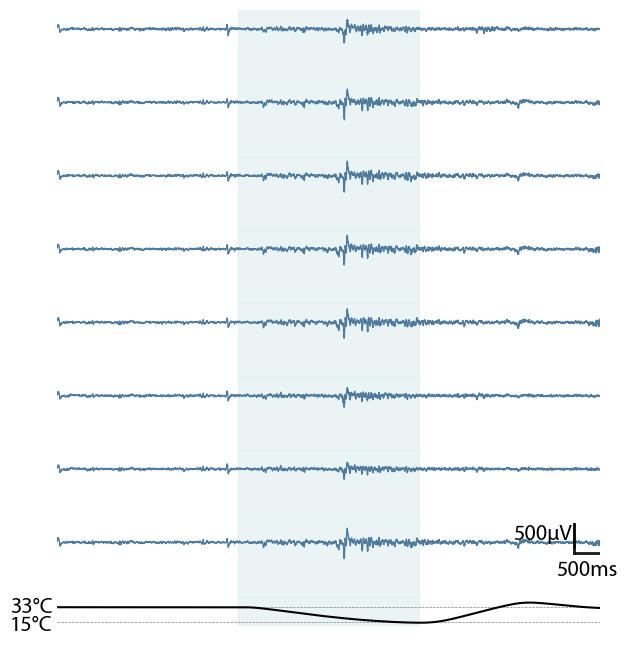

In [20]:
# Charger les données du fichier brut
dat_file = dat_file_path  # Chemin vers votre fichier .dat
data = np.fromfile(dat_file, dtype=np.float32)  # Charger les données brutes

channel_map = np.load(gui_fold + "/channel_map.npy").reshape(-1, 8)

n_shanks, channels_per_shank = channel_map.shape  # Dimensions du mapping
n_channels = n_shanks * channels_per_shank  # Nombre total de canaux

assert data.size % n_channels == 0, "Le nombre de canaux ne correspond pas aux données chargées."

# Paramètres
sampling_rate = 30000  # Fréquence d'échantillonnage

# Reshape des données
data_reshaped = data.reshape((-1, n_channels))

# Réorganiser les canaux selon le mapping
mapped_indices = channel_map.flatten()
data_mapped = data_reshaped[:, mapped_indices]

# Sélection d'un shank spécifique
shank_id = 0  
shank_channels = channel_map[shank_id]  
data_shank = data_mapped[:, shank_channels] 

id_stim = 7

for i in range(n_stims):
    # Calcul des bornes pour chaque période en fonction du stimulus
    stim_start = t_stim_start[id_stim]
    stim_end = descending_end[id_stim]

# Définir la période d'affichage
stim_duration = stim_end - stim_start

start_time = stim_start - stim_duration
end_time = stim_end + stim_duration

start_sample = int(start_time * sampling_rate)
end_sample = int(end_time * sampling_rate)

# Extraire les données pour cette plage
data_to_plot = data_shank[start_sample:end_sample, :]
time = np.arange(start_sample, end_sample) / sampling_rate  

# Inverser l'ordre pour affichage correct
shank_channels_reversed = shank_channels[::-1]  
data_to_plot_reversed = data_to_plot[:, ::-1]  

# Fonction pour appliquer un filtre passe-bas
def lowpass_filter(data, cutoff=200, fs=30000, order=4):
    nyquist = 0.5 * fs  # Fréquence de Nyquist
    normal_cutoff = cutoff / nyquist
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    return filtfilt(b, a, data, axis=0)

# Appliquer le filtrage passe-bas Butterworth
data_filtered = lowpass_filter(data_to_plot_reversed)

# Appliquer le filtre Savitzky-Golay (fenêtre = 101, polynôme = 3)
data_filtered_savgol = savgol_filter(data_filtered, window_length=101, polyorder=3, axis=0)


# Calculer les limites de l'axe Y
y_max = np.max(data_filtered_savgol)
y_min = np.min(data_filtered_savgol)


y_max_rounded = np.ceil(y_max / 10) * 10
y_min_rounded = np.floor(y_min / 10) * 10

print(f"min : {y_min}, max : {y_max}")
print(f"Valeur minimale arrondie: {y_min_rounded}, Valeur maximale arrondie: {y_max_rounded}")


# === Création des subplots ===
fig, axs = plt.subplots(nrows=channels_per_shank + 1, ncols=1, figsize=(7, 1 * channels_per_shank), gridspec_kw={'height_ratios': [1] * channels_per_shank + [0.4]})

# Tracer les signaux des électrodes
for i in range(channels_per_shank):
    real_channel = shank_channels_reversed[i]  
    axs[i].plot(time, data_filtered_savgol[:, i], color="#507b9c", linewidth=1)
    axs[i].axis('off')
    axs[i].axvspan(stim_start, stim_end, color='#D9EAEA', alpha=0.5, label='Tactile stim', zorder=0)
    axs[i].set_xlim(start_time, end_time)
    axs[i].set_ylim(-710, 250)
    # axs[i].set_ylim(y_min_tac, y_max_tac)
    # axs[i].set_ylim(y_min, y_max)

# === Tracer la temp subplot ===

# Tracer les signaux des électrodes
for i in range(n_stims):
    # Masque ajusté pour les données de température
    mask = (t_lfps >= time.min()) & (t_lfps <= time.max())  # S'assurer que t_lfps est dans la plage de 'time'
    # Appliquer la condition de stimulation pour la température
    mask &= (t_lfps > t_stim_start[id_stim] - 2 * stim_duration) & (t_lfps < t_stim_start[id_stim] + 2 * stim_duration)
    # Extraire les données de température basées sur le masque ajusté
    t_plot = t_lfps[mask] - t_stim_start[id_stim]  # Décalage pour aligner la période de stimulation
    t_plot = t_plot - t_plot.min() + time.min()
    temp_plot = therm_stim[mask]

# Définir la fonction de lissage avec une moyenne mobile
def moving_average(data, window_size):
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')

# Paramètres de la fenêtre de lissage
window_size = 6  # Taille de la fenêtre (par exemple, 10 points)

# Lissage de la température avec la moyenne mobile
temp_plot_smoothed = moving_average(temp_plot, window_size)

# Tracage de la température
axs[-1].plot(t_plot[window_size-1:], temp_plot_smoothed, color='k', linewidth=1.5)  # Aligner le temps avec les données lissées

# Réajuster la plage temporelle de la période de stimulation
axs[-1].axvspan(stim_start, stim_end, color='#D9EAEA', alpha=0.5, label='Cool stim', zorder=0)

# Ré-ajuster les limites de x et y sur axs[-1]
axs[-1].set_xlim(time.min(), time.max())
axs[-1].tick_params(axis='y', which='both', length=0)
axs[-1].set_yticks([13, 35])
axs[-1].set_yticklabels(['15°C', '33°C'], fontsize=16)
axs[-1].set_ylim(10, 46)

# Ajouter deux lignes horizontales fines à y = 33 et y = 15
axs[-1].axhline(y=33, color='grey', linewidth=0.5, linestyle='--', zorder=0)  # Ligne à y = 33
axs[-1].axhline(y=15, color='grey', linewidth=0.5, linestyle='--', zorder=0)  # Ligne à y = 15


# Supprimer l'axe des X et les bordures du haut et droite
axs[-1].get_xaxis().set_visible(False)  # Cache l'axe des X
axs[-1].spines['top'].set_visible(False)  # Cache la bordure du haut
axs[-1].spines['right'].set_visible(False)  # Cache la bordure de droite
axs[-1].spines['bottom'].set_visible(False)  # Cache la bordure de droite
axs[-1].spines['left'].set_visible(False)  # Cache la bordure de droite



# === boîte de légende en bas à droite du dernier subplot ===
# Choisir le subplot 7 (indice 6, car les indices commencent à 0)
shank_id = 7  # On veut placer la boîte dans le subplot 7

# Positionner la boîte en bas à droite du subplot 7
origin_x = end_time - 0.5  # Position en X (temps)
origin_y = y_min + (y_max - y_min) * 0.2  # Position en Y (amplitude)

# Ajouter une boîte blanche pour améliorer la visibilité
legend_box = patches.FancyBboxPatch((origin_x - 0.2, origin_y - 10), 1.2, 60, 
                                    boxstyle="round,pad=0.2", edgecolor='white', 
                                    facecolor='white', alpha=0.1, lw=0.5, zorder=20)
axs[shank_id].add_patch(legend_box)  # Ajouter la boîte de légende dans le subplot 7

# Ajouter l’échelle de temps (barre horizontale)
time_x_end = origin_x + 0.5  # Longueur = 0.5 seconde
axs[shank_id].plot([origin_x, time_x_end], [origin_y, origin_y], color='black', linewidth=2, zorder=16)
axs[shank_id].text((origin_x + time_x_end) / 2, origin_y - 100, "500ms", fontsize=16, ha='center', va='top')

# Ajouter l’échelle d’amplitude (barre verticale)
amp_y_end = origin_y + 500  # Hauteur = 50 µV
axs[shank_id].plot([origin_x, origin_x], [origin_y, amp_y_end], color='black', linewidth=2, zorder=16)
axs[shank_id].text(origin_x - 1.2, (origin_y + amp_y_end) / 2, "500µV", fontsize=16, ha='left', va='center')


# Ajuster l'espacement des subplots sans les décaler
fig.subplots_adjust(hspace=0.001)

# Sauvegarder la figure
plt.savefig(os.path.join(saving_dir, '4Bb_bis_ML2_cool_cont_raw_traces.png'), format='png', dpi=300)
plt.savefig(os.path.join(saving_dir, '4Bb_bis_ML2_cool_cont_raw_traces.svg'), format='svg', dpi=300)

plt.show()

#

### Fig 4.C - Exemple raster for thermic cool stim one neuron (8 stim)

Cluster : temp_30


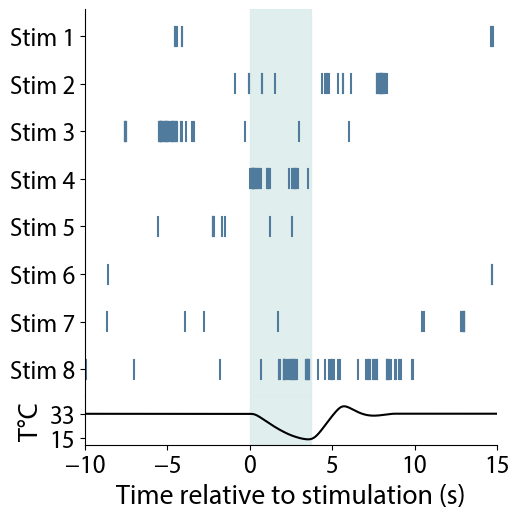

In [21]:
# Paramètres
time_before_stim = 10  # 10 secondes avant le début du stimulus
time_after_stim = 15   # 15 secondes après le début du stimulus

# Sélectionner un valid_key
valid_key = valid_keys[10]  # Choisir un seul neurone / 9
print(f'Cluster : {valid_key}')

# Récupérer les spikes pour ce neurone spécifique
spikes = dataset['spiketimes'][valid_key]

# === Création des subplots ===
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(5, 5), sharex=True, gridspec_kw={'height_ratios': [8, 1]})

# Tracer les spikes pour chaque stimulus
for i in range(len(t_stim_start)):  # Pour chaque stimulus (de 1 à 8)
    stim_start = t_stim_start[i]
    stim_end = t_stim_end[i]

    # Définir la fenêtre d'intérêt autour du stimulus (10 secondes avant et après)
    window_start = stim_start - time_before_stim
    window_end = stim_end + time_after_stim

    # Sélectionner les spikes dans cette fenêtre et les aligner par rapport au début du stimulus
    selected_spikes = [spike - stim_start for spike in spikes if window_start <= spike <= window_end]

    # Tracer les spikes alignés pour ce stimulus
    for spike in selected_spikes:
        ax1.plot([spike, spike], [i + 0.2, i - 0.2], color='#507b9c')  # Ligne verticale pour chaque spike

# Paramétrage du raster plot
ax1.set_ylabel('')  # Label de l'axe Y

# Inverser l'ordre des ticks de l'axe Y et l'axe Y
ax1.set_yticks(range(len(t_stim_start)-1, -1, -1))  # Inverser l'ordre des ticks
ax1.set_yticklabels([f'Stim {i+1}' for i in range(len(t_stim_start)-1, -1, -1)])  # Labels des stimuli inversés

# Limiter l'axe des x pour afficher la fenêtre autour du stimulus
ax1.set_xlim([-time_before_stim, time_after_stim])  # Afficher de -10s à +15s autour de chaque stimulus

# Inverser l'axe Y pour avoir Stim 1 en haut et Stim 8 en bas
ax1.invert_yaxis()  # Inverse l'axe Y

ax1.axvspan(0, 3.7, color='#D9EAEA', alpha=0.8, label='Cool stim', zorder=0)

# Suppression des bordures superflues
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['bottom'].set_visible(False)
ax1.get_xaxis().set_visible(False)  # Cache l'axe des X


# === Tracer les pulses tactiles en dernier subplot ===
# **Deuxième subplot : Température**
ax2.plot(t_plot_raster, temp_plot_smoothed_raster, color='k',  linewidth=1.5)
ax2.axvspan(0, 3.7, color='#D9EAEA', alpha=0.8, label='Cool stim', zorder=0)
ax2.set_ylabel("T°C")
ax2.set_xlabel("Time relative to stimulation (s)")
ax2.set_yticks([15, 33])
ax2.set_yticklabels(['15', '33'])
ax2.set_ylim(10, 46)
ax2.set_xlim([-time_before_stim, time_after_stim])  # Afficher de -10s à +15s autour de chaque stimulus

# Suppression des bordures superflues
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# Ajustements finaux
plt.tight_layout(pad=0.001, h_pad=0.001)

# Sauvegarder la figure
plt.savefig(os.path.join(saving_dir, '4C_ML2_cool_cont_raster.png'), format='png', dpi=300)
plt.savefig(os.path.join(saving_dir, '4C_ML2_cool_cont_raster.svg'), format='svg', dpi=300)

plt.show()


#

### Fig 4.D - Exemple rec for ML2 thermic warm stim one shank

In [22]:
# Data file path
data_path = "U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/Converter_circus"
sel_folder = "2024.02.29"
# sel_rec = 'allego_5__uid0229-14-38-37'
sel_rec = 'allego_8__uid0229-15-13-13'

full_folder = os.path.join(data_path, sel_folder, sel_rec)
print (f'path for full folder : {full_folder}')

if os.path.exists(full_folder):
    print(f"Le dossier existe: {full_folder}")
else:
    print(f"Le dossier n'existe pas: {full_folder}")


# .dat file Path
dat_file = sel_rec + '_spy.dat'
# print(dat_file)

dat_file_path = os.path.join (full_folder,dat_file)
print (f'\npath for .dat : {dat_file_path}')


# Zarr and lfp data path
zarr_path = 'U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/Analysis_stef'
zarr_folder = sel_folder
zarr_file = sel_rec 
# zarr_file = sel_rec + '_spy'
zarr_folder_path = os.path.join(zarr_path, zarr_folder, zarr_file)

    # Vérification que le chemin est correct
print(f"\nzarr file path : {zarr_folder_path}")

    # Ouvrir les fichiers zarr
raw_data = zarr.open(os.path.join(zarr_folder_path, 'raw', 'dataset.zarr'), mode="r")
ephys_res = zarr.open(os.path.join(zarr_folder_path, 'processed', 'ephys.zarr'), mode="r")

# Affichage de quelques informations sur les datasets
print(f"Contenu de raw_data : {list(raw_data.keys())}")
print(f"Contenu de ephys_res : {list(ephys_res.keys())}")


# Circus sorting path
sorting_fold = os.path.join(full_folder, sel_rec +'_spy')
sorting_path = Path(sorting_fold)
print (f'\npath for circus sorting : {sorting_path}')

gui_fold = os.path.join(sorting_fold, sel_rec + '_spy.GUI')
gui_path = Path(gui_fold)
print (f'\npath for circus-GUI : {gui_fold}')


# cluster_info.tsv file path
clusinfo_path = os.path.join(gui_fold, 'cluster_info.tsv')

# Vérifier si le fichier existe avant de tenter de le lire
if os.path.exists(clusinfo_path):
    print ('')
    clusinfo_df = pd.read_csv(clusinfo_path, sep='\t')  # Fichier tabulé
else:
    raise FileNotFoundError(f"Fichier introuvable : {clusinfo_path}")


path for full folder : U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/Converter_circus\2024.02.29\allego_8__uid0229-15-13-13
Le dossier existe: U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/Converter_circus\2024.02.29\allego_8__uid0229-15-13-13

path for .dat : U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/Converter_circus\2024.02.29\allego_8__uid0229-15-13-13\allego_8__uid0229-15-13-13_spy.dat

zarr file path : U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/Analysis_stef\2024.02.29\allego_8__uid0229-15-13-13
Contenu de raw_data : ['adcs', 'channels']
Contenu de ephys_res : ['down_fact', 'lfps', 'sample_rate']

path for circus sorting : U:\PhD\Experimentation\Electrophysiology\S1_recordings_Analysis\Converter_circus\2024.02.29\allego_8__uid0229-15-13-13\allego_8__uid0229-15-13-13_spy

path for circus-GUI : U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/Converter_circus\2024.02.29\allego_8__uid0229-15

In [23]:
####### LFPs + ADCs from zarr #######
mapping = np.load(gui_fold + "/channel_map.npy").reshape(-1, 8)
lfps = ephys_res["lfps/channels/1"][:]
lfps -= np.median(lfps, axis=0)
adcs = ephys_res["lfps/adcs/1"][:]
stim_present = (adcs[1,:] > 1).astype(int)
t_lfps = ephys_res["lfps/timestamps/1"][:]
srate_acq = (t_lfps.size - 1) / (t_lfps[-1] - t_lfps[0])
np.sum(adcs[0,:]>3.) > t_lfps.size/2
select_times = np.logical_and(t_lfps>115., t_lfps< 135.)

####### Sampling rate for acquisition #######
f_sample_raw = 30000.0

####### Création du dataset pour spiketimes et amplitudes #######
dataset = {}
merged = list(sorting_path.glob("*.result.hdf5"))

if len(merged) != 1:
    logging.warning("Several or none .result.hdf5 file detected. Aborting!")
else:
    with h5py.File(merged[0], "r") as spike_in:
        dataset["spiketimes"] = {}
        dataset["amplitudes"] = {}  # Ajout pour les amplitudes

        for temp in spike_in["spiketimes"].items():
            # Extraction des données de spiketimes
            spiketimes_data = temp[1][:] / f_sample_raw
            dataset["spiketimes"][temp[0]] = spiketimes_data

            # Vérification de la présence d'amplitudes
            if "amplitudes" in spike_in:
                amplitudes_data = spike_in["amplitudes"][temp[0]][:]
                dataset["amplitudes"][temp[0]] = amplitudes_data
            else:
                logging.warning(f"No amplitudes found for {temp[0]}")

####### Selection des neurones valides #######
# Filtrer les neurones valides
valid_df = clusinfo_df.loc[clusinfo_df['group'].isin(['good', 'mua'])]

# Liste des neurones valides (pas les index, mais les valeurs)
valid_all = valid_df['cluster_id'].tolist()

# Récupérer les neurones valides par shank
n_shanks = 4
valid_per_sh = {}
for i_sh in range(n_shanks):
    valid_inds = valid_df.loc[valid_df['sh'] == float(i_sh), 'cluster_id'].tolist()
    valid_per_sh[f'sh#{i_sh}'] = valid_inds

# On transforme les indices dans valid_all en clés correspondant aux sous-clés 'temp_x'
valid_keys = [f'temp_{i}' for i in valid_all]

####### Here we infer the temperature timecourse #######
if TYPE_CHECKING:
    # Type annotations
    Abool = npt.NDArray[np.bool_]
    Afloat = npt.NDArray[np.float64]
    Aint = npt.NDArray[np.int_]

def infer_stim_times(stim_signal, tstamp, th_dur=15.0):

    """Infer stimulus start/stop times from the stimulus signal ttl.

    Args:
        stim_signal (Afloat): stimulus signal ttl .
        t_lfps (Afloat): tstemp of the lfp.
        th_dur (float): duration threshold (in seconds) to infer valid times

    Returns:
        tuple(Afloat): stimulus start times, stimulus end times.

    """
    up_inds = np.where(np.diff(stim_signal) > 0.5)[0][1:] # stim signal goes up, excluding recording start
    down_inds = np.where(np.diff(stim_signal) < -0.5)[0][1:] # stim signal goes down, excluding recording start
    
    t_up = tstamp[up_inds]
    t_down = tstamp[down_inds]
    
    valid_up = np.diff(t_up) > th_dur # this is 15. seconds 
    valid_up = np.concatenate(([True], valid_up)) # the first up is always valid
    
    valid_down = np.diff(t_down) > th_dur
    valid_down = np.concatenate((valid_down, [True])) # the last down is always valid
    
    t_stim_start = t_up[valid_up]
    t_stim_end = t_down[valid_down]

    return t_stim_start, t_stim_end

t_stim_start, t_stim_end = infer_stim_times(stim_signal=stim_present, 
                                                tstamp=t_lfps)

n_stims = t_stim_start.size

valid_temp_profile = np.max(adcs[0,:]) > 2.0

if valid_temp_profile:
    
    therm_stim = 10. * adcs[0,:]

else:
    # Load the temperature profile file
    temp_file = 'U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/Analysis_stef/temp46_mean_profile.xlsx'
    temp_df = pd.read_excel(temp_file)
    temp_profile = temp_df['Temperature'].values
    n_temps = temp_profile.size

    time_interp = [np.linspace(t_stim_start[i], t_stim_end[i], n_temps) for  i in range(n_stims)]
    time_interp = np.hstack(time_interp)
    temp_interp = np.tile(temp_profile, n_stims)
    therm_stim = np.interp(t_lfps, time_interp, temp_interp)

####### Infer ascending and descending phases #######
thr_temp = 34

descending_start = t_stim_start  # this correspons to the beginning of the descending phase of the stimulus, thus with the beginning of the stimulus
descending_end = np.zeros(n_stims)
ascending_start = np.zeros(n_stims)
ascending_end = np.zeros(n_stims)

for i in range(n_stims):
    mask = t_lfps > t_stim_start[i]
    mask &= t_lfps < t_stim_end[i]
    ther_sel = therm_stim[mask]
    descending_end[i] = t_stim_start[i] + t_lfps[np.argmin(ther_sel)]
    mask_asc = ther_sel > thr_temp
    ind_end = np.where(mask_asc==True)[0][0]
    ascending_end[i] = t_stim_start[i] + t_lfps[ind_end]
ascending_start = descending_end
thr_temp = 34

descending_start = t_stim_start  # Correspond au début de la phase descendante du stimulus
descending_end = np.zeros(n_stims)  # Initialisation de la fin de la phase descendante
ascending_start = np.zeros(n_stims)  # Initialisation du début de la phase ascendante
ascending_end = np.zeros(n_stims)  # Initialisation de la fin de la phase ascendante

for i in range(n_stims):
    mask = t_lfps > t_stim_start[i]
    mask &= t_lfps < t_stim_end[i]
    ther_sel = therm_stim[mask]
    
    # Définir la fin de la phase descendante comme le point où la température est minimale
    descending_end[i] = t_stim_start[i] + t_lfps[np.argmin(ther_sel)]
    
    # Déterminer le début de la phase ascendante, basé sur le seuil de température
    mask_asc = ther_sel > thr_temp
    ind_end = np.where(mask_asc==True)[0][0]
    ascending_end[i] = t_stim_start[i] + t_lfps[ind_end]
    
    # La phase ascendante commence là où la phase descendante se termine
    ascending_start[i] = descending_end[i]

######## Parameters for the PSTH #######
win_size = 0.2 # seconds, it is the binning size
dt_before = 10. # seconds before stimuus
dt_after = 15. # seconds after stimulus


####### Définir les périodes pour chaque stimulus #######
time_periods = {}

for i in range(n_stims):
    # Calcul des bornes pour chaque période en fonction du stimulus
    baseline_start = t_stim_start[i] - dt_before
    baseline_end = t_stim_start[i]
    stim_start = t_stim_start[i]
    stim_end = descending_end[i]
    post_stim_start = descending_end[i]
    post_stim_end = t_stim_start[i] + dt_after

    # Enregistrer les périodes dans un dictionnaire
    time_periods[i] = {
        "Baseline": (baseline_start, baseline_end),
        "Stim": (stim_start, stim_end),
        "Post-Stim": (post_stim_start, post_stim_end)
    }

In [24]:
# This is to plot the temperature profile on the raster
mask_raster = t_lfps > descending_start[0] - dt_before - 10
mask_raster &= t_lfps < descending_start[0] + dt_after + 10
t_plot_raster = t_lfps[mask_raster] - descending_start[0]
temp_plot_raster = therm_stim[mask_raster]

# Définir la fonction de lissage avec une moyenne mobile
def moving_average(data, window_size):
    return np.convolve(data, np.ones(window_size)/window_size, mode='same')

# Paramètres de la fenêtre de lissage
window_size = 300  # Taille de la fenêtre (par exemple, 10 points)

# Lissage de la température avec la moyenne mobile
temp_plot_smoothed_raster = moving_average(temp_plot_raster, window_size)

min : -38.00599670410156, max : 34.61418151855469
Valeur minimale arrondie: -40.0, Valeur maximale arrondie: 40.0


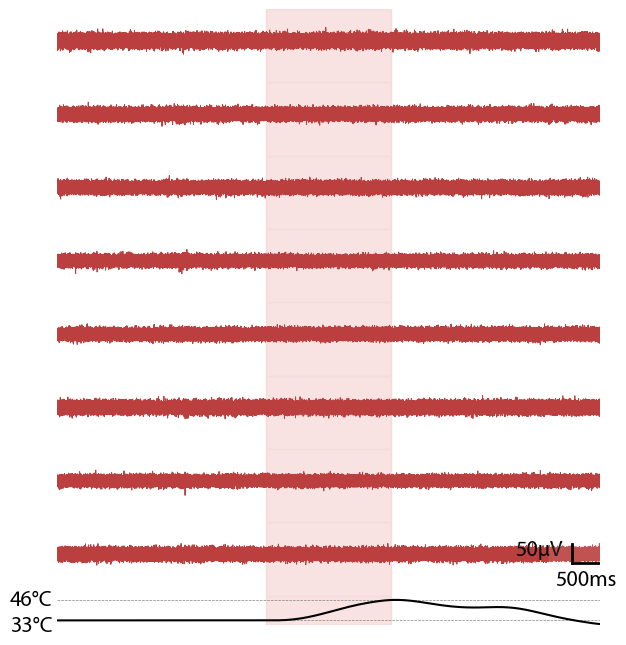

In [25]:
# Charger les données du fichier brut
dat_file = dat_file_path  # Chemin vers votre fichier .dat
data = np.fromfile(dat_file, dtype=np.float32)  # Charger les données brutes

channel_map = np.load(gui_fold + "/channel_map.npy").reshape(-1, 8)

n_shanks, channels_per_shank = channel_map.shape  # Dimensions du mapping
n_channels = n_shanks * channels_per_shank  # Nombre total de canaux

assert data.size % n_channels == 0, "Le nombre de canaux ne correspond pas aux données chargées."

# Paramètres
sampling_rate = 30000  # Fréquence d'échantillonnage

# Reshape des données
data_reshaped = data.reshape((-1, n_channels))

# Réorganiser les canaux selon le mapping
mapped_indices = channel_map.flatten()
data_mapped = data_reshaped[:, mapped_indices]

# Sélection d'un shank spécifique
shank_id = 0  
shank_channels = channel_map[shank_id]  
data_shank = data_mapped[:, shank_channels]  

# id_stim = 0 #2
id_stim = 4

for i in range(n_stims):
    # Calcul des bornes pour chaque période en fonction du stimulus
    stim_start = t_stim_start[id_stim]
    stim_end = stim_start + 2.2

# Définir la période d'affichage
stim_duration = stim_end - stim_start

start_time = stim_start - stim_duration - 1.5
end_time = stim_end + stim_duration + 1.5

start_sample = int(start_time * sampling_rate)
end_sample = int(end_time * sampling_rate)

# Extraire les données pour cette plage
data_to_plot = data_shank[start_sample:end_sample, :]
time = np.arange(start_sample, end_sample) / sampling_rate  

# Inverser l'ordre pour affichage correct
shank_channels_reversed = shank_channels[::-1]  
data_to_plot_reversed = data_to_plot[:, ::-1]  

# Calculer les limites de l'axe Y
y_max = np.max(data_to_plot_reversed)
y_min = np.min(data_to_plot_reversed)

y_max_rounded = np.ceil(y_max / 10) * 10
y_min_rounded = np.floor(y_min / 10) * 10

print(f"min : {y_min}, max : {y_max}")
print(f"Valeur minimale arrondie: {y_min_rounded}, Valeur maximale arrondie: {y_max_rounded}")


# === Création des subplots ===
fig, axs = plt.subplots(nrows=channels_per_shank + 1, ncols=1, figsize=(7, 1 * channels_per_shank), gridspec_kw={'height_ratios': [1] * channels_per_shank + [0.4]})

# Tracer les signaux des électrodes
for i in range(channels_per_shank):
    real_channel = shank_channels_reversed[i]  
    axs[i].plot(time, data_to_plot_reversed[:, i], color="#bb3f3f", linewidth=0.7, alpha=1)
    axs[i].axis('off')
    axs[i].axvspan(stim_start, stim_end, color='#F2C7C7', alpha=0.5, label='Warm stim', zorder=0)
    axs[i].set_xlim(start_time, end_time)
    # axs[i].set_ylim(y_min_tac, y_max_tac)
    axs[i].set_ylim(-108.42, 82.80)


# === Tracer la temp subplot ===

# Tracer les signaux des électrodes
for i in range(n_stims):
    # Masque ajusté pour les données de température
    mask = (t_lfps >= time.min()) & (t_lfps <= time.max())  # S'assurer que t_lfps est dans la plage de 'time'
    # Appliquer la condition de stimulation pour la température
    mask &= (t_lfps > t_stim_start[id_stim] - 4 * stim_duration) & (t_lfps < t_stim_start[id_stim] + 4 * stim_duration)
    # Extraire les données de température basées sur le masque ajusté
    t_plot = t_lfps[mask] - t_stim_start[id_stim]  # Décalage pour aligner la période de stimulation
    t_plot = t_plot - t_plot.min() + time.min()
    temp_plot = therm_stim[mask]

# Définir la fonction de lissage avec une moyenne mobile
def moving_average(data, window_size):
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')

# Paramètres de la fenêtre de lissage
window_size = 5  # Taille de la fenêtre (par exemple, 10 points)

# Lissage de la température avec la moyenne mobile
temp_plot_smoothed = moving_average(temp_plot, window_size)

# Tracage de la température
axs[-1].plot(t_plot[window_size-1:], temp_plot_smoothed, color='k', linewidth=1.5)  # Aligner le temps avec les données lissées

# Réajuster la plage temporelle de la période de stimulation
axs[-1].axvspan(stim_start, stim_end, color='#F2C7C7', alpha=0.5, label='Warm stim', zorder=0)

# Ré-ajuster les limites de x et y sur axs[-1]
axs[-1].set_xlim(time.min(), time.max())
axs[-1].tick_params(axis='y', which='both', length=0)
axs[-1].set_yticks([31, 48])
axs[-1].set_yticklabels(['33°C', '46°C'], fontsize=16)
axs[-1].set_ylim(30, 49)

# Ajouter deux lignes horizontales fines à y = 33 et y = 15
axs[-1].axhline(y=33, color='grey', linewidth=0.5, linestyle='--', zorder=0)  # Ligne à y = 33
axs[-1].axhline(y=46, color='grey', linewidth=0.5, linestyle='--', zorder=0)  # Ligne à y = 15


# Supprimer l'axe des X et les bordures du haut et droite
axs[-1].get_xaxis().set_visible(False)  # Cache l'axe des X
axs[-1].spines['top'].set_visible(False)  # Cache la bordure du haut
axs[-1].spines['right'].set_visible(False)  # Cache la bordure de droite
axs[-1].spines['bottom'].set_visible(False)  # Cache la bordure de droite
axs[-1].spines['left'].set_visible(False)  # Cache la bordure de droite



# === boîte de légende en bas à droite du dernier subplot ===
# Choisir le subplot 7 (indice 6, car les indices commencent à 0)
shank_id = 7  # On veut placer la boîte dans le subplot 7

# Positionner la boîte en bas à droite du subplot 7
origin_x = end_time - 0.5  # Position en X (temps)
origin_y = y_min + (y_max - y_min) * 0.2  # Position en Y (amplitude)

# Ajouter une boîte blanche pour améliorer la visibilité
legend_box = patches.FancyBboxPatch((origin_x - 0.2, origin_y - 10), 1.2, 60, 
                                    boxstyle="round,pad=0.2", edgecolor='white', 
                                    facecolor='white', alpha=0.1, lw=0.5, zorder=10)
axs[shank_id].add_patch(legend_box)  # Ajouter la boîte de légende dans le subplot 7

# Ajouter l’échelle de temps (barre horizontale)
time_x_end = origin_x + 0.5  # Longueur = 0.5 seconde
axs[shank_id].plot([origin_x, time_x_end], [origin_y, origin_y], color='black', linewidth=2, zorder=11)
axs[shank_id].text((origin_x + time_x_end) / 2, origin_y - 17, "500ms", fontsize=16, ha='center', va='top')

# Ajouter l’échelle d’amplitude (barre verticale)
amp_y_end = origin_y + 50  # Hauteur = 50 µV
axs[shank_id].plot([origin_x, origin_x], [origin_y, amp_y_end], color='black', linewidth=2, zorder=11)
axs[shank_id].text(origin_x - 1, (origin_y + amp_y_end) / 2 + 10, "50µV", fontsize=16, ha='left', va='center')

# Ajuster l'espacement des subplots sans les décaler
fig.subplots_adjust(hspace=0.001)

# Sauvegarder la figure
plt.savefig(os.path.join(saving_dir, '4Da_ML2_warm_cont_raw_traces.png'), format='png', dpi=300)
plt.savefig(os.path.join(saving_dir, '4Da_ML2_warm_cont_raw_traces.svg'), format='svg', dpi=300)

plt.show()

#

### Fig 4.Dbis - Exemple LFP rec for ML2 thermic warm stim one shank

In [26]:
# Data file path
data_path = "U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/Converter_circus"
sel_folder = "2024.02.29"
# sel_rec = 'allego_5__uid0229-14-38-37'
sel_rec = 'allego_88__uid0229-15-13-13'

full_folder = os.path.join(data_path, sel_folder, sel_rec)
print (f'path for full folder : {full_folder}')

if os.path.exists(full_folder):
    print(f"Le dossier existe: {full_folder}")
else:
    print(f"Le dossier n'existe pas: {full_folder}")


# .dat file Path
dat_file = sel_rec + '_spy.dat'
# print(dat_file)

dat_file_path = os.path.join (full_folder,dat_file)
print (f'\npath for .dat : {dat_file_path}')


# Zarr and lfp data path
zarr_path = 'U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/Analysis_stef'
zarr_folder = sel_folder
zarr_file = sel_rec 
# zarr_file = sel_rec + '_spy'
zarr_folder_path = os.path.join(zarr_path, zarr_folder, zarr_file)

    # Vérification que le chemin est correct
print(f"\nzarr file path : {zarr_folder_path}")

    # Ouvrir les fichiers zarr
raw_data = zarr.open(os.path.join(zarr_folder_path, 'raw', 'dataset.zarr'), mode="r")
ephys_res = zarr.open(os.path.join(zarr_folder_path, 'processed', 'ephys.zarr'), mode="r")

# Affichage de quelques informations sur les datasets
print(f"Contenu de raw_data : {list(raw_data.keys())}")
print(f"Contenu de ephys_res : {list(ephys_res.keys())}")


# Circus sorting path
sorting_fold = os.path.join(full_folder, sel_rec +'_spy')
sorting_path = Path(sorting_fold)
print (f'\npath for circus sorting : {sorting_path}')

gui_fold = os.path.join(sorting_fold, sel_rec + '_spy.GUI')
gui_path = Path(gui_fold)
print (f'\npath for circus-GUI : {gui_fold}')


# cluster_info.tsv file path
clusinfo_path = os.path.join(gui_fold, 'cluster_info.tsv')

# Vérifier si le fichier existe avant de tenter de le lire
if os.path.exists(clusinfo_path):
    print ('')
    clusinfo_df = pd.read_csv(clusinfo_path, sep='\t')  # Fichier tabulé
else:
    raise FileNotFoundError(f"Fichier introuvable : {clusinfo_path}")


path for full folder : U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/Converter_circus\2024.02.29\allego_88__uid0229-15-13-13
Le dossier existe: U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/Converter_circus\2024.02.29\allego_88__uid0229-15-13-13

path for .dat : U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/Converter_circus\2024.02.29\allego_88__uid0229-15-13-13\allego_88__uid0229-15-13-13_spy.dat

zarr file path : U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/Analysis_stef\2024.02.29\allego_88__uid0229-15-13-13
Contenu de raw_data : ['adcs', 'channels']
Contenu de ephys_res : ['down_fact', 'lfps', 'sample_rate']

path for circus sorting : U:\PhD\Experimentation\Electrophysiology\S1_recordings_Analysis\Converter_circus\2024.02.29\allego_88__uid0229-15-13-13\allego_88__uid0229-15-13-13_spy

path for circus-GUI : U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/Converter_circus\2024.02.29\allego_88__ui

In [27]:
####### LFPs + ADCs from zarr #######
mapping = np.load(gui_fold + "/channel_map.npy").reshape(-1, 8)
lfps = ephys_res["lfps/channels/1"][:]
lfps -= np.median(lfps, axis=0)
adcs = ephys_res["lfps/adcs/1"][:]
stim_present = (adcs[1,:] > 1).astype(int)
t_lfps = ephys_res["lfps/timestamps/1"][:]
srate_acq = (t_lfps.size - 1) / (t_lfps[-1] - t_lfps[0])
np.sum(adcs[0,:]>3.) > t_lfps.size/2
select_times = np.logical_and(t_lfps>115., t_lfps< 135.)

####### Sampling rate for acquisition #######
f_sample_raw = 30000.0

####### Création du dataset pour spiketimes et amplitudes #######
dataset = {}
merged = list(sorting_path.glob("*.result.hdf5"))

if len(merged) != 1:
    logging.warning("Several or none .result.hdf5 file detected. Aborting!")
else:
    with h5py.File(merged[0], "r") as spike_in:
        dataset["spiketimes"] = {}
        dataset["amplitudes"] = {}  # Ajout pour les amplitudes

        for temp in spike_in["spiketimes"].items():
            # Extraction des données de spiketimes
            spiketimes_data = temp[1][:] / f_sample_raw
            dataset["spiketimes"][temp[0]] = spiketimes_data

            # Vérification de la présence d'amplitudes
            if "amplitudes" in spike_in:
                amplitudes_data = spike_in["amplitudes"][temp[0]][:]
                dataset["amplitudes"][temp[0]] = amplitudes_data
            else:
                logging.warning(f"No amplitudes found for {temp[0]}")

####### Selection des neurones valides #######
# Filtrer les neurones valides
valid_df = clusinfo_df.loc[clusinfo_df['group'].isin(['good', 'mua'])]

# Liste des neurones valides (pas les index, mais les valeurs)
valid_all = valid_df['cluster_id'].tolist()

# Récupérer les neurones valides par shank
n_shanks = 4
valid_per_sh = {}
for i_sh in range(n_shanks):
    valid_inds = valid_df.loc[valid_df['sh'] == float(i_sh), 'cluster_id'].tolist()
    valid_per_sh[f'sh#{i_sh}'] = valid_inds

# On transforme les indices dans valid_all en clés correspondant aux sous-clés 'temp_x'
valid_keys = [f'temp_{i}' for i in valid_all]

####### Here we infer the temperature timecourse #######
if TYPE_CHECKING:
    # Type annotations
    Abool = npt.NDArray[np.bool_]
    Afloat = npt.NDArray[np.float64]
    Aint = npt.NDArray[np.int_]

def infer_stim_times(stim_signal, tstamp, th_dur=15.0):

    """Infer stimulus start/stop times from the stimulus signal ttl.

    Args:
        stim_signal (Afloat): stimulus signal ttl .
        t_lfps (Afloat): tstemp of the lfp.
        th_dur (float): duration threshold (in seconds) to infer valid times

    Returns:
        tuple(Afloat): stimulus start times, stimulus end times.

    """
    up_inds = np.where(np.diff(stim_signal) > 0.5)[0][1:] # stim signal goes up, excluding recording start
    down_inds = np.where(np.diff(stim_signal) < -0.5)[0][1:] # stim signal goes down, excluding recording start
    
    t_up = tstamp[up_inds]
    t_down = tstamp[down_inds]
    
    valid_up = np.diff(t_up) > th_dur # this is 15. seconds 
    valid_up = np.concatenate(([True], valid_up)) # the first up is always valid
    
    valid_down = np.diff(t_down) > th_dur
    valid_down = np.concatenate((valid_down, [True])) # the last down is always valid
    
    t_stim_start = t_up[valid_up]
    t_stim_end = t_down[valid_down]

    return t_stim_start, t_stim_end

t_stim_start, t_stim_end = infer_stim_times(stim_signal=stim_present, 
                                                tstamp=t_lfps)

n_stims = t_stim_start.size

valid_temp_profile = np.max(adcs[0,:]) > 2.0

if valid_temp_profile:
    
    therm_stim = 10. * adcs[0,:]

else:
    # Load the temperature profile file
    temp_file = 'U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/Analysis_stef/temp46_mean_profile.xlsx'
    temp_df = pd.read_excel(temp_file)
    temp_profile = temp_df['Temperature'].values
    n_temps = temp_profile.size

    time_interp = [np.linspace(t_stim_start[i], t_stim_end[i], n_temps) for  i in range(n_stims)]
    time_interp = np.hstack(time_interp)
    temp_interp = np.tile(temp_profile, n_stims)
    therm_stim = np.interp(t_lfps, time_interp, temp_interp)

####### Infer ascending and descending phases #######
thr_temp = 34

descending_start = t_stim_start  # this correspons to the beginning of the descending phase of the stimulus, thus with the beginning of the stimulus
descending_end = np.zeros(n_stims)
ascending_start = np.zeros(n_stims)
ascending_end = np.zeros(n_stims)

for i in range(n_stims):
    mask = t_lfps > t_stim_start[i]
    mask &= t_lfps < t_stim_end[i]
    ther_sel = therm_stim[mask]
    descending_end[i] = t_stim_start[i] + t_lfps[np.argmin(ther_sel)]
    mask_asc = ther_sel > thr_temp
    ind_end = np.where(mask_asc==True)[0][0]
    ascending_end[i] = t_stim_start[i] + t_lfps[ind_end]
ascending_start = descending_end
thr_temp = 34

descending_start = t_stim_start  # Correspond au début de la phase descendante du stimulus
descending_end = np.zeros(n_stims)  # Initialisation de la fin de la phase descendante
ascending_start = np.zeros(n_stims)  # Initialisation du début de la phase ascendante
ascending_end = np.zeros(n_stims)  # Initialisation de la fin de la phase ascendante

for i in range(n_stims):
    mask = t_lfps > t_stim_start[i]
    mask &= t_lfps < t_stim_end[i]
    ther_sel = therm_stim[mask]
    
    # Définir la fin de la phase descendante comme le point où la température est minimale
    descending_end[i] = t_stim_start[i] + t_lfps[np.argmin(ther_sel)]
    
    # Déterminer le début de la phase ascendante, basé sur le seuil de température
    mask_asc = ther_sel > thr_temp
    ind_end = np.where(mask_asc==True)[0][0]
    ascending_end[i] = t_stim_start[i] + t_lfps[ind_end]
    
    # La phase ascendante commence là où la phase descendante se termine
    ascending_start[i] = descending_end[i]

######## Parameters for the PSTH #######
win_size = 0.2 # seconds, it is the binning size
dt_before = 10. # seconds before stimuus
dt_after = 15. # seconds after stimulus


####### Définir les périodes pour chaque stimulus #######
time_periods = {}

for i in range(n_stims):
    # Calcul des bornes pour chaque période en fonction du stimulus
    baseline_start = t_stim_start[i] - dt_before
    baseline_end = t_stim_start[i]
    stim_start = t_stim_start[i]
    stim_end = descending_end[i]
    post_stim_start = descending_end[i]
    post_stim_end = t_stim_start[i] + dt_after

    # Enregistrer les périodes dans un dictionnaire
    time_periods[i] = {
        "Baseline": (baseline_start, baseline_end),
        "Stim": (stim_start, stim_end),
        "Post-Stim": (post_stim_start, post_stim_end)
    }

In [28]:
# This is to plot the temperature profile on the raster
mask_raster = t_lfps > descending_start[0] - dt_before - 10
mask_raster &= t_lfps < descending_start[0] + dt_after + 10
t_plot_raster = t_lfps[mask_raster] - descending_start[0]
temp_plot_raster = therm_stim[mask_raster]

# Définir la fonction de lissage avec une moyenne mobile
def moving_average(data, window_size):
    return np.convolve(data, np.ones(window_size)/window_size, mode='same')

# Paramètres de la fenêtre de lissage
window_size = 300  # Taille de la fenêtre (par exemple, 10 points)

# Lissage de la température avec la moyenne mobile
temp_plot_smoothed_raster = moving_average(temp_plot_raster, window_size)

min : -40.165690907792936, max : 37.1741922020766
Valeur minimale arrondie: -50.0, Valeur maximale arrondie: 40.0


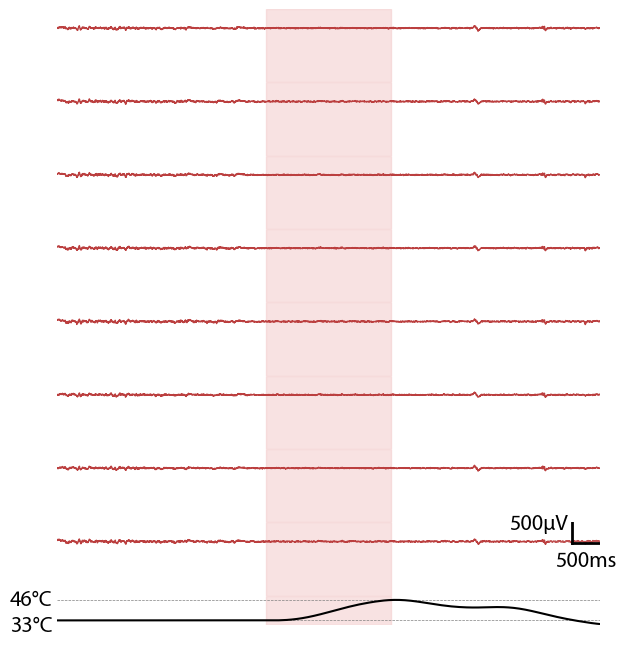

In [29]:
# Charger les données du fichier brut
dat_file = dat_file_path  # Chemin vers votre fichier .dat
data = np.fromfile(dat_file, dtype=np.float32)  # Charger les données brutes

channel_map = np.load(gui_fold + "/channel_map.npy").reshape(-1, 8)

n_shanks, channels_per_shank = channel_map.shape  # Dimensions du mapping
n_channels = n_shanks * channels_per_shank  # Nombre total de canaux

assert data.size % n_channels == 0, "Le nombre de canaux ne correspond pas aux données chargées."

# Paramètres
sampling_rate = 30000  # Fréquence d'échantillonnage

# Reshape des données
data_reshaped = data.reshape((-1, n_channels))

# Réorganiser les canaux selon le mapping
mapped_indices = channel_map.flatten()
data_mapped = data_reshaped[:, mapped_indices]

# Sélection d'un shank spécifique
shank_id = 0  
shank_channels = channel_map[shank_id]  
data_shank = data_mapped[:, shank_channels] 

id_stim = 4  # 0, 1, 3, 5 = movmt / 2, 6 = pas top / 4 = plat



for i in range(n_stims):
    # Calcul des bornes pour chaque période en fonction du stimulus
    stim_start = t_stim_start[id_stim]
    stim_end = stim_start + 2.2

# Définir la période d'affichage
stim_duration = stim_end - stim_start

start_time = stim_start - stim_duration - 1.5
end_time = stim_end + stim_duration + 1.5

start_sample = int(start_time * sampling_rate)
end_sample = int(end_time * sampling_rate)

# Extraire les données pour cette plage
data_to_plot = data_shank[start_sample:end_sample, :]
time = np.arange(start_sample, end_sample) / sampling_rate  

# Inverser l'ordre pour affichage correct
shank_channels_reversed = shank_channels[::-1]  
data_to_plot_reversed = data_to_plot[:, ::-1]  


# Fonction pour appliquer un filtre passe-bas
def lowpass_filter(data, cutoff=200, fs=30000, order=4):
    nyquist = 0.5 * fs  # Fréquence de Nyquist
    normal_cutoff = cutoff / nyquist
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    return filtfilt(b, a, data, axis=0)

# Appliquer le filtrage passe-bas Butterworth
data_filtered = lowpass_filter(data_to_plot_reversed)

# Appliquer le filtre Savitzky-Golay (fenêtre = 101, polynôme = 3)
data_filtered_savgol = savgol_filter(data_filtered, window_length=101, polyorder=3, axis=0)


# Calculer les limites de l'axe Y
y_max = np.max(data_filtered_savgol)
y_min = np.min(data_filtered_savgol)


y_max_rounded = np.ceil(y_max / 10) * 10
y_min_rounded = np.floor(y_min / 10) * 10

print(f"min : {y_min}, max : {y_max}")
print(f"Valeur minimale arrondie: {y_min_rounded}, Valeur maximale arrondie: {y_max_rounded}")


# === Création des subplots ===
fig, axs = plt.subplots(nrows=channels_per_shank + 1, ncols=1, figsize=(7, 1 * channels_per_shank), gridspec_kw={'height_ratios': [1] * channels_per_shank + [0.4]})

# Tracer les signaux des électrodes
for i in range(channels_per_shank):
    real_channel = shank_channels_reversed[i]  
    axs[i].plot(time, data_filtered_savgol[:, i], color="#bb3f3f", linewidth=1)
    axs[i].axis('off')
    axs[i].axvspan(stim_start, stim_end, color='#F2C7C7', alpha=0.5, label='Tactile stim', zorder=0)
    axs[i].set_xlim(start_time, end_time)
    axs[i].set_ylim(-710, 250)
    # axs[i].set_ylim(y_min_tac, y_max_tac)


# === Tracer la temp subplot ===

# Tracer les signaux des électrodes
for i in range(n_stims):
    # Masque ajusté pour les données de température
    mask = (t_lfps >= time.min()) & (t_lfps <= time.max())  # S'assurer que t_lfps est dans la plage de 'time'
    # Appliquer la condition de stimulation pour la température
    mask &= (t_lfps > t_stim_start[id_stim] - 4 * stim_duration) & (t_lfps < t_stim_start[id_stim] + 4 * stim_duration)
    # Extraire les données de température basées sur le masque ajusté
    t_plot = t_lfps[mask] - t_stim_start[id_stim]  # Décalage pour aligner la période de stimulation
    t_plot = t_plot - t_plot.min() + time.min()
    temp_plot = therm_stim[mask]

# Définir la fonction de lissage avec une moyenne mobile
def moving_average(data, window_size):
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')

# Paramètres de la fenêtre de lissage
window_size = 5  # Taille de la fenêtre (par exemple, 10 points)

# Lissage de la température avec la moyenne mobile
temp_plot_smoothed = moving_average(temp_plot, window_size)

# Tracage de la température
axs[-1].plot(t_plot[window_size-1:], temp_plot_smoothed, color='k', linewidth=1.5)  # Aligner le temps avec les données lissées

# Réajuster la plage temporelle de la période de stimulation
axs[-1].axvspan(stim_start, stim_end, color='#F2C7C7', alpha=0.5, label='Cool stim', zorder=0)

# Ré-ajuster les limites de x et y sur axs[-1]
axs[-1].set_xlim(time.min(), time.max())
axs[-1].tick_params(axis='y', which='both', length=0)
axs[-1].set_yticks([31, 48])
axs[-1].set_yticklabels(['33°C', '46°C'], fontsize=16)
axs[-1].set_ylim(30, 49)

# Ajouter deux lignes horizontales fines à y = 33 et y = 15
axs[-1].axhline(y=33, color='grey', linewidth=0.5, linestyle='--', zorder=0)  # Ligne à y = 33
axs[-1].axhline(y=46, color='grey', linewidth=0.5, linestyle='--', zorder=0)  # Ligne à y = 15


# Supprimer l'axe des X et les bordures du haut et droite
axs[-1].get_xaxis().set_visible(False)  # Cache l'axe des X
axs[-1].spines['top'].set_visible(False)  # Cache la bordure du haut
axs[-1].spines['right'].set_visible(False)  # Cache la bordure de droite
axs[-1].spines['bottom'].set_visible(False)  # Cache la bordure de droite
axs[-1].spines['left'].set_visible(False)  # Cache la bordure de droite



# === boîte de légende en bas à droite du dernier subplot ===
# Choisir le subplot 7 (indice 6, car les indices commencent à 0)
shank_id = 7  # On veut placer la boîte dans le subplot 7

# Positionner la boîte en bas à droite du subplot 7
origin_x = end_time - 0.5  # Position en X (temps)
origin_y = y_min + (y_max - y_min) * 0.2  # Position en Y (amplitude)

# Ajouter une boîte blanche pour améliorer la visibilité
legend_box = patches.FancyBboxPatch((origin_x - 0.2, origin_y - 10), 1.2, 60, 
                                    boxstyle="round,pad=0.2", edgecolor='white', 
                                    facecolor='white', alpha=0.1, lw=0.5, zorder=10)
axs[shank_id].add_patch(legend_box)  # Ajouter la boîte de légende dans le subplot 7

# Ajouter l’échelle de temps (barre horizontale)
time_x_end = origin_x + 0.5  # Longueur = 0.5 seconde
axs[shank_id].plot([origin_x, time_x_end], [origin_y, origin_y], color='black', linewidth=2, zorder=11)
axs[shank_id].text((origin_x + time_x_end) / 2, origin_y - 100, "500ms", fontsize=16, ha='center', va='top')

# Ajouter l’échelle d’amplitude (barre verticale)
amp_y_end = origin_y + 500  # Hauteur = 50 µV
axs[shank_id].plot([origin_x, origin_x], [origin_y, amp_y_end], color='black', linewidth=2, zorder=11)
axs[shank_id].text(origin_x - 1.1, (origin_y + amp_y_end) / 2 + 10, "500µV", fontsize=16, ha='left', va='center')

# Ajuster l'espacement des subplots sans les décaler
fig.subplots_adjust(hspace=0.001)

# Sauvegarder la figure
plt.savefig(os.path.join(saving_dir, '4Db_ML2_warm_cont_raw_traces.png'), format='png', dpi=300)
plt.savefig(os.path.join(saving_dir, '4Db_ML2_warm_cont_raw_traces.svg'), format='svg', dpi=300)

plt.show()

#

### Fig 4.E - Exemple raster for thermic warm stim one neuron (8 stim)

Cluster : temp_39


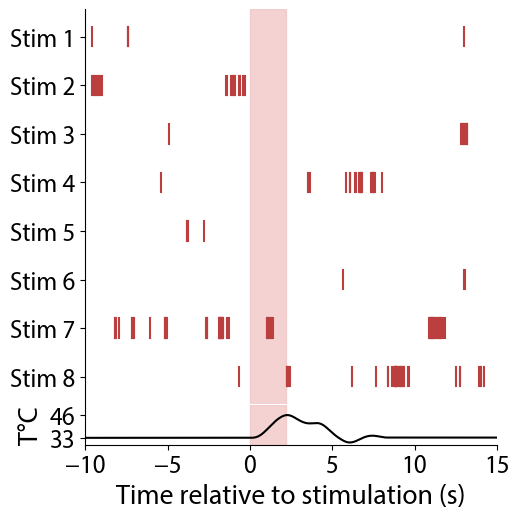

In [30]:
# Paramètres
time_before_stim = 10  # 10 secondes avant le début du stimulus
time_after_stim = 15   # 15 secondes après le début du stimulus

# Sélectionner un valid_key
valid_key = valid_keys[16]  # Choisir un seul neurone 16, 22, 3
print(f'Cluster : {valid_key}')

# Récupérer les spikes pour ce neurone spécifique
spikes = dataset['spiketimes'][valid_key]

# === Création des subplots ===
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(5, 5), sharex=True, gridspec_kw={'height_ratios': [10, 1]})

# Tracer les spikes pour chaque stimulus
for i in range(len(t_stim_start)):  # Pour chaque stimulus (de 1 à 8)
    stim_start = t_stim_start[i]
    stim_end = t_stim_end[i]

    # Définir la fenêtre d'intérêt autour du stimulus (10 secondes avant et après)
    window_start = stim_start - time_before_stim
    window_end = stim_end + time_after_stim

    # Sélectionner les spikes dans cette fenêtre et les aligner par rapport au début du stimulus
    selected_spikes = [spike - stim_start for spike in spikes if window_start <= spike <= window_end]

    # Tracer les spikes alignés pour ce stimulus
    for spike in selected_spikes:
        ax1.plot([spike, spike], [i + 0.2, i - 0.2], color='#bb3f3f')  # Ligne verticale pour chaque spike

# Paramétrage du raster plot
ax1.set_ylabel('')  # Label de l'axe Y

# Inverser l'ordre des ticks de l'axe Y et l'axe Y
ax1.set_yticks(range(len(t_stim_start)-1, -1, -1))  # Inverser l'ordre des ticks
ax1.set_yticklabels([f'Stim {i+1}' for i in range(len(t_stim_start)-1, -1, -1)])  # Labels des stimuli inversés

# Limiter l'axe des x pour afficher la fenêtre autour du stimulus
ax1.set_xlim([-time_before_stim, time_after_stim])  # Afficher de -10s à +15s autour de chaque stimulus

# Inverser l'axe Y pour avoir Stim 1 en haut et Stim 8 en bas
ax1.invert_yaxis()  # Inverse l'axe Y

ax1.axvspan(0, 2.2, color='#F2C7C7', alpha=0.8, label='Warm stim', zorder=0)

# Suppression des bordures superflues
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['bottom'].set_visible(False)
ax1.get_xaxis().set_visible(False)  # Cache l'axe des X


# === Tracer les pulses tactiles en dernier subplot ===
# **Deuxième subplot : Température**
ax2.plot(t_plot_raster, temp_plot_smoothed_raster, color='k',  linewidth=1.5)
ax2.axvspan(0, 2.2, color='#F2C7C7', alpha=0.8, label='Warm stim', zorder=0)
ax2.set_ylabel("T°C")
ax2.set_xlabel("Time relative to stimulation (s)")
ax2.set_yticks([33, 46])
ax2.set_yticklabels(['33', '46'])
ax2.set_ylim([29, 52])
ax2.set_xlim([-time_before_stim, time_after_stim])  # Afficher de -10s à +15s autour de chaque stimulus

# Suppression des bordures superflues
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# Ajustements finaux
plt.tight_layout(pad=0.0001, h_pad=0.0001)

# Sauvegarder la figure
plt.savefig(os.path.join(saving_dir, '4E_ML2_warm_cont_raster.png'), format='png', dpi=300)
plt.savefig(os.path.join(saving_dir, '4E_ML2_warm_cont_raster.svg'), format='svg', dpi=300)

plt.show()


#

### Fig 4.F - response rate Thermic cool and warm contra vs ipsi

Directories communs à toutes les conditions : {'2024.01.30_M2', '2024.02.29', '2024.02.22', '2024.02.05_M1'}
n Cool_Cont = 4
n Cool_Ipsi = 4
n Warm_Cont = 4
n Warm_Ipsi = 4
       Source          SS  DF         MS         F     p-unc       np2
0         cdt   40.502630   1  40.502630  1.699897  0.216759  0.124081
1        side    0.062699   1   0.062699  0.002631  0.959932  0.000219
2  cdt * side   16.307682   1  16.307682  0.684434  0.424211  0.053959
3    Residual  285.918227  12  23.826519       NaN       NaN       NaN


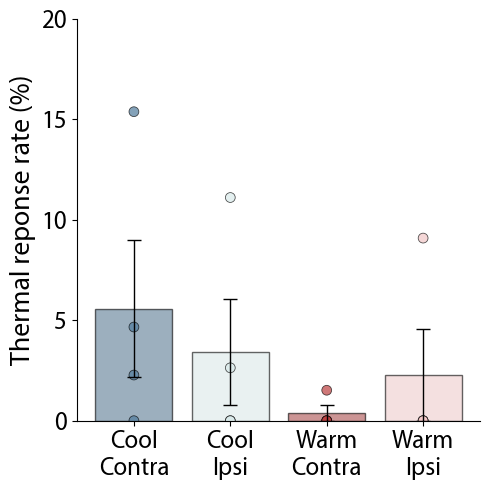


Cool_Cont : mean = 5.58 ± 3.40
Cool_Ipsi : mean = 3.44 ± 2.63

Warm_Cont : mean = 0.38 ± 0.38
Warm_Ipsi : mean = 2.27 ± 2.27
Le fichier a été sauvegardé sous : U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/spyking_analysis/plot_for_fig/Plot_svg_illustrator\Plot_Fig_4_WT_vs_ML2_Thq\df_anova_resp_rate_ML2_cool_warm_cont_ipsi.xlsx

Voir Graphpad pour Anova


In [82]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import sem, wilcoxon

# Charger les fichiers en vérifiant leur existence
file_paths = {
    "Cool_Cont": "U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/spyking_analysis/cluster_response_rate/Thq-cool_Wcont_ML2_resp_rate.xlsx",
    "Cool_Ipsi": "U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/spyking_analysis/cluster_response_rate/Thq-cool_Wipsi_ML2_resp_rate.xlsx",
    "Warm_Cont": "U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/spyking_analysis/cluster_response_rate/Thq-hot_Wcont_ML2_resp_rate.xlsx",
    "Warm_Ipsi": "U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/spyking_analysis/cluster_response_rate/Thq-hot_Wipsi_ML2_resp_rate.xlsx"
}

dfs = {}
for key, path in file_paths.items():
    if os.path.exists(path):
        dfs[key] = pd.read_excel(path)
    else:
        print(f"⚠️ Fichier non trouvé : {path}")

# Vérifier la présence des colonnes nécessaires
def check_columns(df, required_cols):
    return all(col in df.columns for col in required_cols)

required_columns = ['directory', 'file_name', 'response']

for key, df in dfs.items():
    if not check_columns(df, required_columns):
        raise ValueError(f"Le fichier {key} ne contient pas toutes les colonnes requises {required_columns}")

# Calcul du pourcentage de réponse
def calculate_response_percentage(df):
    response_percentage = df.groupby(['directory', 'file_name'])['response'].agg(lambda x: (x.sum() / len(x)) * 100).reset_index()
    response_percentage.rename(columns={'response': 'response_percentage'}, inplace=True)
    return response_percentage

# Appliquer la fonction sur chaque DataFrame
response_percentages = {key: calculate_response_percentage(df) for key, df in dfs.items()}

# Trouver les 'directory' communs
common_directories = set.intersection(
    *(set(df['directory']) for df in response_percentages.values())
)

print("Directories communs à toutes les conditions :", common_directories)

# Filtrer les DataFrames pour ne conserver que les 'directory' communs
filtered_dfs = {key: df[df['directory'].isin(common_directories)] for key, df in response_percentages.items()}

# Moyenne des pourcentages de réponse par 'directory'
average_response_percentages = {key: df.groupby('directory')['response_percentage'].mean().reset_index() for key, df in filtered_dfs.items()}

# Ajouter la colonne 'group'
for key in average_response_percentages:
    average_response_percentages[key]['group'] = key

# Fusionner les DataFrames
combined_df = pd.concat(average_response_percentages.values())

# Calcul du SEM par groupe
combined_df['sem'] = combined_df.groupby('group')['response_percentage'].transform(sem)

# Calcul du nombre d'observations (n)
n_values = {key: len(df) for key, df in average_response_percentages.items()}

# Affichage des n
for key, n in n_values.items():
    print(f"n {key} = {n}")

# Couleurs des groupes
colors = {'Cool_Cont': '#507b9c', 'Cool_Ipsi': '#D9EAEA', 
          'Warm_Cont': '#bb3f3f', 'Warm_Ipsi': '#F2C7C7'}
border_colors = 'k'

# Plot
plt.figure(figsize=(5, 5))

# Barplot avec erreur SEM
sns.barplot(x='group', y='response_percentage', data=combined_df, hue='group', palette=colors, capsize=0.1, alpha=0.6, edgecolor=border_colors, errorbar=None)

# Scatterplot des points individuels
sns.scatterplot(x='group', y='response_percentage', data=combined_df, hue='group', palette=colors, s=50, legend=False, marker='o', edgecolor=border_colors, alpha=0.7)

# Ajouter les barres d'erreur (SEM)
for i, group in enumerate(combined_df['group'].unique()):
    group_data = combined_df[combined_df['group'] == group]
    plt.errorbar(x=i, y=group_data['response_percentage'].mean(), yerr=group_data['sem'].mean(),
                 fmt='none', color=border_colors, capsize=5, elinewidth=1)

# 1. Séparation de la colonne 'group' en deux nouvelles colonnes 'cdt' et 'side'
combined_df[['cdt', 'side']] = combined_df['group'].str.split('_', expand=True)

# 2. Effectuer l'ANOVA à deux voies sur 'response_percentage' en utilisant 'cdt' et 'side' comme facteurs
anova = pg.anova(dv='response_percentage', between=['cdt', 'side'], data=combined_df, detailed=True)

# 3. Afficher les résultats de l'ANOVA
print(anova)

# Si un p-unc est inférieur à 0.05, vous pouvez procéder avec les comparaisons de paires
# Exemple de facteur significatif : 'side'
if anova['p-unc'][1] < 0.05:
    # Effectuer les tests de comparaison de paires avec Bonferroni
    pairwise_comparisons = pg.pairwise_ttests(dv='response_percentage', within='side', data=combined_df, correction='bonferroni')
    print(pairwise_comparisons)


# Ajouter le titre et labels
plt.xlabel('')
plt.ylabel('Thermal reponse rate (%)')
plt.xticks(ticks=[0, 1, 2, 3], labels=['Cool\nContra', 'Cool\nIpsi', 'Warm\nContra', 'Warm\nIpsi'])
plt.ylim(0, 20)
plt.yticks(range(0, 21, 5))

# Suppression des bordures superflues
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

# Sauvegarder la figure
plt.savefig(os.path.join(saving_dir, '4F_ML2_cool_warm_cont_ipsi_respo_rate.png'), format='png', dpi=300)
plt.savefig(os.path.join(saving_dir, '4F_ML2_cool_warm_cont_ipsi_respo_rate.svg'), format='svg', dpi=300)

plt.show()

############################    Metrics   ############################ 

# Exemple de filtrage de vos données pour créer les DataFrames
average_response_percentage_cool_cont = combined_df[combined_df['group'] == 'Cool_Cont']
average_response_percentage_cool_ipsi = combined_df[combined_df['group'] == 'Cool_Ipsi']
average_response_percentage_warm_cont = combined_df[combined_df['group'] == 'Warm_Cont']
average_response_percentage_warm_ipsi = combined_df[combined_df['group'] == 'Warm_Ipsi']

# Ensuite, vous pouvez calculer les moyennes et SEM comme suit :

# Calculer la moyenne et SEM pour 'Cool_Cont'
mean_cool_c = average_response_percentage_cool_cont['response_percentage'].mean()
sem_cool_c = sem(average_response_percentage_cool_cont['response_percentage'])

# Calculer la moyenne et SEM pour 'Cool_Ipsi'
mean_cool_i = average_response_percentage_cool_ipsi['response_percentage'].mean()
sem_cool_i = sem(average_response_percentage_cool_ipsi['response_percentage'])

# Calculer la moyenne et SEM pour 'Warm_Cont'
mean_warm_c = average_response_percentage_warm_cont['response_percentage'].mean()
sem_warm_c = sem(average_response_percentage_warm_cont['response_percentage'])

# Calculer la moyenne et SEM pour 'Warm_Ipsi'
mean_warm_i = average_response_percentage_warm_ipsi['response_percentage'].mean()
sem_warm_i = sem(average_response_percentage_warm_ipsi['response_percentage'])

# Afficher les résultats
print(f"\nCool_Cont : mean = {mean_cool_c:.2f} ± {sem_cool_c:.2f}")
print(f"Cool_Ipsi : mean = {mean_cool_i:.2f} ± {sem_cool_i:.2f}")
print(f"\nWarm_Cont : mean = {mean_warm_c:.2f} ± {sem_warm_c:.2f}")
print(f"Warm_Ipsi : mean = {mean_warm_i:.2f} ± {sem_warm_i:.2f}")


file_name = "df_anova_resp_rate_ML2_cool_warm_cont_ipsi.xlsx"

anova_path = os.path.join(saving_dir,file_name)

# Sauvegarder le DataFrame `df_combined` dans le fichier Excel
combined_df.to_excel(anova_path , index=False)

print(f"Le fichier a été sauvegardé sous : {anova_path}")


print (f'\nVoir Graphpad pour Anova')


### Fig 4.F_BIS - Cluster / Contingence - response rate Thermic cool and warm contra vs ipsi


Table de contingence (nombre d'occurences de 0 et 1 par groupe) :
response     0   1
Cool_Cont  274  15
Cool_Ipsi  137   4
Warm_Cont  169   1
Warm_Ipsi  137   1

Test chi2 de contingence entre groupes : chi2 = 11.126, p = 0.01106, dof = 3
=> Différence significative entre groupes

Tests post-hoc (test exact de Fisher) avec correction de Bonferroni :
Cool_Cont vs Cool_Ipsi : p = 0.3251, p corrigé = 1 -> non significatif
Cool_Cont vs Warm_Cont : p = 0.007636, p corrigé = 0.04582 -> SIGNIFICATIF
Cool_Cont vs Warm_Ipsi : p = 0.02652, p corrigé = 0.1591 -> non significatif
Cool_Ipsi vs Warm_Cont : p = 0.1802, p corrigé = 1 -> non significatif
Cool_Ipsi vs Warm_Ipsi : p = 0.3706, p corrigé = 1 -> non significatif
Warm_Cont vs Warm_Ipsi : p = 1, p corrigé = 1 -> non significatif


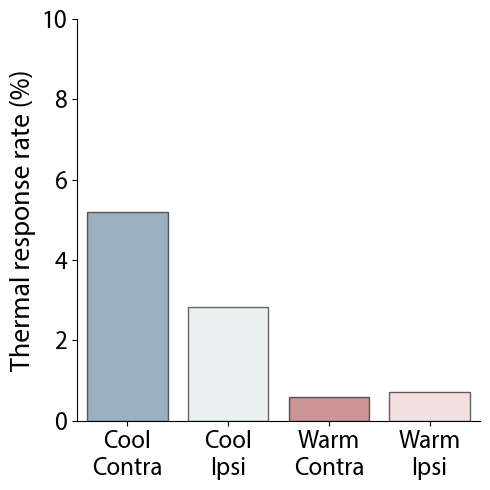


Métriques des réponses par groupe :
Cool_Cont : Moyenne = 0.05, Nombre de clusters = 289, Pourcentage de réponse = 5.2%
Cool_Ipsi : Moyenne = 0.03, Nombre de clusters = 141, Pourcentage de réponse = 2.8%
Warm_Cont : Moyenne = 0.01, Nombre de clusters = 170, Pourcentage de réponse = 0.6%
Warm_Ipsi : Moyenne = 0.01, Nombre de clusters = 138, Pourcentage de réponse = 0.7%


In [4]:
# Chemins fichiers
file_paths = {
    "Cool_Cont": "U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/spyking_analysis/cluster_response_rate/Thq-cool_Wcont_ML2_resp_rate.xlsx",
    "Cool_Ipsi": "U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/spyking_analysis/cluster_response_rate/Thq-cool_Wipsi_ML2_resp_rate.xlsx",
    "Warm_Cont": "U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/spyking_analysis/cluster_response_rate/Thq-hot_Wcont_ML2_resp_rate.xlsx",
    "Warm_Ipsi": "U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/spyking_analysis/cluster_response_rate/Thq-hot_Wipsi_ML2_resp_rate.xlsx"
}

# Chargement des données
dfs = {}
for key, path in file_paths.items():
    if os.path.exists(path):
        dfs[key] = pd.read_excel(path)
    else:
        print(f"⚠️ Fichier non trouvé : {path}")


# Calcul pourcentages réponse/non-réponse
group_counts = {}
for key, df in dfs.items():
    counts = df['response'].value_counts(normalize=True) * 100
    group_counts[key] = {
        'No Response (0)': counts.get(0, 0),
        'Response (1)': counts.get(1, 0)
    }


# DataFrame pour plot
contingency_df = pd.DataFrame(group_counts).T.reset_index().rename(columns={'index': 'group'})
contingency_melted = contingency_df.melt(id_vars='group', var_name='Response Type', value_name='Percentage')
contingency_melted_response_only = contingency_melted[contingency_melted['Response Type'] == 'Response (1)']


# Couleurs des groupes
response_colors = {'Cool_Cont': '#507b9c', 'Cool_Ipsi': '#D9EAEA', 
          'Warm_Cont': '#bb3f3f', 'Warm_Ipsi': '#F2C7C7'}

border_colors = ['black'] * 4  # Épaisseur des bords

# Plot barplot
plt.figure(figsize=(5, 5))
ax = sns.barplot(
    data=contingency_melted_response_only,
    x='group', y='Percentage', hue='group',
    palette=response_colors,
    edgecolor=border_colors,
    alpha=0.6, errorbar=None
)

# Table de contingence brute
contingency_table = pd.DataFrame({
    key: dfs[key]['response'].value_counts() for key in dfs.keys()
}).fillna(0).astype(int).T

print("\nTable de contingence (nombre d'occurences de 0 et 1 par groupe) :")
print(contingency_table)

# Test global chi2
chi2, p, dof, expected = chi2_contingency(contingency_table.values)
print(f"\nTest chi2 de contingence entre groupes : chi2 = {chi2:.3f}, p = {p:.4g}, dof = {dof}")
if p < 0.05:
    print("=> Différence significative entre groupes")
else:
    print("=> Pas de différence significative entre groupes")

# Tests post-hoc (Fisher exact test)
groups = contingency_table.index.tolist()
results = []

for g1, g2 in combinations(groups, 2):
    table = contingency_table.loc[[g1, g2], [0, 1]].values
    oddsratio, pvalue = fisher_exact(table)
    results.append({'Group1': g1, 'Group2': g2, 'pvalue': pvalue})

# Correction Bonferroni
num_tests = len(results)
for res in results:
    res['pvalue_corrected'] = min(res['pvalue'] * num_tests, 1.0)

print("\nTests post-hoc (test exact de Fisher) avec correction de Bonferroni :")
for res in results:
    signif = "SIGNIFICATIF" if res['pvalue_corrected'] < 0.05 else "non significatif"
    print(f"{res['Group1']} vs {res['Group2']} : p = {res['pvalue']:.4g}, p corrigé = {res['pvalue_corrected']:.4g} -> {signif}")


# # Annoter les significativités sur le plot
# def add_contingence_sig_bar(ax, x1, x2, y, p_val, height_offset=0.15, fontsize=18):
#     significance = ""
#     if p_val < 0.001:
#         significance = "***"
#     elif p_val < 0.01:
#         significance = "**"
#     elif p_val < 0.05:
#         significance = "*"
#     if significance:
#         ax.plot([x1, x1, x2, x2], [y, y + height_offset, y + height_offset, y], lw=1, color='black')
#         ax.text((x1 + x2) * 0.5, y , significance,
#                 ha='center', va='bottom', color='black', fontsize=fontsize)

# positions = {g: i for i, g in enumerate(contingency_df['group'])}
# y_offset = contingency_melted_response_only['Percentage'].max() + 0.5
# spacing_between_bars = 0.8

# for res in results:
#     if res['pvalue_corrected'] < 0.05:
#         x1 = positions[res['Group1']]
#         x2 = positions[res['Group2']]
#         add_contingence_sig_bar(ax, x1, x2, y_offset, res['pvalue_corrected'])
#         y_offset += spacing_between_bars

# Labels
plt.xlabel('')
plt.ylabel('Thermal response rate (%)')
plt.xticks(ticks=[0, 1, 2, 3], labels=['Cool\nContra', 'Cool\nIpsi', 'Warm\nContra', 'Warm\nIpsi'])
plt.yticks(range(0, 11, 2))
plt.ylim(0, 10)

# Suppression bordures inutiles
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

# Sauvegarder la figure
plt.savefig(os.path.join(saving_dir, '4F_BIS_ML2_cool_warm_cont_ipsi_respo_rate_cluster_contingence.png'), format='png', dpi=300)
plt.savefig(os.path.join(saving_dir, '4F_BIS_ML2_cool_warm_cont_ipsi_respo_rate_cluster_contingence.svg'), format='svg', dpi=300)


plt.show()


############################ Metrics ############################

print("\nMétriques des réponses par groupe :")
for key, df in dfs.items():
    mean_response = df['response'].mean()  # moyenne des 0 et 1 = taux de réponse en fraction
    n_clusters = len(df)
    response_percentage = mean_response * 100
    print(f"{key} : Moyenne = {mean_response:.2f}, Nombre de clusters = {n_clusters}, Pourcentage de réponse = {response_percentage:.1f}%")



#

### Fig 4.G - ML2 Thermic cool & warm - contra sdf for TS

In [35]:
# # Charger les fichiers
# WT_tac_cont_path = "U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/spyking_analysis/mean_sdf_period_cluster/split_files/Thq-cool_Wcont_ML2_grouped.xlsx"
# df_WT_tac_cont = pd.read_excel(WT_tac_cont_path)

# WT_tac_ipsi_path = "U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/spyking_analysis/mean_sdf_period_cluster/split_files/Thq-hot_Wcont_ML2_grouped.xlsx"
# df_WT_tac_ipsi = pd.read_excel(WT_tac_ipsi_path)

# WT_tac_cont_ipsi_path = "U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/spyking_analysis/mean_sdf_period_cluster/split_files/Thq-cool_Wipsi_ML2_grouped.xlsx"
# df_WT_tac_cont_ipsi = pd.read_excel(WT_tac_cont_ipsi_path)

# WT_tac_ipsi_ipsi_path = "U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/spyking_analysis/mean_sdf_period_cluster/split_files/Thq-hot_Wipsi_ML2_grouped.xlsx"
# df_WT_tac_ipsi_ipsi = pd.read_excel(WT_tac_ipsi_ipsi_path)

# # Filtrer pour obtenir uniquement les données où la période est 'Stim'
# df_WT_tac_cont_ts = df_WT_tac_cont[df_WT_tac_cont['period'] == 'Stim']
# df_WT_tac_ipsi_ts = df_WT_tac_ipsi[df_WT_tac_ipsi['period'] == 'Stim']
# df_WT_tac_cont_ipsi_ts = df_WT_tac_cont_ipsi[df_WT_tac_cont_ipsi['period'] == 'Stim']
# df_WT_tac_ipsi_ipsi_ts = df_WT_tac_ipsi_ipsi[df_WT_tac_ipsi_ipsi['period'] == 'Stim']

# # Trouver les 'directory' communs à toutes les conditions
# common_directories = set.intersection(
#     *(set(df['directory']) for df in [df_WT_tac_cont_ts, df_WT_tac_ipsi_ts, df_WT_tac_cont_ipsi_ts, df_WT_tac_ipsi_ipsi_ts])
# )

# print("Directories communs à toutes les conditions :", common_directories)

# # Filtrer les DataFrames pour ne conserver que les 'directory' communs
# df_WT_tac_cont_ts_filtered = df_WT_tac_cont_ts[df_WT_tac_cont_ts['directory'].isin(common_directories)]
# df_WT_tac_ipsi_ts_filtered = df_WT_tac_ipsi_ts[df_WT_tac_ipsi_ts['directory'].isin(common_directories)]
# df_WT_tac_cont_ipsi_ts_filtered = df_WT_tac_cont_ipsi_ts[df_WT_tac_cont_ipsi_ts['directory'].isin(common_directories)]
# df_WT_tac_ipsi_ipsi_ts_filtered = df_WT_tac_ipsi_ipsi_ts[df_WT_tac_ipsi_ipsi_ts['directory'].isin(common_directories)]

# # Calculer la moyenne de 'sdf' en groupant par 'directory' pour chaque condition
# df_WT_tac_cont_grouped = df_WT_tac_cont_ts_filtered.groupby('directory')['sdf'].mean().reset_index()
# df_WT_tac_ipsi_grouped = df_WT_tac_ipsi_ts_filtered.groupby('directory')['sdf'].mean().reset_index()
# df_WT_tac_cont_ipsi_grouped = df_WT_tac_cont_ipsi_ts_filtered.groupby('directory')['sdf'].mean().reset_index()
# df_WT_tac_ipsi_ipsi_grouped = df_WT_tac_ipsi_ipsi_ts_filtered.groupby('directory')['sdf'].mean().reset_index()

# # Ajouter une colonne pour différencier les groupes
# df_WT_tac_cont_grouped['group'] = 'Cool_Cont'
# df_WT_tac_ipsi_grouped['group'] = 'Warm_Cont'
# df_WT_tac_cont_ipsi_grouped['group'] = 'Cool_Ipsi'
# df_WT_tac_ipsi_ipsi_grouped['group'] = 'Warm_Ipsi'

# # Fusionner les données pour analyse statistique
# df_merged = pd.concat([df_WT_tac_cont_grouped, df_WT_tac_ipsi_grouped, df_WT_tac_cont_ipsi_grouped, df_WT_tac_ipsi_ipsi_grouped])

# # Fusionner pour le tracé
# df_combined = pd.concat([df_WT_tac_cont_grouped, df_WT_tac_ipsi_grouped, df_WT_tac_cont_ipsi_grouped, df_WT_tac_ipsi_ipsi_grouped])

# # Couleurs des groupes
# colors = {'Cool_Cont': '#507b9c', 'Cool_Ipsi': '#D9EAEA', 
#           'Warm_Cont': '#bb3f3f', 'Warm_Ipsi': '#F2C7C7'}
# border_colors = 'k'

# # Création du plot
# plt.figure(figsize=(5, 5))

# # Ajouter les points individuels pour chaque 'directory'
# for group in ['Cool_Cont', 'Warm_Cont', 'Cool_Ipsi', 'Warm_Ipsi']:
#     subset = df_combined[df_combined['group'] == group]
#     plt.scatter(subset['group'], subset['sdf'], color=colors[group], edgecolor=border_colors, linewidth=1, alpha=0.6, s=50, zorder=6)

# # Calcul des moyennes et SEM
# mean_sdf = df_combined.groupby('group')['sdf'].mean()
# sem_sdf = df_combined.groupby('group')['sdf'].sem()

# # Ajouter les moyennes avec barres d'erreur
# plt.scatter(mean_sdf.index, mean_sdf.values, color='black', s=80, label='Mean', zorder=10)
# plt.errorbar(mean_sdf.index, mean_sdf.values, yerr=sem_sdf.values, fmt='o', color='black', capsize=5, zorder=8)

# # Paramètres des axes
# plt.xlabel("")
# plt.ylabel("Thermal Mean Spike Probability")
# plt.xticks(range(4), ['Cool\nContra', 'Warm\nContra', 'Cool\nIpsi', 'Warm\nIpsi'])
# plt.xlim(-0.5, 3.5)
# plt.ylim(0, 0.1)

# # Suppression des bordures superflues
# ax = plt.gca()
# ax.spines['top'].set_visible(False)
# ax.spines['right'].set_visible(False)

# # Afficher le plot
# plt.tight_layout()


# # Sauvegarder la figure
# plt.savefig(os.path.join(saving_dir, '4G_ML2_SDF_cool_warm_cont_ipsi.png'), format='png', dpi=300)
# plt.savefig(os.path.join(saving_dir, '4G_ML2_SDF_cool_warm_cont_ipsi.svg'), format='svg', dpi=300)


# plt.show()


# file_name = "df_anova_sdf_ML2_cool_warm_cont_ipsi.xlsx"

# anova_path = os.path.join(saving_dir,file_name)

# # Sauvegarder le DataFrame `df_combined` dans le fichier Excel
# df_combined.to_excel(anova_path , index=False)

# print(f"Le fichier a été sauvegardé sous : {anova_path}")




# ############################ Metrics ############################

# # Afficher les résultats avec le nombre de points pour chaque groupe
# print("\nMoyenne, SEM et nombre de points pour chaque groupe :")
# for group in ['Cool_Cont', 'Warm_Cont', 'Cool_Ipsi', 'Warm_Ipsi']:
#     # Calcul de la moyenne et de l'écart-type
#     mean = mean_sdf[group]
#     sem = sem_sdf[group]
#     # Calcul du nombre de points dans chaque groupe
#     n_points = len(df_combined[df_combined['group'] == group])
#     # Affichage du groupe, de la moyenne, de l'écart-type et du nombre de points
#     print(f"Groupe: {group}, Mean: {mean:.6f} ± SEM: {sem:.6f}, N: {n_points}")


# # Calculer nombre de clusters par condition
# n_cluster_tac_cont = len(df_WT_tac_cont_ts_filtered)
# n_cluster_tac_ipsi = len(df_WT_tac_ipsi_ts_filtered)
# n_cluster_tac_cont_ipsi = len(df_WT_tac_cont_ipsi_ts_filtered)
# n_cluster_tac_ipsi_ipsi = len(df_WT_tac_ipsi_ipsi_ts_filtered)

# print(f"\nCool_Cont: n_cluster : {n_cluster_tac_cont}")
# print(f"Warm_Cont: n_cluster : {n_cluster_tac_ipsi}")
# print(f"Cool_Ipsi: n_cluster : {n_cluster_tac_cont_ipsi}")
# print(f"Warm_Ipsi: n_cluster : {n_cluster_tac_ipsi_ipsi}")

# print (f'\nVoir Graphpas pour Anova')

Directories communs à toutes les conditions : {'2024.02.22', '2024.02.29', '2024.02.05_M1', '2024.01.30_M2'}


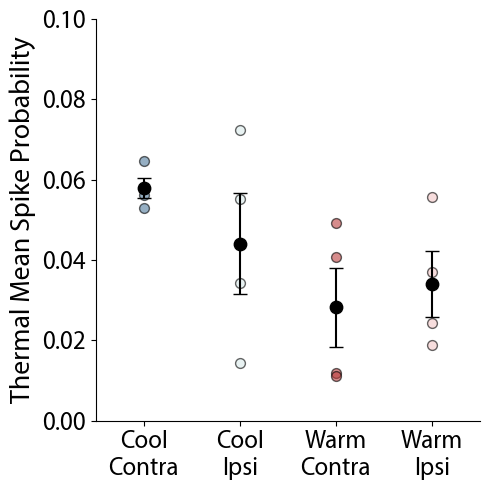

Le fichier a été sauvegardé sous : U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/spyking_analysis/plot_for_fig/Plot_svg_illustrator\Plot_Fig_4_WT_vs_ML2_Thq\df_anova_sdf_ML2_cool_warm_cont_ipsi.xlsx

Moyenne, SEM et nombre de points pour chaque groupe :
Groupe: Cool_Cont, Mean: 0.057857 ± SEM: 0.002488, N: 4
Groupe: Cool_Ipsi, Mean: 0.044059 ± SEM: 0.012615, N: 4
Groupe: Warm_Cont, Mean: 0.028234 ± SEM: 0.009834, N: 4
Groupe: Warm_Ipsi, Mean: 0.033953 ± SEM: 0.008205, N: 4

Cool_Cont: n_cluster : 270
Cool_Ipsi: n_cluster : 141
Warm_Cont: n_cluster : 143
Warm_Ipsi: n_cluster : 137

 ⚠️ Voir Graphpad pour Anova 2 way ⚠️


In [37]:
# Charger les fichiers
ML2_cool_cont_path = "U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/spyking_analysis/mean_sdf_period_cluster/split_files/Thq-cool_Wcont_ML2_grouped.xlsx"
df_ML2_cool_cont = pd.read_excel(ML2_cool_cont_path)

ML2_cool_ipsi_path = "U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/spyking_analysis/mean_sdf_period_cluster/split_files/Thq-cool_Wipsi_ML2_grouped.xlsx"
df_ML2_cool_ipsi = pd.read_excel(ML2_cool_ipsi_path)

ML2_warm_cont_path = "U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/spyking_analysis/mean_sdf_period_cluster/split_files/Thq-hot_Wcont_ML2_grouped.xlsx"
df_ML2_warm_cont = pd.read_excel(ML2_warm_cont_path)

ML2_warm_ipsi_path = "U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/spyking_analysis/mean_sdf_period_cluster/split_files/Thq-hot_Wipsi_ML2_grouped.xlsx"
df_ML2_warm_ipsi = pd.read_excel(ML2_warm_ipsi_path)


# Filtrer pour obtenir uniquement les données où la période est 'Stim'
df_ML2_cool_cont_ts = df_ML2_cool_cont[df_ML2_cool_cont['period'] == 'Stim']
df_ML2_cool_ipsi_ts = df_ML2_cool_ipsi[df_ML2_cool_ipsi['period'] == 'Stim']
df_ML2_warm_cont_ts = df_ML2_warm_cont[df_ML2_warm_cont['period'] == 'Stim']
df_ML2_warm_ipsi_ts = df_ML2_warm_ipsi[df_ML2_warm_ipsi['period'] == 'Stim']


# Trouver les 'directory' communs à toutes les conditions
common_directories = set.intersection(
    *(set(df['directory']) for df in [df_ML2_cool_cont_ts, df_ML2_cool_ipsi_ts, df_ML2_warm_cont_ts, df_ML2_warm_ipsi_ts])
)

print("Directories communs à toutes les conditions :", common_directories)

# Filtrer les DataFrames pour ne conserver que les 'directory' communs
df_ML2_cool_cont_ts_filtered = df_ML2_cool_cont_ts[df_ML2_cool_cont_ts['directory'].isin(common_directories)]
df_ML2_cool_ipsi_ts_filtered = df_ML2_cool_ipsi_ts[df_ML2_cool_ipsi_ts['directory'].isin(common_directories)]
df_ML2_warm_cont_ts_filtered = df_ML2_warm_cont_ts[df_ML2_warm_cont_ts['directory'].isin(common_directories)]
df_ML2_warm_ipsi_ts_filtered = df_ML2_warm_ipsi_ts[df_ML2_warm_ipsi_ts['directory'].isin(common_directories)]


# Regrouper par neurone unique et période pour s'assurer d'une entrée unique
df_ML2_cool_cont_ts_filtered_animal = df_ML2_cool_cont_ts_filtered.groupby('directory')['sdf'].mean().reset_index()
df_ML2_cool_ipsi_ts_filtered_animal = df_ML2_cool_ipsi_ts_filtered.groupby('directory')['sdf'].mean().reset_index()
df_ML2_warm_cont_ts_filtered_animal = df_ML2_warm_cont_ts_filtered.groupby('directory')['sdf'].mean().reset_index()
df_ML2_warm_ipsi_ts_filtered_animal = df_ML2_warm_ipsi_ts_filtered.groupby('directory')['sdf'].mean().reset_index()


# Ajouter une colonne pour différencier les groupes
df_ML2_cool_cont_ts_filtered_animal['group'] = 'Cool_Cont'
df_ML2_cool_ipsi_ts_filtered_animal['group'] = 'Cool_Ipsi' 
df_ML2_warm_cont_ts_filtered_animal['group'] = 'Warm_Cont' 
df_ML2_warm_ipsi_ts_filtered_animal['group'] = 'Warm_Ipsi' 


# Fusionner les données pour analyse statistique
df_merged = pd.concat([df_ML2_cool_cont_ts_filtered_animal, df_ML2_cool_ipsi_ts_filtered_animal, df_ML2_warm_cont_ts_filtered_animal, df_ML2_warm_ipsi_ts_filtered_animal])

# Fusionner pour le tracé
df_combined = pd.concat([df_ML2_cool_cont_ts_filtered_animal, df_ML2_cool_ipsi_ts_filtered_animal, df_ML2_warm_cont_ts_filtered_animal, df_ML2_warm_ipsi_ts_filtered_animal])

# Couleurs des groupes
colors = {'Cool_Cont': '#507b9c', 'Cool_Ipsi': '#D9EAEA', 
          'Warm_Cont': '#bb3f3f', 'Warm_Ipsi': '#F2C7C7'}

border_colors = 'k'

# Création du plot
plt.figure(figsize=(5, 5))

# Ajouter les points individuels pour chaque 'directory'
for group in ['Cool_Cont','Cool_Ipsi', 'Warm_Cont', 'Warm_Ipsi']:
    subset = df_combined[df_combined['group'] == group]
    plt.scatter(subset['group'], subset['sdf'], color=colors[group], edgecolor=border_colors, linewidth=1, alpha=0.6, s=50, zorder=6)

# Calcul des moyennes et SEM
mean_sdf = df_combined.groupby('group')['sdf'].mean()
sem_sdf = df_combined.groupby('group')['sdf'].sem()

# Ajouter les moyennes avec barres d'erreur
plt.scatter(mean_sdf.index, mean_sdf.values, color='black', s=80, label='Mean', zorder=10)
plt.errorbar(mean_sdf.index, mean_sdf.values, yerr=sem_sdf.values, fmt='o', color='black', capsize=5, zorder=8)

# Paramètres des axes
plt.xlabel("")
plt.ylabel("Thermal Mean Spike Probability")
plt.xticks(range(4), ['Cool\nContra', 'Cool\nIpsi', 'Warm\nContra', 'Warm\nIpsi'])
plt.xlim(-0.5, 3.5)
plt.ylim(0, 0.1)

# Suppression des bordures superflues
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Afficher le plot
plt.tight_layout()


# Sauvegarder la figure
plt.savefig(os.path.join(saving_dir, '4G_ML2_SDF_cool_warm_cont_ipsi.png'), format='png', dpi=300)
plt.savefig(os.path.join(saving_dir, '4G_ML2_SDF_cool_warm_cont_ipsi.svg'), format='svg', dpi=300)


plt.show()


file_name = "df_anova_sdf_ML2_cool_warm_cont_ipsi.xlsx"

anova_path = os.path.join(saving_dir,file_name)

# Sauvegarder le DataFrame `df_combined` dans le fichier Excel
df_combined.to_excel(anova_path , index=False)

print(f"Le fichier a été sauvegardé sous : {anova_path}")




############################ Metrics ############################

# Afficher les résultats avec le nombre de points pour chaque groupe
print("\nMoyenne, SEM et nombre de points pour chaque groupe :")
for group in ['Cool_Cont', 'Cool_Ipsi', 'Warm_Cont', 'Warm_Ipsi']:
    # Calcul de la moyenne et de l'écart-type
    mean = mean_sdf[group]
    sem = sem_sdf[group]
    # Calcul du nombre de points dans chaque groupe
    n_points = len(df_combined[df_combined['group'] == group])
    # Affichage du groupe, de la moyenne, de l'écart-type et du nombre de points
    print(f"Groupe: {group}, Mean: {mean:.6f} ± SEM: {sem:.6f}, N: {n_points}")


# Calculer nombre de clusters par condition
n_cluster_cool_cont = len(df_ML2_cool_cont_ts_filtered)
n_cluster_cool_ipsi = len(df_ML2_cool_ipsi_ts_filtered)
n_cluster_warm_cont = len(df_ML2_warm_cont_ts_filtered)
n_cluster_warm_ipsi = len(df_ML2_warm_ipsi_ts_filtered)


print(f"\nCool_Cont: n_cluster : {n_cluster_cool_cont}")
print(f"Cool_Ipsi: n_cluster : {n_cluster_cool_ipsi}")
print(f"Warm_Cont: n_cluster : {n_cluster_warm_cont}")
print(f"Warm_Ipsi: n_cluster : {n_cluster_warm_ipsi}")

print (f'\n ⚠️ Voir Graphpad pour Anova 2 way ⚠️')

### Fig 4.G_BIS - Cluster - ML2 Thermic cool & warm - contra sdf for TS

Directories communs à toutes les conditions : {'2024.01.30_M2', '2024.02.22', '2024.02.29', '2024.02.05_M1'}


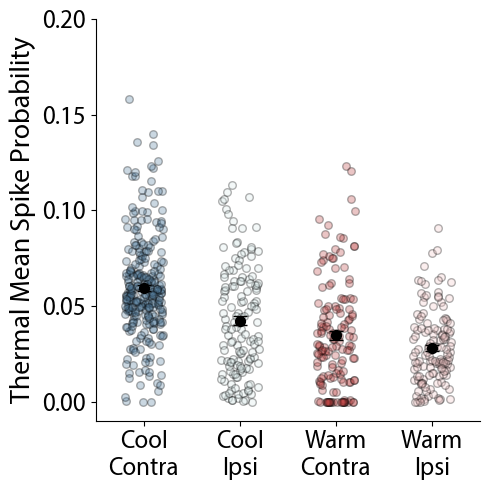

Le fichier a été sauvegardé sous : U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/spyking_analysis/plot_for_fig/Plot_svg_illustrator\Plot_Fig_4_WT_vs_ML2_Thq\df_anova_sdf_ML2_cool_warm_cont_ipsi_cluster.xlsx

Moyenne, SEM et nombre de points pour chaque groupe :
Groupe: Cool_Cont, Mean: 0.059443 ± SEM: 0.001607, n: 270
Groupe: Warm_Cont, Mean: 0.034591 ± SEM: 0.002350, n: 143
Groupe: Cool_Ipsi, Mean: 0.042333 ± SEM: 0.002427, n: 141
Groupe: Warm_Ipsi, Mean: 0.028066 ± SEM: 0.001615, n: 137

 ⚠️ Voir Stat sur Graphpad avec Mixed-effects Model (REML) with Bonferroni multiple comparisons test ⚠️


In [5]:
# Charger les fichiers
ML2_cool_cont_path = "U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/spyking_analysis/mean_sdf_period_cluster/split_files/Thq-cool_Wcont_ML2_grouped.xlsx"
df_ML2_cool_cont = pd.read_excel(ML2_cool_cont_path)

ML2_warm_cont_path = "U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/spyking_analysis/mean_sdf_period_cluster/split_files/Thq-hot_Wcont_ML2_grouped.xlsx"
df_ML2_warm_cont = pd.read_excel(ML2_warm_cont_path)

ML2_cool_ipsi_path = "U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/spyking_analysis/mean_sdf_period_cluster/split_files/Thq-cool_Wipsi_ML2_grouped.xlsx"
df_ML2_cool_ipsi = pd.read_excel(ML2_cool_ipsi_path)

ML2_warm_ipsi_path = "U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/spyking_analysis/mean_sdf_period_cluster/split_files/Thq-hot_Wipsi_ML2_grouped.xlsx"
df_ML2_warm_ipsi = pd.read_excel(ML2_warm_ipsi_path)


# Filtrer pour obtenir uniquement les données où la période est 'Stim'
df_ML2_cool_cont_ts = df_ML2_cool_cont[df_ML2_cool_cont['period'] == 'Stim']
df_ML2_warm_cont_ts = df_ML2_warm_cont[df_ML2_warm_cont['period'] == 'Stim']
df_ML2_cool_ipsi_ts = df_ML2_cool_ipsi[df_ML2_cool_ipsi['period'] == 'Stim']
df_ML2_warm_ipsi_ts = df_ML2_warm_ipsi[df_ML2_warm_ipsi['period'] == 'Stim']


# Trouver les 'directory' communs à toutes les conditions
common_directories = set.intersection(
    *(set(df['directory']) for df in [df_ML2_cool_cont_ts, df_ML2_warm_cont_ts, df_ML2_cool_ipsi_ts, df_ML2_warm_ipsi_ts])
)

print("Directories communs à toutes les conditions :", common_directories)

# Filtrer les DataFrames pour ne conserver que les 'directory' communs
df_ML2_cool_cont_ts_filtered = df_ML2_cool_cont_ts[df_ML2_cool_cont_ts['directory'].isin(common_directories)]
df_ML2_warm_cont_ts_filtered = df_ML2_warm_cont_ts[df_ML2_warm_cont_ts['directory'].isin(common_directories)]
df_ML2_cool_ipsi_ts_filtered = df_ML2_cool_ipsi_ts[df_ML2_cool_ipsi_ts['directory'].isin(common_directories)]
df_ML2_warm_ipsi_ts_filtered = df_ML2_warm_ipsi_ts[df_ML2_warm_ipsi_ts['directory'].isin(common_directories)]


# Regrouper par neurone unique et période pour s'assurer d'une entrée unique
df_ML2_cool_cont_ts_filtered_cluster = df_ML2_cool_cont_ts_filtered.groupby(['directory', 'file_name', 'neuron_id', 'period'], as_index=False, observed=True).mean(numeric_only=True)
df_ML2_warm_cont_ts_filtered_cluster = df_ML2_warm_cont_ts_filtered.groupby(['directory', 'file_name', 'neuron_id', 'period'], as_index=False, observed=True).mean(numeric_only=True)
df_ML2_cool_ipsi_ts_filtered_cluster = df_ML2_cool_ipsi_ts_filtered.groupby(['directory', 'file_name', 'neuron_id', 'period'], as_index=False, observed=True).mean(numeric_only=True)
df_ML2_warm_ipsi_ts_filtered_cluster = df_ML2_warm_ipsi_ts_filtered.groupby(['directory', 'file_name', 'neuron_id', 'period'], as_index=False, observed=True).mean(numeric_only=True)


# Ajouter une colonne pour différencier les groupes
df_ML2_cool_cont_ts_filtered_cluster['group'] = 'Cool_Cont'
df_ML2_warm_cont_ts_filtered_cluster['group'] = 'Warm_Cont' 
df_ML2_cool_ipsi_ts_filtered_cluster['group'] = 'Cool_Ipsi' 
df_ML2_warm_ipsi_ts_filtered_cluster['group'] = 'Warm_Ipsi' 


# Fusionner pour le tracé
df_combined_cluster = pd.concat([df_ML2_cool_cont_ts_filtered_cluster, df_ML2_warm_cont_ts_filtered_cluster, df_ML2_cool_ipsi_ts_filtered_cluster, 
                             df_ML2_warm_ipsi_ts_filtered_cluster])

# Couleurs
colors = {'Cool_Cont': '#507b9c', 'Cool_Ipsi': '#D9EAEA', 
          'Warm_Cont': '#bb3f3f', 'Warm_Ipsi': '#F2C7C7'}
border_colors = 'k'

# Création du plot
plt.figure(figsize=(5, 5))

# Ajouter les points individuels avec léger jitter
group_mapping = {'Cool_Cont': 0, 'Cool_Ipsi': 1, 'Warm_Cont': 2, 'Warm_Ipsi': 3}
for group in ['Cool_Cont', 'Cool_Ipsi', 'Warm_Cont', 'Warm_Ipsi']:
    subset = df_combined_cluster[df_combined_cluster['group'] == group]
    x_vals = np.ones(len(subset)) * group_mapping[group]
    x_vals += np.random.uniform(-0.2, 0.2, size=len(subset))  # jitter horizontal
    plt.scatter(x_vals, subset['sdf'], color=colors[group], edgecolor=border_colors, linewidth=1, alpha=0.3, s=30, zorder=6)

# Calcul des moyennes et SEM
mean_sdf_cluster = df_combined_cluster.groupby('group')['sdf'].mean()
sem_sdf_cluster = df_combined_cluster.groupby('group')['sdf'].sem()


# Ajouter les moyennes avec barres d'erreur
plt.scatter(mean_sdf_cluster.index, mean_sdf_cluster.values, color='black', s=50, label='Mean', zorder=10)
plt.errorbar(mean_sdf_cluster.index, mean_sdf_cluster.values, yerr=sem_sdf_cluster.values, fmt='o', color='black', capsize=5, zorder=8)

# Paramètres des axes
plt.xlabel("")
plt.ylabel("Thermal Mean Spike Probability")
plt.xticks(range(4), ['Cool\nContra', 'Cool\nIpsi', 'Warm\nContra', 'Warm\nIpsi'])
plt.xlim(-0.5, 3.5)
plt.ylim(-0.01, 0.20)

# Suppression des bordures superflues
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Afficher le plot
plt.tight_layout()


# Sauvegarder la figure
plt.savefig(os.path.join(saving_dir, '4G_BIS_ML2_SDF_cool_warm_cont_ipsi_cluster.png'), format='png', dpi=300)
plt.savefig(os.path.join(saving_dir, '4G_BIS_ML2_SDF_cool_warm_cont_ipsi_cluster.svg'), format='svg', dpi=300)



plt.show()


file_name = "df_anova_sdf_ML2_cool_warm_cont_ipsi_cluster.xlsx"

anova_path = os.path.join(saving_dir,file_name)

# Sauvegarder le DataFrame `df_combined` dans le fichier Excel
df_combined_cluster.to_excel(anova_path , index=False)

print(f"Le fichier a été sauvegardé sous : {anova_path}")




############################ Metrics ############################

# Afficher les résultats avec le nombre de points pour chaque groupe
print("\nMoyenne, SEM et nombre de points pour chaque groupe :")
for group in ['Cool_Cont', 'Warm_Cont', 'Cool_Ipsi', 'Warm_Ipsi']:
    # Calcul de la moyenne et de l'écart-type
    mean = mean_sdf_cluster[group]
    sem = sem_sdf_cluster[group]
    # Calcul du nombre de points dans chaque groupe
    n_points = len(df_combined_cluster[df_combined_cluster['group'] == group])
    # Affichage du groupe, de la moyenne, de l'écart-type et du nombre de points
    print(f"Groupe: {group}, Mean: {mean:.6f} ± SEM: {sem:.6f}, n: {n_points}")


print (f'\n ⚠️ Voir Stat sur Graphpad avec Mixed-effects Model (REML) with Bonferroni multiple comparisons test ⚠️')


#

### Fig 4.H - SDF_mean Thermic cool contra ML2

Friedman test results:
          Source     W  ddof1    Q     p-unc
Friedman  period  0.48      2  4.8  0.090718
Effet global de period: Non significatif (p-unc = 0.0907)


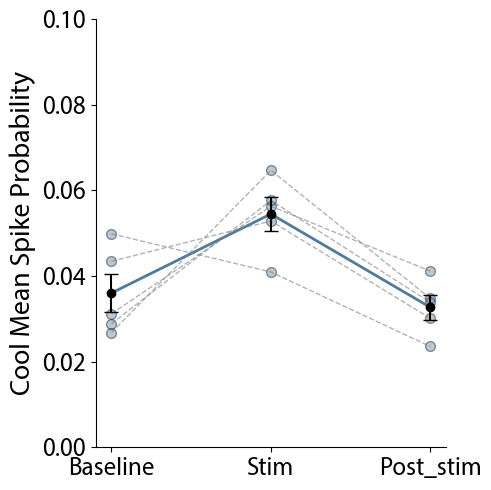

Le fichier a été sauvegardé sous : U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/spyking_analysis/plot_for_fig/Plot_svg_illustrator\Plot_Fig_4_WT_vs_ML2_Thq\df_friedman_sdf_ML2_cool_cont.xlsx
      period  mean_sdf   sem_sdf  N_animal
0   Baseline  0.036015  0.004505         5
1       Stim  0.054471  0.003897         5
2  Post_stim  0.032680  0.002893         5

       period  n_cluster
0   Baseline        289
1  Post_stim        289
2       Stim        289


In [4]:
# Charger le fichier
file_path = "U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/spyking_analysis/mean_sdf_period_cluster/split_files/Thq-cool_Wcont_ML2_grouped.xlsx"
df = pd.read_excel(file_path)

# Définir l'ordre des périodes
period_order = ['Baseline', 'Stim', 'Post_stim']

# Calculer la moyenne de 'sdf' en groupant par 'directory' et 'period'
df_grouped = df.groupby(['directory', 'period'])['sdf'].mean().reset_index()

# Assurez-vous que les périodes sont dans l'ordre souhaité
df_grouped['period'] = pd.Categorical(df_grouped['period'], categories=period_order, ordered=True)

# Trier les données par période
df_grouped = df_grouped.sort_values('period')

# Calculer la moyenne et SEM pour chaque 'period'
mean_sdf = df_grouped.groupby('period', observed=False)['sdf'].mean()
sem_sdf = df_grouped.groupby('period', observed=False)['sdf'].sem()

# Test de Friedman
friedman_results = pg.friedman(data=df_grouped, dv='sdf', within='period', subject='directory')
print("Friedman test results:")
print(friedman_results)

# Vérifier la significativité
effect_significance = "Significatif" if friedman_results['p-unc'].iloc[0] < 0.05 else "Non significatif"
print(f"Effet global de period: {effect_significance} (p-unc = {friedman_results['p-unc'].iloc[0]:.4f})")


# Test de Dunn post-hoc avec correction de Bonferroni
if friedman_results['p-unc'].iloc[0] < 0.05 :
    posthoc_results = sp.posthoc_dunn(df_grouped, val_col='sdf', group_col='period', p_adjust='bonferroni')
    posthoc_results.index = period_order
    posthoc_results.columns = period_order
    print("\nPost-hoc Dunn test with Bonferroni correction:")
    print(posthoc_results)

# Créer le plot
plt.figure(figsize=(5, 5))
colors = '#507b9c'
border_colors = 'k'

# Ajouter les points individuels
plt.scatter(df_grouped['period'], df_grouped['sdf'], color=colors, edgecolor=border_colors, linewidth=1, alpha=0.4, marker='o', s=50, zorder=1)

# Ajouter les lignes de connexion entre périodes
for directory in df_grouped['directory'].unique():
    subset = df_grouped[df_grouped['directory'] == directory]
    plt.plot(subset['period'], subset['sdf'], color='grey', linestyle='--', alpha=0.6, lw=1)

# Ajouter les points de la moyenne
plt.scatter(mean_sdf.index, mean_sdf.values, color='black', s=20, label='Mean', zorder=10)
plt.errorbar(mean_sdf.index, mean_sdf.values, yerr=sem_sdf.values, fmt='o', color='black', capsize=5, zorder=2)
plt.plot(mean_sdf.index, mean_sdf.values, color=colors, linestyle='-', linewidth=2, zorder=1)

# Ajouter les barres de significativité
def add_sig_bar(x1, x2, y, p_val, height_offset=0.002, fontsize=18):
    significance = ""
    if p_val < 0.001:
        significance = "***"
    elif p_val < 0.01:
        significance = "**"
    elif p_val < 0.05:
        significance = "*"
    
    if significance:
        plt.plot([x1, x1, x2, x2], [y, y + height_offset, y + height_offset, y], lw=1, color='black')
        plt.text((x1 + x2) * 0.5, y + height_offset, significance, ha='center', va='bottom', color='black', fontsize=fontsize)

positions = {'Baseline': 0, 'Stim': 1, 'Post_stim': 2}
y_offset = 0.085  # Décalage vertical initial
spacing_between_bars = 0.01

if friedman_results['p-unc'].iloc[0] < 0.05 :
    for i, p1 in enumerate(period_order):
        for j, p2 in enumerate(period_order):
            if i < j:
                p_val = posthoc_results.loc[p1, p2]
                if p_val < 0.05:
                    add_sig_bar(positions[p1], positions[p2], y_offset, p_val)
                    y_offset += spacing_between_bars

plt.xlabel("")
plt.ylabel("Cool Mean Spike Probability")
plt.xticks(ticks=np.arange(len(period_order)), labels=period_order)
plt.ylim(0,0.1)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()

# Sauvegarder la figure
plt.savefig(os.path.join(saving_dir, '4H_SDF_ML2_Cool_contra_period.png'), format='png', dpi=300)
plt.savefig(os.path.join(saving_dir, '4H_SDF_ML2_Cool_contra_period.svg'), format='svg', dpi=300)

plt.show()



file_name = "df_friedman_sdf_ML2_cool_cont.xlsx"

anova_path = os.path.join(saving_dir,file_name)

# Sauvegarder le DataFrame `df_combined` dans le fichier Excel
df_grouped.to_excel(anova_path , index=False)

print(f"Le fichier a été sauvegardé sous : {anova_path}")




############################    Metrics   ############################ 

summary_table = df_grouped.groupby('period', observed=False).agg(
    mean_sdf=('sdf', 'mean'),
    sem_sdf=('sdf', 'sem'),
    N_animal=('sdf', 'size'),
).reset_index()
print(summary_table)

summary_table2 = df.groupby('period', observed=False).agg(
    n_cluster=('sdf', 'size')
).reset_index()
print("\n", summary_table2)


#### Filtrage des données avec seulement les animaux qui reponsent en cool

Friedman test results:
          Source       W  ddof1    Q     p-unc
Friedman  period  0.4375      2  3.5  0.173774
Effet global de period: Non significatif (p-unc = 0.1738)


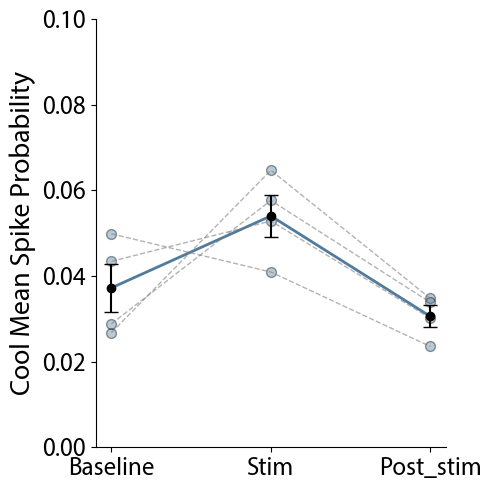

      period  mean_sdf   sem_sdf  N_animal
0   Baseline  0.037225  0.005602         4
1       Stim  0.054016  0.004996         4
2  Post_stim  0.030565  0.002548         4

       period  n_cluster
0   Baseline        230
1  Post_stim        230
2       Stim        230


In [5]:
# Charger le fichier
file_path = "U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/spyking_analysis/mean_sdf_period_cluster/split_files_filtered_shank_thq_cool/Thq-cool_Wcont_ML2_sdf_mean_period_filtered.xlsx"
df = pd.read_excel(file_path)

# Définir l'ordre des périodes
period_order = ['Baseline', 'Stim', 'Post_stim']

# Calculer la moyenne de 'sdf' en groupant par 'directory' et 'period'
df_grouped = df.groupby(['directory', 'period'])['sdf'].mean().reset_index()

# Assurez-vous que les périodes sont dans l'ordre souhaité
df_grouped['period'] = pd.Categorical(df_grouped['period'], categories=period_order, ordered=True)

# Trier les données par période
df_grouped = df_grouped.sort_values('period')

# Calculer la moyenne et SEM pour chaque 'period'
mean_sdf = df_grouped.groupby('period', observed=False)['sdf'].mean()
sem_sdf = df_grouped.groupby('period', observed=False)['sdf'].sem()

# Test de Friedman
friedman_results = pg.friedman(data=df_grouped, dv='sdf', within='period', subject='directory')
print("Friedman test results:")
print(friedman_results)

# Vérifier la significativité
effect_significance = "Significatif" if friedman_results['p-unc'].iloc[0] < 0.05 else "Non significatif"
print(f"Effet global de period: {effect_significance} (p-unc = {friedman_results['p-unc'].iloc[0]:.4f})")


# Test de Dunn post-hoc avec correction de Bonferroni
if friedman_results['p-unc'].iloc[0] < 0.05 :
    posthoc_results = sp.posthoc_dunn(df_grouped, val_col='sdf', group_col='period', p_adjust='bonferroni')
    posthoc_results.index = period_order
    posthoc_results.columns = period_order
    print("\nPost-hoc Dunn test with Bonferroni correction:")
    print(posthoc_results)

# Créer le plot
plt.figure(figsize=(5, 5))
colors = '#507b9c'
border_colors = 'k'

# Ajouter les points individuels
plt.scatter(df_grouped['period'], df_grouped['sdf'], color=colors, edgecolor=border_colors, linewidth=1, alpha=0.4, marker='o', s=50, zorder=1)

# Ajouter les lignes de connexion entre périodes
for directory in df_grouped['directory'].unique():
    subset = df_grouped[df_grouped['directory'] == directory]
    plt.plot(subset['period'], subset['sdf'], color='grey', linestyle='--', alpha=0.6, lw=1)

# Ajouter les points de la moyenne
plt.scatter(mean_sdf.index, mean_sdf.values, color='black', s=20, label='Mean', zorder=10)
plt.errorbar(mean_sdf.index, mean_sdf.values, yerr=sem_sdf.values, fmt='o', color='black', capsize=5, zorder=2)
plt.plot(mean_sdf.index, mean_sdf.values, color=colors, linestyle='-', linewidth=2, zorder=1)

# Ajouter les barres de significativité
def add_sig_bar(x1, x2, y, p_val, height_offset=0.002, fontsize=18):
    significance = ""
    if p_val < 0.001:
        significance = "***"
    elif p_val < 0.01:
        significance = "**"
    elif p_val < 0.05:
        significance = "*"
    
    if significance:
        plt.plot([x1, x1, x2, x2], [y, y + height_offset, y + height_offset, y], lw=1, color='black')
        plt.text((x1 + x2) * 0.5, y + height_offset, significance, ha='center', va='bottom', color='black', fontsize=fontsize)

positions = {'Baseline': 0, 'Stim': 1, 'Post_stim': 2}
y_offset = 0.085  # Décalage vertical initial
spacing_between_bars = 0.01

if friedman_results['p-unc'].iloc[0] < 0.05 :
    for i, p1 in enumerate(period_order):
        for j, p2 in enumerate(period_order):
            if i < j:
                p_val = posthoc_results.loc[p1, p2]
                if p_val < 0.05:
                    add_sig_bar(positions[p1], positions[p2], y_offset, p_val)
                    y_offset += spacing_between_bars

plt.xlabel("")
plt.ylabel("Cool Mean Spike Probability")
plt.xticks(ticks=np.arange(len(period_order)), labels=period_order)
plt.ylim(0,0.1)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()

# # Sauvegarder la figure
# plt.savefig(os.path.join(saving_dir, '4Hbis_SDF_ML2_Cool_contra_period.png'), format='png', dpi=300)
# plt.savefig(os.path.join(saving_dir, '4Hbis_SDF_ML2_Cool_contra_period.svg'), format='svg', dpi=300)

plt.show()



# file_name = "df_friedman_sdf_ML2_cool_cont.xlsx"

# anova_path = os.path.join(saving_dir,file_name)

# # Sauvegarder le DataFrame `df_combined` dans le fichier Excel
# df_grouped.to_excel(anova_path , index=False)

# print(f"Le fichier a été sauvegardé sous : {anova_path}")




############################    Metrics   ############################ 

summary_table = df_grouped.groupby('period', observed=False).agg(
    mean_sdf=('sdf', 'mean'),
    sem_sdf=('sdf', 'sem'),
    N_animal=('sdf', 'size'),
).reset_index()
print(summary_table)

summary_table2 = df.groupby('period', observed=False).agg(
    n_cluster=('sdf', 'size')
).reset_index()
print("\n", summary_table2)


### Fig 4.H_BIS - Cluster - SDF_mean Thermic cool contra ML2

Period Baseline: p = 0.0613 (Normal)
Period Stim: p = 0.0000 (Non normal)
Period Post_stim: p = 0.0200 (Non normal)

📊 Résultats du test de Friedman :
          Source         W  ddof1           Q         p-unc
Friedman  period  0.313011      2  180.920415  5.171672e-40

Effet global de 'period' : Significatif (p = 0.0000)

🧪 Post-hoc Dunn avec correction Bonferroni :
               Baseline          Stim     Post_stim
Baseline   1.000000e+00  7.040992e-48  8.338214e-02
Stim       7.040992e-48  1.000000e+00  6.744549e-35
Post_stim  8.338214e-02  6.744549e-35  1.000000e+00


c:\Users\zayan\Anaconda\envs\analysis\lib\site-packages\scikit_posthocs\_posthocs.py:371: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  x_lens = x.groupby(_group_col)[_val_col].count()
c:\Users\zayan\Anaconda\envs\analysis\lib\site-packages\scikit_posthocs\_posthocs.py:374: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  x_ranks_avg = x.groupby(_group_col)["ranks"].mean()


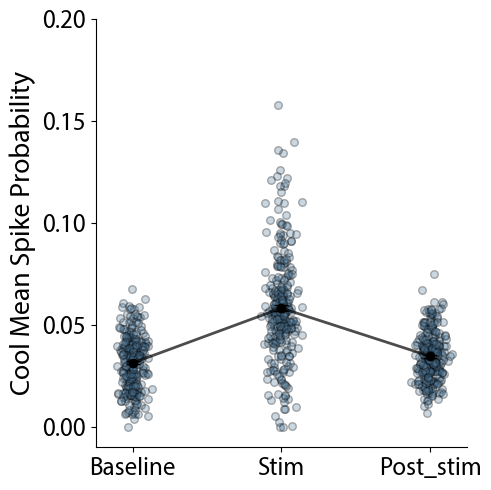


📈 Tableau récapitulatif par période :
      period  mean_sdf   sem_sdf  N_neuron_unique
0   Baseline  0.031360  0.000771              289
1       Stim  0.058225  0.001546              289
2  Post_stim  0.034621  0.000668              289


In [6]:
from scipy.stats import shapiro


#  Charger le fichier Excel
file_path = "U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/spyking_analysis/mean_sdf_period_cluster/split_files/Thq-cool_Wcont_ML2_grouped.xlsx"
df = pd.read_excel(file_path)

# Définir l'ordre des périodes
period_order = ['Baseline', 'Stim', 'Post_stim']
df['period'] = pd.Categorical(df['period'], categories=period_order, ordered=True)

# Regrouper par neurone unique et période pour s'assurer d'une entrée unique
df_unique = df.groupby(['directory', 'file_name', 'neuron_id', 'period'], as_index=False, observed=True).mean(numeric_only=True)

# Calculer la moyenne et SEM globales par période
mean_sem = df_unique.groupby('period', observed=True)['sdf'].agg(['mean', 'sem']).reindex(period_order)

# 1. Nettoyage des données
df_unique_clean = df_unique.dropna(subset=['sdf'])

# 2. Créer une colonne 'subject' pour identifier chaque neurone
df_unique_clean['subject'] = df_unique_clean['directory'] + '_' + df_unique_clean['file_name'] + '_' + df_unique_clean['neuron_id'].astype(str)


for period in df_unique_clean['period'].unique():
    subset = df_unique_clean[df_unique_clean['period'] == period]
    stat, p = shapiro(subset['sdf'])
    print(f"Period {period}: p = {p:.4f} ({'Non normal' if p < 0.05 else 'Normal'})")


# ---------- 📊 TEST DE FRIEDMAN ----------
# # 1. Nettoyage des données
# df_unique_clean = df_unique.dropna(subset=['sdf'])

# # 2. Créer une colonne 'subject' pour identifier chaque neurone
# df_unique_clean['subject'] = df_unique_clean['directory'] + '_' + df_unique_clean['file_name'] + '_' + df_unique_clean['neuron_id'].astype(str)

# 3. S'assurer que les périodes sont bien catégorisées et ordonnées
period_order = ['Baseline', 'Stim', 'Post_stim']
df_unique_clean['period'] = pd.Categorical(df_unique_clean['period'], categories=period_order, ordered=True)

# 4. Garder seulement les sujets ayant des valeurs pour toutes les périodes (Friedman exige mesures répétées complètes)
complete_subjects = df_unique_clean.groupby('subject')['period'].nunique() == len(period_order)
df_friedman_cool_cluster = df_unique_clean[df_unique_clean['subject'].isin(complete_subjects[complete_subjects].index)]

# 5. Appliquer le test de Friedman (format long)
friedman_results_cool_cluster = pg.friedman(data=df_friedman_cool_cluster, dv='sdf', within='period', subject='subject')
print("\n📊 Résultats du test de Friedman :")
print(friedman_results_cool_cluster)

# 6. Vérifier significativité
pval_cool_cluster = friedman_results_cool_cluster['p-unc'].iloc[0]
effect_significance = "Significatif" if pval_cool_cluster < 0.05 else "Non significatif"
print(f"\nEffet global de 'period' : {effect_significance} (p = {pval_cool_cluster:.4f})")

# 7. Si significatif, faire un post-hoc de Dunn
if pval_cool_cluster < 0.05:
    print("\n🧪 Post-hoc Dunn avec correction Bonferroni :")
    posthoc_results_cool_cluster = sp.posthoc_dunn(df_friedman_cool_cluster, val_col='sdf', group_col='period', p_adjust='bonferroni')
    posthoc_results_cool_cluster = posthoc_results_cool_cluster.loc[period_order, period_order]
    print(posthoc_results_cool_cluster)


# Créer le plot
plt.figure(figsize=(5, 5))
colors = '#507b9c'
border_colors = 'k'

# Appliquer un jitter sur l'axe x
x_jitter = df_unique['period'].cat.codes + np.random.normal(0, 0.05, size=len(df_unique))

# Puis plot avec jitter
plt.scatter(x_jitter, df_unique['sdf'],
            color=colors, edgecolor=border_colors,
            linewidth=1, alpha=0.3, marker='o', s=30, zorder=0)

# Ajouter les moyennes ± SEM
plt.errorbar(mean_sem.index, mean_sem['mean'], yerr=mean_sem['sem'],
             fmt='o', color='black', capsize=5, label='Mean ± SEM', zorder=2)
plt.plot(mean_sem.index, mean_sem['mean'],
         color='k', alpha=0.7, linestyle='-', linewidth=2, zorder=1)

# # Ajouter les barres de significativité
# def add_sig_bar(x1, x2, y, p_val, height_offset=0.002, fontsize=18):
#     significance = ""
#     if p_val < 0.001:
#         significance = "***"
#     elif p_val < 0.01:
#         significance = "**"
#     elif p_val < 0.05:
#         significance = "*"
    
#     if significance:
#         plt.plot([x1, x1, x2, x2], [y, y + height_offset, y + height_offset, y], lw=1, color='black')
#         plt.text((x1 + x2) * 0.5, y , significance, ha='center', va='bottom', color='black', fontsize=fontsize)

# positions = {'Baseline': 0, 'Stim': 1, 'Post_stim': 2}
# y_offset = 0.17  # Décalage vertical initial
# spacing_between_bars = 0.01

# if friedman_results_cool_cluster['p-unc'].iloc[0] < 0.05 :
#     for i, p1 in enumerate(period_order):
#         for j, p2 in enumerate(period_order):
#             if i < j:
#                 p_val = posthoc_results_cool_cluster.loc[p1, p2]
#                 if p_val < 0.05:
#                     add_sig_bar(positions[p1], positions[p2], y_offset, p_val)
#                     y_offset += spacing_between_bars



plt.xlabel("")
plt.ylabel("Cool Mean Spike Probability")
plt.xticks(ticks=np.arange(len(period_order)), labels=period_order)
plt.ylim(-0.01,0.2)
plt.xlim(-0.25, len(period_order) - 0.75)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()


# Sauvegarder la figure
plt.savefig(os.path.join(saving_dir, '4H_BIS_SDF_ML2_Cool_contra_period_cluster.png'), format='png', dpi=300)
plt.savefig(os.path.join(saving_dir, '4H_BIS_SDF_ML2_Cool_contra_period_cluster.svg'), format='svg', dpi=300)


plt.show()


############################    📊 Résumé par période   ############################

summary_table = df_friedman_cool_cluster.groupby('period', observed=True).agg(
    mean_sdf=('sdf', 'mean'),
    sem_sdf=('sdf', 'sem'),
    N_neuron_unique=('subject', 'nunique')
).reset_index()

print("\n📈 Tableau récapitulatif par période :")
print(summary_table)


#

### Fig 4.I - SDF_mean Thermic Warm contra ML2

Friedman test results:
          Source     W  ddof1    Q     p-unc
Friedman  period  0.12      2  1.2  0.548812
Effet global de period: Non significatif (p-unc = 0.5488)


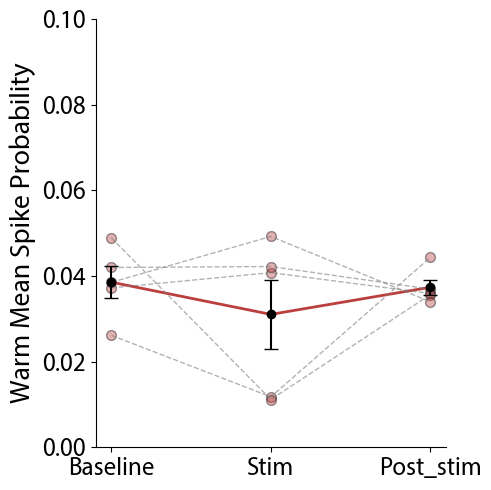

      period  mean_sdf   sem_sdf  N_animal
0   Baseline  0.038547  0.003705         5
1       Stim  0.031028  0.008114         5
2  Post_stim  0.037360  0.001802         5

       period  n_cluster
0   Baseline        170
1  Post_stim        170
2       Stim        170


In [7]:
# Charger le fichier
file_path = "U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/spyking_analysis/mean_sdf_period_cluster/split_files/Thq-hot_Wcont_ML2_grouped.xlsx"
df = pd.read_excel(file_path)

# Définir l'ordre des périodes
period_order = ['Baseline', 'Stim', 'Post_stim']

# Calculer la moyenne de 'sdf' en groupant par 'directory' et 'period'
df_grouped = df.groupby(['directory', 'period'])['sdf'].mean().reset_index()

# Assurez-vous que les périodes sont dans l'ordre souhaité
df_grouped['period'] = pd.Categorical(df_grouped['period'], categories=period_order, ordered=True)

# Trier les données par période
df_grouped = df_grouped.sort_values('period')

# Calculer la moyenne et SEM pour chaque 'period'
mean_sdf = df_grouped.groupby('period', observed=False)['sdf'].mean()
sem_sdf = df_grouped.groupby('period', observed=False)['sdf'].sem()

# Test de Friedman
friedman_results = pg.friedman(data=df_grouped, dv='sdf', within='period', subject='directory')
print("Friedman test results:")
print(friedman_results)

# Vérifier la significativité
effect_significance = "Significatif" if friedman_results['p-unc'].iloc[0] < 0.05 else "Non significatif"
print(f"Effet global de period: {effect_significance} (p-unc = {friedman_results['p-unc'].iloc[0]:.4f})")


# Test de Dunn post-hoc avec correction de Bonferroni
if friedman_results['p-unc'].iloc[0] < 0.05 :
    posthoc_results = sp.posthoc_dunn(df_grouped, val_col='sdf', group_col='period', p_adjust='bonferroni')
    posthoc_results.index = period_order
    posthoc_results.columns = period_order
    print("\nPost-hoc Dunn test with Bonferroni correction:")
    print(posthoc_results)

# Créer le plot
plt.figure(figsize=(5, 5))
colors = '#bb3f3f'
border_colors = 'k'

# Ajouter les points individuels
plt.scatter(df_grouped['period'], df_grouped['sdf'], color=colors, edgecolor=border_colors, linewidth=1, alpha=0.4, marker='o', s=50, zorder=1)

# Ajouter les lignes de connexion entre périodes
for directory in df_grouped['directory'].unique():
    subset = df_grouped[df_grouped['directory'] == directory]
    plt.plot(subset['period'], subset['sdf'], color='grey', linestyle='--', alpha=0.6, lw=1)

# Ajouter les points de la moyenne
plt.scatter(mean_sdf.index, mean_sdf.values, color='black', s=20, label='Mean', zorder=10)
plt.errorbar(mean_sdf.index, mean_sdf.values, yerr=sem_sdf.values, fmt='o', color='black', capsize=5, zorder=2)
plt.plot(mean_sdf.index, mean_sdf.values, color=colors, linestyle='-', linewidth=2, zorder=1)

# Ajouter les barres de significativité
def add_sig_bar(x1, x2, y, p_val, height_offset=0.005, fontsize=16):
    significance = ""
    if p_val < 0.001:
        significance = "***"
    elif p_val < 0.01:
        significance = "**"
    elif p_val < 0.05:
        significance = "*"
    
    if significance:
        plt.plot([x1, x1, x2, x2], [y, y + height_offset, y + height_offset, y], lw=1, color='black')
        plt.text((x1 + x2) * 0.5, y + height_offset, significance, ha='center', va='bottom', color='black', fontsize=fontsize)

positions = {'Baseline': 0, 'Stim': 1, 'Post_stim': 2}
y_offset = 0.09 # Décalage vertical initial
spacing_between_bars = 0.01

if friedman_results['p-unc'].iloc[0] < 0.05 :
    for i, p1 in enumerate(period_order):
        for j, p2 in enumerate(period_order):
            if i < j:
                p_val = posthoc_results.loc[p1, p2]
                if p_val < 0.05:
                    add_sig_bar(positions[p1], positions[p2], y_offset, p_val)
                    y_offset += spacing_between_bars

plt.xlabel("")
plt.ylabel("Warm Mean Spike Probability")
plt.xticks(ticks=np.arange(len(period_order)), labels=period_order)
plt.ylim(0,0.1)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()

# Sauvegarder la figure
plt.savefig(os.path.join(saving_dir, '4I_SDF_ML2_Warm_contra_period.png'), format='png', dpi=300)
plt.savefig(os.path.join(saving_dir, '4I_SDF_ML2_Warm_contra_period.svg'), format='svg', dpi=300)

plt.show()


############################    Metrics   ############################ 

summary_table = df_grouped.groupby('period', observed=False).agg(
    mean_sdf=('sdf', 'mean'),
    sem_sdf=('sdf', 'sem'),
    N_animal=('sdf', 'size'),
).reset_index()
print(summary_table)

summary_table2 = df.groupby('period', observed=False).agg(
    n_cluster=('sdf', 'size')
).reset_index()
print("\n", summary_table2)


#### Filtrage des données avec seulement les animaux qui reponsent en warm

In [73]:
# # Charger le fichier
# file_path = "U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/spyking_analysis/mean_sdf_period_cluster/split_files_filtered_shank_thq_hot/Thq-hot_Wcont_ML2_sdf_mean_period_warm_animal_filtered.xlsx"
# df = pd.read_excel(file_path)

# # Définir l'ordre des périodes
# period_order = ['Baseline', 'Stim', 'Post_stim']

# # Calculer la moyenne de 'sdf' en groupant par 'directory' et 'period'
# df_grouped = df.groupby(['directory', 'period'])['sdf'].mean().reset_index()

# # Assurez-vous que les périodes sont dans l'ordre souhaité
# df_grouped['period'] = pd.Categorical(df_grouped['period'], categories=period_order, ordered=True)

# # Trier les données par période
# df_grouped = df_grouped.sort_values('period')

# # Calculer la moyenne et SEM pour chaque 'period'
# mean_sdf = df_grouped.groupby('period', observed=False)['sdf'].mean()
# sem_sdf = df_grouped.groupby('period', observed=False)['sdf'].sem()

# # Test de Friedman
# friedman_results = pg.friedman(data=df_grouped, dv='sdf', within='period', subject='directory')
# print("Friedman test results:")
# print(friedman_results)

# # Vérifier la significativité
# effect_significance = "Significatif" if friedman_results['p-unc'].iloc[0] < 0.05 else "Non significatif"
# print(f"Effet global de period: {effect_significance} (p-unc = {friedman_results['p-unc'].iloc[0]:.4f})")


# # Test de Dunn post-hoc avec correction de Bonferroni
# if friedman_results['p-unc'].iloc[0] < 0.05 :
#     posthoc_results = sp.posthoc_dunn(df_grouped, val_col='sdf', group_col='period', p_adjust='bonferroni')
#     posthoc_results.index = period_order
#     posthoc_results.columns = period_order
#     print("\nPost-hoc Dunn test with Bonferroni correction:")
#     print(posthoc_results)

# # Créer le plot
# plt.figure(figsize=(5, 5))
# colors = '#bb3f3f'
# border_colors = 'k'

# # Ajouter les points individuels
# plt.scatter(df_grouped['period'], df_grouped['sdf'], color=colors, edgecolor=border_colors, linewidth=1, alpha=0.4, marker='o', s=50, zorder=1)

# # Ajouter les lignes de connexion entre périodes
# for directory in df_grouped['directory'].unique():
#     subset = df_grouped[df_grouped['directory'] == directory]
#     plt.plot(subset['period'], subset['sdf'], color='grey', linestyle='--', alpha=0.6, lw=1)

# # Ajouter les points de la moyenne
# plt.scatter(mean_sdf.index, mean_sdf.values, color='black', s=20, label='Mean', zorder=10)
# plt.errorbar(mean_sdf.index, mean_sdf.values, yerr=sem_sdf.values, fmt='o', color='black', capsize=5, zorder=2)
# plt.plot(mean_sdf.index, mean_sdf.values, color=colors, linestyle='-', linewidth=2, zorder=1)

# # Ajouter les barres de significativité
# def add_sig_bar(x1, x2, y, p_val, height_offset=0.005, fontsize=16):
#     significance = ""
#     if p_val < 0.001:
#         significance = "***"
#     elif p_val < 0.01:
#         significance = "**"
#     elif p_val < 0.05:
#         significance = "*"
    
#     if significance:
#         plt.plot([x1, x1, x2, x2], [y, y + height_offset, y + height_offset, y], lw=1, color='black')
#         plt.text((x1 + x2) * 0.5, y + height_offset, significance, ha='center', va='bottom', color='black', fontsize=fontsize)

# positions = {'Baseline': 0, 'Stim': 1, 'Post_stim': 2}
# y_offset = 0.09 # Décalage vertical initial
# spacing_between_bars = 0.01

# if friedman_results['p-unc'].iloc[0] < 0.05 :
#     for i, p1 in enumerate(period_order):
#         for j, p2 in enumerate(period_order):
#             if i < j:
#                 p_val = posthoc_results.loc[p1, p2]
#                 if p_val < 0.05:
#                     add_sig_bar(positions[p1], positions[p2], y_offset, p_val)
#                     y_offset += spacing_between_bars

# plt.xlabel("")
# plt.ylabel("Warm Mean spike probability")
# plt.xticks(ticks=np.arange(len(period_order)), labels=period_order)
# plt.ylim(0,0.1)

# ax = plt.gca()
# ax.spines['top'].set_visible(False)
# ax.spines['right'].set_visible(False)
# plt.tight_layout()

# # # Sauvegarder la figure
# # plt.savefig(os.path.join(saving_dir, '4Ibis_SDF_ML2_Warm_contra_period.png'), format='png', dpi=300)
# # plt.savefig(os.path.join(saving_dir, '4Ibis_SDF_ML2_Warm_contra_period.svg'), format='svg', dpi=300)

# plt.show()


# ############################    Metrics   ############################ 

# summary_table = df_grouped.groupby('period', observed=False).agg(
#     mean_sdf=('sdf', 'mean'),
#     sem_sdf=('sdf', 'sem'),
#     N_animal=('sdf', 'size'),
# ).reset_index()
# print(summary_table)

# summary_table2 = df.groupby('period', observed=False).agg(
#     n_cluster=('sdf', 'size')
# ).reset_index()
# print("\n", summary_table2)


### Fig 4.I_BIS - Cluster - SDF_mean Thermic Warm contra ML2

Period Baseline: p = 0.0000 (Non normal)
Period Stim: p = 0.0000 (Non normal)
Period Post_stim: p = 0.4020 (Normal)

📊 Résultats du test de Friedman :
          Source         W  ddof1          Q     p-unc
Friedman  period  0.042164      2  14.335788  0.000771

Effet global de 'period' : Significatif (p = 0.0008)

🧪 Post-hoc Dunn avec correction Bonferroni :
           Baseline      Stim  Post_stim
Baseline   1.000000  0.007225   0.194302
Stim       0.007225  1.000000   0.704792
Post_stim  0.194302  0.704792   1.000000


c:\Users\zayan\Anaconda\envs\analysis\lib\site-packages\scikit_posthocs\_posthocs.py:371: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  x_lens = x.groupby(_group_col)[_val_col].count()
c:\Users\zayan\Anaconda\envs\analysis\lib\site-packages\scikit_posthocs\_posthocs.py:374: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  x_ranks_avg = x.groupby(_group_col)["ranks"].mean()


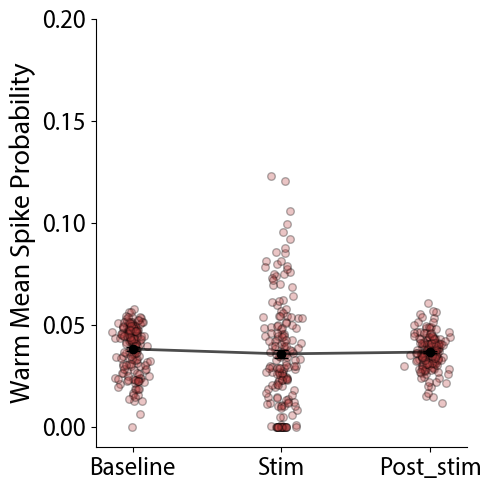


📈 Tableau récapitulatif par période :
      period  mean_sdf   sem_sdf  N_neuron_unique
0   Baseline  0.038171  0.000902              170
1       Stim  0.035800  0.002039              170
2  Post_stim  0.036700  0.000631              170


In [7]:
from scipy.stats import shapiro


#  Charger le fichier Excel
file_path = "U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/spyking_analysis/mean_sdf_period_cluster/split_files/Thq-hot_Wcont_ML2_grouped.xlsx"
df = pd.read_excel(file_path)

# Définir l'ordre des périodes
period_order = ['Baseline', 'Stim', 'Post_stim']
df['period'] = pd.Categorical(df['period'], categories=period_order, ordered=True)

# Regrouper par neurone unique et période pour s'assurer d'une entrée unique
df_unique = df.groupby(['directory', 'file_name', 'neuron_id', 'period'], as_index=False, observed=True).mean(numeric_only=True)

# Calculer la moyenne et SEM globales par période
mean_sem = df_unique.groupby('period', observed=True)['sdf'].agg(['mean', 'sem']).reindex(period_order)

# 1. Nettoyage des données
df_unique_clean = df_unique.dropna(subset=['sdf'])

# 2. Créer une colonne 'subject' pour identifier chaque neurone
df_unique_clean['subject'] = df_unique_clean['directory'] + '_' + df_unique_clean['file_name'] + '_' + df_unique_clean['neuron_id'].astype(str)


for period in df_unique_clean['period'].unique():
    subset = df_unique_clean[df_unique_clean['period'] == period]
    stat, p = shapiro(subset['sdf'])
    print(f"Period {period}: p = {p:.4f} ({'Non normal' if p < 0.05 else 'Normal'})")


# ---------- 📊 TEST DE FRIEDMAN ----------
# # 1. Nettoyage des données
# df_unique_clean = df_unique.dropna(subset=['sdf'])

# # 2. Créer une colonne 'subject' pour identifier chaque neurone
# df_unique_clean['subject'] = df_unique_clean['directory'] + '_' + df_unique_clean['file_name'] + '_' + df_unique_clean['neuron_id'].astype(str)

# 3. S'assurer que les périodes sont bien catégorisées et ordonnées
period_order = ['Baseline', 'Stim', 'Post_stim']
df_unique_clean['period'] = pd.Categorical(df_unique_clean['period'], categories=period_order, ordered=True)

# 4. Garder seulement les sujets ayant des valeurs pour toutes les périodes (Friedman exige mesures répétées complètes)
complete_subjects = df_unique_clean.groupby('subject')['period'].nunique() == len(period_order)
df_friedman_warm_cluster = df_unique_clean[df_unique_clean['subject'].isin(complete_subjects[complete_subjects].index)]

# 5. Appliquer le test de Friedman (format long)
friedman_results_warm_cluster = pg.friedman(data=df_friedman_warm_cluster, dv='sdf', within='period', subject='subject')
print("\n📊 Résultats du test de Friedman :")
print(friedman_results_warm_cluster)

# 6. Vérifier significativité
pval_warm_cluster = friedman_results_warm_cluster['p-unc'].iloc[0]
effect_significance = "Significatif" if pval_warm_cluster < 0.05 else "Non significatif"
print(f"\nEffet global de 'period' : {effect_significance} (p = {pval_warm_cluster:.4f})")

# 7. Si significatif, faire un post-hoc de Dunn
if pval_warm_cluster < 0.05:
    print("\n🧪 Post-hoc Dunn avec correction Bonferroni :")
    posthoc_results_warm_cluster = sp.posthoc_dunn(df_friedman_warm_cluster, val_col='sdf', group_col='period', p_adjust='bonferroni')
    posthoc_results_warm_cluster = posthoc_results_warm_cluster.loc[period_order, period_order]
    print(posthoc_results_warm_cluster)


# Créer le plot
plt.figure(figsize=(5, 5))
colors = '#bb3f3f'
border_colors = 'k'

# Appliquer un jitter sur l'axe x
x_jitter = df_unique['period'].cat.codes + np.random.normal(0, 0.05, size=len(df_unique))

# Puis plot avec jitter
plt.scatter(x_jitter, df_unique['sdf'],
            color=colors, edgecolor=border_colors,
            linewidth=1, alpha=0.3, marker='o', s=30, zorder=0)

# Ajouter les moyennes ± SEM
plt.errorbar(mean_sem.index, mean_sem['mean'], yerr=mean_sem['sem'],
             fmt='o', color='black', capsize=5, label='Mean ± SEM', zorder=2)
plt.plot(mean_sem.index, mean_sem['mean'],
         color='k', alpha=0.7, linestyle='-', linewidth=2, zorder=1)

# # Ajouter les barres de significativité
# def add_sig_bar(x1, x2, y, p_val, height_offset=0.002, fontsize=18):
#     significance = ""
#     if p_val < 0.001:
#         significance = "***"
#     elif p_val < 0.01:
#         significance = "**"
#     elif p_val < 0.05:
#         significance = "*"
    
#     if significance:
#         plt.plot([x1, x1, x2, x2], [y, y + height_offset, y + height_offset, y], lw=1, color='black')
#         plt.text((x1 + x2) * 0.5, y , significance, ha='center', va='bottom', color='black', fontsize=fontsize)

# positions = {'Baseline': 0, 'Stim': 1, 'Post_stim': 2}
# y_offset = 0.15  # Décalage vertical initial
# spacing_between_bars = 0.015

# if friedman_results_warm_cluster['p-unc'].iloc[0] < 0.05 :
#     for i, p1 in enumerate(period_order):
#         for j, p2 in enumerate(period_order):
#             if i < j:
#                 p_val = posthoc_results_warm_cluster.loc[p1, p2]
#                 if p_val < 0.05:
#                     add_sig_bar(positions[p1], positions[p2], y_offset, p_val)
#                     y_offset += spacing_between_bars



plt.xlabel("")
plt.ylabel("Warm Mean Spike Probability")
plt.xticks(ticks=np.arange(len(period_order)), labels=period_order)
plt.ylim(-0.01,0.2)
plt.xlim(-0.25, len(period_order) - 0.75)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()


# Sauvegarder la figure
plt.savefig(os.path.join(saving_dir, '4I_BIS_SDF_ML2_Warm_contra_period_cluster.png'), format='png', dpi=300)
plt.savefig(os.path.join(saving_dir, '4I_BIS_SDF_ML2_Warm_contra_period_cluster.svg'), format='svg', dpi=300)


plt.show()


############################    📊 Résumé par période   ############################

summary_table = df_friedman_warm_cluster.groupby('period', observed=True).agg(
    mean_sdf=('sdf', 'mean'),
    sem_sdf=('sdf', 'sem'),
    N_neuron_unique=('subject', 'nunique')
).reset_index()

print("\n📈 Tableau récapitulatif par période :")
print(summary_table)


#

### Fig 4.J - ML2 vs WT Cool contra response rate

n (WT_Cont) = 10
n (ML2_cont) = 5
Wilcoxon test result: statistic = 18.0000, p-value = 0.4175


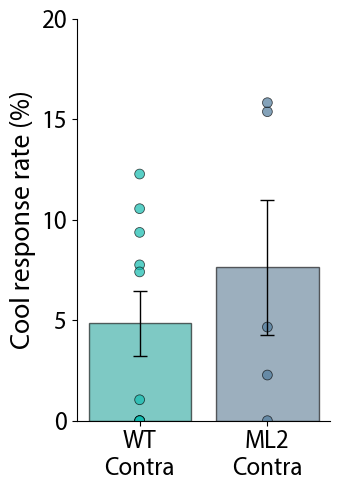


WT_tac_cont : mean = 4.84 ± 1.60
ML2_tac_cont : mean = 7.63 ± 3.34

 contra: n_cluster : 504
ipsi: n_cluster : 289


In [83]:
# Charger les fichiers
WT_tac_cont_path = "U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/spyking_analysis/cluster_response_rate/Thq-cool_Wcont_WT_resp_rate.xlsx"
df_WT_tac_cont = pd.read_excel(WT_tac_cont_path)

ML2_tac_cont_path = "U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/spyking_analysis/cluster_response_rate/Thq-cool_Wcont_ML2_resp_rate.xlsx"
df_ML2_tac_cont = pd.read_excel(ML2_tac_cont_path)

# Calcul du pourcentage de '1' dans la colonne 'response' pour chaque combinaison de 'directory' et 'file_name'
def calculate_response_percentage(df):
    # Grouper par 'directory' et 'file_name' et calculer le pourcentage de 1 dans la colonne 'response'
    response_percentage = df.groupby(['directory', 'file_name'])['response'].agg(
        lambda x: (x.sum() / len(x)) * 100
    ).reset_index()
    
    # Renommer la colonne pour plus de clarté
    response_percentage.rename(columns={'response': 'response_percentage'}, inplace=True)
    
    return response_percentage

# Appliquer la fonction sur chaque DataFrame
response_percentage_WT_tac_cont = calculate_response_percentage(df_WT_tac_cont)
response_percentage_ML2_tac_cont = calculate_response_percentage(df_ML2_tac_cont)


# Calculer la moyenne des pourcentages de réponse pour chaque 'directory' commun
average_response_percentage_WT_cont = response_percentage_WT_tac_cont.groupby('directory')['response_percentage'].mean().reset_index()
average_response_percentage_ML2_cont = response_percentage_ML2_tac_cont.groupby('directory')['response_percentage'].mean().reset_index()

# Créer une nouvelle colonne 'group' pour identifier chaque DataFrame
average_response_percentage_WT_cont['group'] = 'WT_Cont'
average_response_percentage_ML2_cont['group'] = 'ML2_cont'

# Fusionner les deux DataFrames en un seul
combined_df_WT_ML2 = pd.concat([average_response_percentage_WT_cont, average_response_percentage_ML2_cont])

# Calculer la SEM pour chaque groupe
combined_df_WT_ML2['sem'] = combined_df_WT_ML2.groupby('group')['response_percentage'].transform(sem)

# Calculer n (le nombre d'observations pour chaque groupe)
n_WT_cont = len(average_response_percentage_WT_cont)
n_ML2_cont = len(average_response_percentage_ML2_cont)


# Effectuer le test de Wilcoxon pour comparer les groupes 'Cont' et 'Ipsi'
stat, p_value = mannwhitneyu(average_response_percentage_WT_cont['response_percentage'], 
                             average_response_percentage_ML2_cont['response_percentage'], 
                             alternative='two-sided')


# Afficher les résultats avec n et p-value
print(f"n (WT_Cont) = {n_WT_cont}")
print(f"n (ML2_cont) = {n_ML2_cont}")
print(f"Wilcoxon test result: statistic = {stat:.4f}, p-value = {p_value:.4f}")


# Couleurs
colors = {'WT_Cont': '#13bbaf', 'ML2_cont': '#507b9c'}
border_colors = 'k'

# Plot
plt.figure(figsize=(3.5, 5))

# Créer un barplot par groupe (moyenne des response_percentage par group) avec des couleurs personnalisées
sns.barplot(x='group', y='response_percentage', data=combined_df_WT_ML2, 
            errorbar=None,  # Désactive les barres d'erreur
            hue='group', palette=colors, capsize=0.1, err_kws={'linewidth': 1}, alpha=0.6, edgecolor=border_colors)

# Ajouter des points de scatter pour chaque directory avec des couleurs personnalisées pour chaque groupe
sns.scatterplot(x='group', y='response_percentage', hue='group', data=combined_df_WT_ML2, 
                palette=colors, s=50, legend=None, marker='o', edgecolor=border_colors, alpha=0.7)


# Ajouter les barres d'erreur (SEM)
for i, group in enumerate(combined_df_WT_ML2['group'].unique()):
    group_data = combined_df_WT_ML2[combined_df_WT_ML2['group'] == group]
    plt.errorbar(x=[i], y=group_data['response_percentage'].mean(), yerr=group_data['sem'].mean(),
                 fmt='none', color=border_colors, capsize=5, elinewidth=1)


# Fonction pour ajouter une barre de significativité
def add_mannwhitneyu_sig_bar(x1, x2, y, p_val, height_offset=1.2, fontsize=18):
    if p_val < 0.001:
        significance = "***"
    elif p_val < 0.01:
        significance = "**"
    elif p_val < 0.05:
        significance = "*"
    else:
        return

    plt.plot([x1, x1, x2, x2], [y, y + height_offset, y + height_offset, y], lw=1, color='black')
    plt.text((x1 + x2) * 0.5, y , significance, ha='center', va='bottom', color='black', fontsize=fontsize)

# Ajouter la barre de significativité si p < 0.05
y_max = max(combined_df_WT_ML2['response_percentage']) + 0.02  # Ajustement vertical
if p_value < 0.05:
    add_mannwhitneyu_sig_bar(0, 1, y_max + 3, p_value)


# Ajouter le titre et les labels
plt.xlabel('')
plt.ylabel('Cool response rate (%)')
xtick_labels = ['WT\nContra', 'ML2\nContra']  # Les nouveaux labels pour les xticks
plt.xticks(ticks=[0, 1], labels=xtick_labels)
plt.yticks(range(0, 21, 5))
plt.ylim(0, 20)


# Suppression des bordures superflues
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Afficher le graphique
plt.tight_layout()

# Sauvegarder la figure
plt.savefig(os.path.join(saving_dir, '4J_WT_vs_ML2_cool_cont_resp_rate.png'), format='png', dpi=300)
plt.savefig(os.path.join(saving_dir, '4J_WT_vs_ML2_cool_cont_resp_rate.svg'), format='svg', dpi=300)

plt.show()


############################    Metrics   ############################ 

# Calculer la moyenne et SEM pour 'WT_tac_cont'
mean_WT_cont = average_response_percentage_WT_cont['response_percentage'].mean()
sem_WT_cont = sem(average_response_percentage_WT_cont['response_percentage'])

# Calculer la moyenne et SEM pour 'ML2_tac_cont'
mean_ML2_cont = average_response_percentage_ML2_cont['response_percentage'].mean()
sem_ML2_cont = sem(average_response_percentage_ML2_cont['response_percentage'])

# Afficher les résultats
print(f"\nWT_tac_cont : mean = {mean_WT_cont:.2f} ± {sem_WT_cont:.2f}")
print(f"ML2_tac_cont : mean = {mean_ML2_cont:.2f} ± {sem_ML2_cont:.2f}")


# Calculer nombre cluster par conditions
n_cluster_cool_WT = len(df_WT_tac_cont)
n_cluster_cool_ML2 = len(df_ML2_tac_cont)

print(f"\n contra: n_cluster : {n_cluster_cool_WT}")
print(f"ipsi: n_cluster : {n_cluster_cool_ML2}")

### Fig 4.J_BIS - Cluster / Contingence - ML2 vs WT Cool contra response rate


Table de contingence (nombre d'occurences de 0 et 1 par groupe) :
response    0   1
Cool_WT   472  32
Cool_ML2  274  15

Test chi2 de contingence entre groupes : chi2 = 0.259, p = 0.6108, dof = 1
=> Pas de différence significative entre groupes

Tests post-hoc (test exact de Fisher) avec correction de Bonferroni :
Cool_WT vs Cool_ML2 : p = 0.5367, p corrigé = 0.5367 -> non significatif


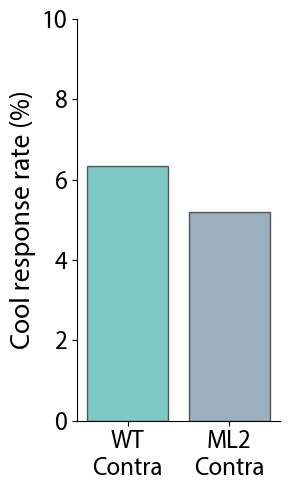


Métriques des réponses par groupe :
Cool_WT : Moyenne = 0.06, Nombre de clusters = 504, Pourcentage de réponse = 6.3%
Cool_ML2 : Moyenne = 0.05, Nombre de clusters = 289, Pourcentage de réponse = 5.2%


In [ ]:
# Chemins fichiers
file_paths = {
    "Cool_WT": "U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/spyking_analysis/cluster_response_rate/Thq-cool_Wcont_WT_resp_rate.xlsx",
    "Cool_ML2": "U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/spyking_analysis/cluster_response_rate/Thq-cool_Wcont_ML2_resp_rate.xlsx"
}


# Chargement des données
dfs = {}
for key, path in file_paths.items():
    if os.path.exists(path):
        dfs[key] = pd.read_excel(path)
    else:
        print(f"⚠️ Fichier non trouvé : {path}")


# Calcul pourcentages réponse/non-réponse
group_counts = {}
for key, df in dfs.items():
    counts = df['response'].value_counts(normalize=True) * 100
    group_counts[key] = {
        'No Response (0)': counts.get(0, 0),
        'Response (1)': counts.get(1, 0)
    }


# DataFrame pour plot
contingency_df = pd.DataFrame(group_counts).T.reset_index().rename(columns={'index': 'group'})
contingency_melted = contingency_df.melt(id_vars='group', var_name='Response Type', value_name='Percentage')
contingency_melted_response_only = contingency_melted[contingency_melted['Response Type'] == 'Response (1)']


# Couleurs personnalisées
response_colors = {
    'Cool_WT': '#13bbaf',
    'Cool_ML2': '#507b9c'
}

border_colors = 'k'

# Plot barplot
plt.figure(figsize=(3, 5))
ax = sns.barplot(
    data=contingency_melted_response_only,
    x='group', y='Percentage', hue='group',
    palette=response_colors,
    edgecolor=border_colors,
    alpha=0.6, errorbar=None
)

# Table de contingence brute
contingency_table = pd.DataFrame({
    key: dfs[key]['response'].value_counts() for key in dfs.keys()
}).fillna(0).astype(int).T

print("\nTable de contingence (nombre d'occurences de 0 et 1 par groupe) :")
print(contingency_table)

# Test global chi2
chi2, p, dof, expected = chi2_contingency(contingency_table.values)
print(f"\nTest chi2 de contingence entre groupes : chi2 = {chi2:.3f}, p = {p:.4g}, dof = {dof}")
if p < 0.05:
    print("=> Différence significative entre groupes")
else:
    print("=> Pas de différence significative entre groupes")

# Tests post-hoc (Fisher exact test)
groups = contingency_table.index.tolist()
results = []

for g1, g2 in combinations(groups, 2):
    table = contingency_table.loc[[g1, g2], [0, 1]].values
    oddsratio, pvalue = fisher_exact(table)
    results.append({'Group1': g1, 'Group2': g2, 'pvalue': pvalue})

# Correction Bonferroni
num_tests = len(results)
for res in results:
    res['pvalue_corrected'] = min(res['pvalue'] * num_tests, 1.0)

print("\nTests post-hoc (test exact de Fisher) avec correction de Bonferroni :")
for res in results:
    signif = "SIGNIFICATIF" if res['pvalue_corrected'] < 0.05 else "non significatif"
    print(f"{res['Group1']} vs {res['Group2']} : p = {res['pvalue']:.4g}, p corrigé = {res['pvalue_corrected']:.4g} -> {signif}")


# # Annoter les significativités sur le plot
# def add_contingence_sig_bar(ax, x1, x2, y, p_val, height_offset=1, fontsize=18):
#     significance = ""
#     if p_val < 0.001:
#         significance = "***"
#     elif p_val < 0.01:
#         significance = "**"
#     elif p_val < 0.05:
#         significance = "*"
#     if significance:
#         ax.plot([x1, x1, x2, x2], [y, y + height_offset, y + height_offset, y], lw=1, color='black')
#         ax.text((x1 + x2) * 0.5, y - 0.05 , significance,
#                 ha='center', va='bottom', color='black', fontsize=fontsize)

# positions = {g: i for i, g in enumerate(contingency_df['group'])}
# y_offset = contingency_melted_response_only['Percentage'].max() + 5
# spacing_between_bars = 0.8

# for res in results:
#     if res['pvalue_corrected'] < 0.05:
#         x1 = positions[res['Group1']]
#         x2 = positions[res['Group2']]
#         add_contingence_sig_bar(ax, x1, x2, y_offset, res['pvalue_corrected'])
#         y_offset += spacing_between_bars

# Labels
plt.xlabel('')
plt.ylabel('Cool response rate (%)')
plt.xticks(ticks=[0, 1], labels=['WT\nContra', 'ML2\nContra'])
plt.yticks(range(0, 11, 2))
plt.ylim(0, 10)

# Suppression bordures inutiles
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

# Sauvegarder la figure
plt.savefig(os.path.join(saving_dir, '4J_BIS_WT_vs_ML2_cool_cont_resp_rate_cluster_contingence.png'), format='png', dpi=300)
plt.savefig(os.path.join(saving_dir, '4J_BIS_WT_vs_ML2_cool_cont_resp_rate_cluster_contingence.svg'), format='svg', dpi=300)

plt.show()


############################ Metrics ############################

print("\nMétriques des réponses par groupe :")
for key, df in dfs.items():
    mean_response = df['response'].mean()  # moyenne des 0 et 1 = taux de réponse en fraction
    n_clusters = len(df)
    response_percentage = mean_response * 100
    print(f"{key} : Moyenne = {mean_response:.2f}, Nombre de clusters = {n_clusters}, Pourcentage de réponse = {response_percentage:.1f}%")



#

### Fig 4.K - ML2 vs WT cool contra SDF

n (WT_Cont) = 10
n (ML2_Cont) = 5
Wilcoxon test result: statistic = 30.0000, p-value = 0.5941


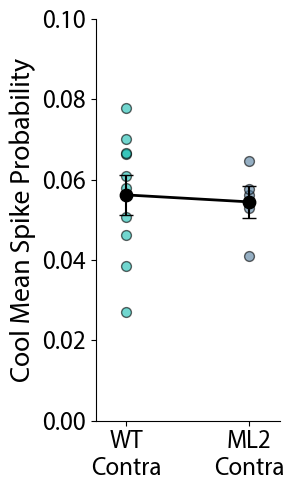

Moyenne et SEM pour:
Groupe: WT_Cont, Mean: 0.056204 ± SEM: 0.004942
Groupe: ML2_Cont, Mean: 0.054471 ± SEM: 0.003897

WT_contra: n_cluster : 504
ML2_contra: n_cluster : 289


In [8]:
# Charger les fichiers
WT_tac_cont_path = "U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/spyking_analysis/mean_sdf_period_cluster/split_files/Thq-cool_Wcont_WT_grouped.xlsx"
df_WT_tac_cont = pd.read_excel(WT_tac_cont_path)

ML2_tac_cont_path = "U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/spyking_analysis/mean_sdf_period_cluster/split_files/Thq-cool_Wcont_ML2_grouped.xlsx"
df_ML2_tac_cont = pd.read_excel(ML2_tac_cont_path)

# Filtrer pour obtenir uniquement les données où la période est 'Stim'
df_WT_tac_cont_ts = df_WT_tac_cont[df_WT_tac_cont['period'] == 'Stim']
df_ML2_tac_cont_ts = df_ML2_tac_cont[df_ML2_tac_cont['period'] == 'Stim']

# Calculer la moyenne de 'sdf' en groupant par 'directory'
df_WT_tac_cont_grouped = df_WT_tac_cont_ts.groupby('directory')['sdf'].mean().reset_index()
df_ML2_tac_cont_grouped = df_ML2_tac_cont_ts.groupby('directory')['sdf'].mean().reset_index()

# Ajouter une colonne pour différencier les groupes
df_WT_tac_cont_grouped['group'] = 'WT_Cont'
df_ML2_tac_cont_grouped['group'] = 'ML2_Cont'

n_WT_cont = len(df_WT_tac_cont_grouped)
n_ML2_cont = len(df_ML2_tac_cont_grouped)

# Effectuer le test de Wilcoxon pour comparer les groupes 'Cont' et 'Ipsi'
stat, p_value = mannwhitneyu(df_WT_tac_cont_grouped['sdf'], 
                             df_ML2_tac_cont_grouped['sdf'], 
                             alternative='two-sided')


# Afficher les résultats avec n et p-value
print(f"n (WT_Cont) = {n_WT_cont}")
print(f"n (ML2_Cont) = {n_ML2_cont}")
print(f"Wilcoxon test result: statistic = {stat:.4f}, p-value = {p_value:.4f}")


# Fusionner pour le tracé
combined_df_WT_ML2_sdf = pd.concat([df_WT_tac_cont_grouped, df_ML2_tac_cont_grouped])

# Couleurs
colors = {'WT_Cont': '#13bbaf', 'ML2_Cont': '#507b9c'}
border_colors = 'k'

# Création du plot
plt.figure(figsize=(3, 5))

# Ajouter les points individuels pour chaque 'directory'
for group in ['WT_Cont', 'ML2_Cont']:
    subset = combined_df_WT_ML2_sdf[combined_df_WT_ML2_sdf['group'] == group]
    plt.scatter(subset['group'], subset['sdf'], color=colors[group], edgecolor=border_colors, linewidth=1, alpha=0.6, s=50, zorder=6)


# Calcul des moyennes et SEM
mean_sdf = combined_df_WT_ML2_sdf.groupby('group')['sdf'].mean()
sem_sdf = combined_df_WT_ML2_sdf.groupby('group')['sdf'].sem()

# Ajouter les moyennes avec barres d'erreur
plt.scatter(mean_sdf.index, mean_sdf.values, color='black', s=80, label='Mean', zorder=10)
plt.errorbar(mean_sdf.index, mean_sdf.values, yerr=sem_sdf.values, fmt='o', color='black', capsize=5, zorder=8)

# Ajouter la ligne reliant les moyennes
plt.plot(mean_sdf.index, mean_sdf.values, color='k', linestyle='-', linewidth=2, zorder=7)

# # Fonction pour ajouter une barre de significativité
# def add_mannwhitneyu_sig_bar(x1, x2, y, p_val, height_offset=1.2, fontsize=18):
#     if p_val < 0.001:
#         significance = "***"
#     elif p_val < 0.01:
#         significance = "**"
#     elif p_val < 0.05:
#         significance = "*"
#     else:
#         return

#     plt.plot([x1, x1, x2, x2], [y, y + height_offset, y + height_offset, y], lw=1, color='black')
#     plt.text((x1 + x2) * 0.5, y , significance, ha='center', va='bottom', color='black', fontsize=fontsize)

# # Ajouter la barre de significativité si p < 0.05
# y_max = max(combined_df_WT_ML2_sdf['sdf']) + 0.02  # Ajustement vertical
# if p_value < 0.05:
#     add_mannwhitneyu_sig_bar(0, 1, y_max + 3, p_value)

# Paramètres des axes
plt.xlabel("")
plt.ylabel("Cool Mean Spike Probability")
plt.xticks([0, 1], ['WT\nContra', 'ML2\nContra'])
plt.xlim(-0.25, 1.25)
plt.ylim(0,0.1)

# Suppression des bordures superflues
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Afficher le plot
plt.tight_layout()

# Sauvegarder la figure
plt.savefig(os.path.join(saving_dir, '4K_SDF_ML2_vs_WT_TS_cool_cont.png'), format='png', dpi=300)
plt.savefig(os.path.join(saving_dir, '4K_SDF_ML2_vs_WT_TS_cool_cont.svg'), format='svg', dpi=300)


plt.show()

############################    Metrics   ############################ 

# Afficher les résultats
# Afficher les résultats des moyennes et SEM
print("Moyenne et SEM pour:")
for group in ['WT_Cont', 'ML2_Cont']:
    mean = mean_sdf[group]
    sem = sem_sdf[group]
    print(f"Groupe: {group}, Mean: {mean:.6f} ± SEM: {sem:.6f}")

# Calculer nombre cluster par conditions
n_cluster_WT_tac_cont = len(df_WT_tac_cont_ts)
n_cluster_ML2_tac_cont = len(df_ML2_tac_cont_ts)

print(f"\nWT_contra: n_cluster : {n_cluster_WT_tac_cont}")
print(f"ML2_contra: n_cluster : {n_cluster_ML2_tac_cont}")

### ML2 vs WT cool ispi SDF

n (WT_Cont) = 9
n (ML2_Cont) = 4
Wilcoxon test result: statistic = 13.0000, p-value = 0.5035


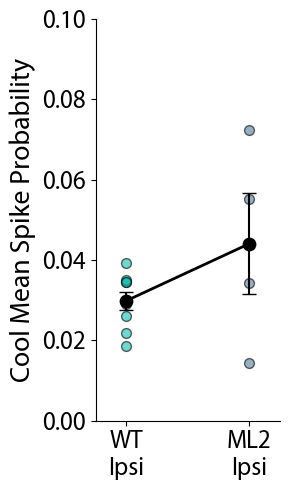

Moyenne et SEM pour:
Groupe: WT_Cont, Mean: 0.029850 ± SEM: 0.002243
Groupe: ML2_Cont, Mean: 0.044059 ± SEM: 0.012615

WT_contra: n_cluster : 296
ML2_contra: n_cluster : 141


In [5]:
# Charger les fichiers
WT_tac_cont_path = "U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/spyking_analysis/mean_sdf_period_cluster/split_files/Thq-cool_Wipsi_WT_grouped.xlsx"
df_WT_tac_cont = pd.read_excel(WT_tac_cont_path)

ML2_tac_cont_path = "U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/spyking_analysis/mean_sdf_period_cluster/split_files/Thq-cool_Wipsi_ML2_grouped.xlsx"
df_ML2_tac_cont = pd.read_excel(ML2_tac_cont_path)

# Filtrer pour obtenir uniquement les données où la période est 'Stim'
df_WT_tac_cont_ts = df_WT_tac_cont[df_WT_tac_cont['period'] == 'Stim']
df_ML2_tac_cont_ts = df_ML2_tac_cont[df_ML2_tac_cont['period'] == 'Stim']

# Calculer la moyenne de 'sdf' en groupant par 'directory'
df_WT_tac_cont_grouped = df_WT_tac_cont_ts.groupby('directory')['sdf'].mean().reset_index()
df_ML2_tac_cont_grouped = df_ML2_tac_cont_ts.groupby('directory')['sdf'].mean().reset_index()

# Ajouter une colonne pour différencier les groupes
df_WT_tac_cont_grouped['group'] = 'WT_Cont'
df_ML2_tac_cont_grouped['group'] = 'ML2_Cont'

n_WT_cont = len(df_WT_tac_cont_grouped)
n_ML2_cont = len(df_ML2_tac_cont_grouped)

# Effectuer le test de Wilcoxon pour comparer les groupes 'Cont' et 'Ipsi'
stat, p_value = mannwhitneyu(df_WT_tac_cont_grouped['sdf'], 
                             df_ML2_tac_cont_grouped['sdf'], 
                             alternative='two-sided')


# Afficher les résultats avec n et p-value
print(f"n (WT_Cont) = {n_WT_cont}")
print(f"n (ML2_Cont) = {n_ML2_cont}")
print(f"Wilcoxon test result: statistic = {stat:.4f}, p-value = {p_value:.4f}")


# Fusionner pour le tracé
combined_df_WT_ML2_sdf = pd.concat([df_WT_tac_cont_grouped, df_ML2_tac_cont_grouped])

# Couleurs
colors = {'WT_Cont': '#13bbaf', 'ML2_Cont': '#507b9c'}
border_colors = 'k'

# Création du plot
plt.figure(figsize=(3, 5))

# Ajouter les points individuels pour chaque 'directory'
for group in ['WT_Cont', 'ML2_Cont']:
    subset = combined_df_WT_ML2_sdf[combined_df_WT_ML2_sdf['group'] == group]
    plt.scatter(subset['group'], subset['sdf'], color=colors[group], edgecolor=border_colors, linewidth=1, alpha=0.6, s=50, zorder=6)


# Calcul des moyennes et SEM
mean_sdf = combined_df_WT_ML2_sdf.groupby('group')['sdf'].mean()
sem_sdf = combined_df_WT_ML2_sdf.groupby('group')['sdf'].sem()

# Ajouter les moyennes avec barres d'erreur
plt.scatter(mean_sdf.index, mean_sdf.values, color='black', s=80, label='Mean', zorder=10)
plt.errorbar(mean_sdf.index, mean_sdf.values, yerr=sem_sdf.values, fmt='o', color='black', capsize=5, zorder=8)

# Ajouter la ligne reliant les moyennes
plt.plot(mean_sdf.index, mean_sdf.values, color='k', linestyle='-', linewidth=2, zorder=7)

# Fonction pour ajouter une barre de significativité
def add_mannwhitneyu_sig_bar(x1, x2, y, p_val, height_offset=1.2, fontsize=18):
    if p_val < 0.001:
        significance = "***"
    elif p_val < 0.01:
        significance = "**"
    elif p_val < 0.05:
        significance = "*"
    else:
        return

    plt.plot([x1, x1, x2, x2], [y, y + height_offset, y + height_offset, y], lw=1, color='black')
    plt.text((x1 + x2) * 0.5, y , significance, ha='center', va='bottom', color='black', fontsize=fontsize)

# Ajouter la barre de significativité si p < 0.05
y_max = max(combined_df_WT_ML2_sdf['sdf']) + 0.02  # Ajustement vertical
if p_value < 0.05:
    add_mannwhitneyu_sig_bar(0, 1, y_max + 3, p_value)

# Paramètres des axes
plt.xlabel("")
plt.ylabel("Cool Mean Spike Probability")
plt.xticks([0, 1], ['WT\nIpsi', 'ML2\nIpsi'])
plt.xlim(-0.25, 1.25)
plt.ylim(0,0.1)

# Suppression des bordures superflues
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Afficher le plot
plt.tight_layout()


plt.show()

############################    Metrics   ############################ 

# Afficher les résultats
# Afficher les résultats des moyennes et SEM
print("Moyenne et SEM pour:")
for group in ['WT_Cont', 'ML2_Cont']:
    mean = mean_sdf[group]
    sem = sem_sdf[group]
    print(f"Groupe: {group}, Mean: {mean:.6f} ± SEM: {sem:.6f}")

# Calculer nombre cluster par conditions
n_cluster_WT_tac_cont = len(df_WT_tac_cont_ts)
n_cluster_ML2_tac_cont = len(df_ML2_tac_cont_ts)

print(f"\nWT_contra: n_cluster : {n_cluster_WT_tac_cont}")
print(f"ML2_contra: n_cluster : {n_cluster_ML2_tac_cont}")

n (WT_Cont) = 9
n (ML2_Cont) = 4
Wilcoxon test result: statistic = 13.0000, p-value = 0.5035


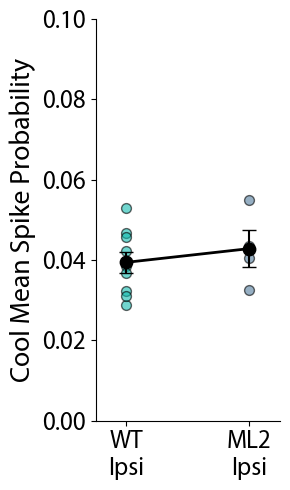

Moyenne et SEM pour:
Groupe: WT_Cont, Mean: 0.039417 ± SEM: 0.002689
Groupe: ML2_Cont, Mean: 0.042835 ± SEM: 0.004609

WT_contra: n_cluster : 296
ML2_contra: n_cluster : 141


In [6]:
# Charger les fichiers
WT_tac_cont_path = "U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/spyking_analysis/mean_sdf_period_cluster/split_files/Thq-cool_Wipsi_WT_grouped.xlsx"
df_WT_tac_cont = pd.read_excel(WT_tac_cont_path)

ML2_tac_cont_path = "U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/spyking_analysis/mean_sdf_period_cluster/split_files/Thq-cool_Wipsi_ML2_grouped.xlsx"
df_ML2_tac_cont = pd.read_excel(ML2_tac_cont_path)

# Filtrer pour obtenir uniquement les données où la période est 'Stim'
df_WT_tac_cont_ts = df_WT_tac_cont[df_WT_tac_cont['period'] == 'Baseline']
df_ML2_tac_cont_ts = df_ML2_tac_cont[df_ML2_tac_cont['period'] == 'Baseline']

# Calculer la moyenne de 'sdf' en groupant par 'directory'
df_WT_tac_cont_grouped = df_WT_tac_cont_ts.groupby('directory')['sdf'].mean().reset_index()
df_ML2_tac_cont_grouped = df_ML2_tac_cont_ts.groupby('directory')['sdf'].mean().reset_index()

# Ajouter une colonne pour différencier les groupes
df_WT_tac_cont_grouped['group'] = 'WT_Cont'
df_ML2_tac_cont_grouped['group'] = 'ML2_Cont'

n_WT_cont = len(df_WT_tac_cont_grouped)
n_ML2_cont = len(df_ML2_tac_cont_grouped)

# Effectuer le test de Wilcoxon pour comparer les groupes 'Cont' et 'Ipsi'
stat, p_value = mannwhitneyu(df_WT_tac_cont_grouped['sdf'], 
                             df_ML2_tac_cont_grouped['sdf'], 
                             alternative='two-sided')


# Afficher les résultats avec n et p-value
print(f"n (WT_Cont) = {n_WT_cont}")
print(f"n (ML2_Cont) = {n_ML2_cont}")
print(f"Wilcoxon test result: statistic = {stat:.4f}, p-value = {p_value:.4f}")


# Fusionner pour le tracé
combined_df_WT_ML2_sdf = pd.concat([df_WT_tac_cont_grouped, df_ML2_tac_cont_grouped])

# Couleurs
colors = {'WT_Cont': '#13bbaf', 'ML2_Cont': '#507b9c'}
border_colors = 'k'

# Création du plot
plt.figure(figsize=(3, 5))

# Ajouter les points individuels pour chaque 'directory'
for group in ['WT_Cont', 'ML2_Cont']:
    subset = combined_df_WT_ML2_sdf[combined_df_WT_ML2_sdf['group'] == group]
    plt.scatter(subset['group'], subset['sdf'], color=colors[group], edgecolor=border_colors, linewidth=1, alpha=0.6, s=50, zorder=6)


# Calcul des moyennes et SEM
mean_sdf = combined_df_WT_ML2_sdf.groupby('group')['sdf'].mean()
sem_sdf = combined_df_WT_ML2_sdf.groupby('group')['sdf'].sem()

# Ajouter les moyennes avec barres d'erreur
plt.scatter(mean_sdf.index, mean_sdf.values, color='black', s=80, label='Mean', zorder=10)
plt.errorbar(mean_sdf.index, mean_sdf.values, yerr=sem_sdf.values, fmt='o', color='black', capsize=5, zorder=8)

# Ajouter la ligne reliant les moyennes
plt.plot(mean_sdf.index, mean_sdf.values, color='k', linestyle='-', linewidth=2, zorder=7)

# Fonction pour ajouter une barre de significativité
def add_mannwhitneyu_sig_bar(x1, x2, y, p_val, height_offset=1.2, fontsize=18):
    if p_val < 0.001:
        significance = "***"
    elif p_val < 0.01:
        significance = "**"
    elif p_val < 0.05:
        significance = "*"
    else:
        return

    plt.plot([x1, x1, x2, x2], [y, y + height_offset, y + height_offset, y], lw=1, color='black')
    plt.text((x1 + x2) * 0.5, y , significance, ha='center', va='bottom', color='black', fontsize=fontsize)

# Ajouter la barre de significativité si p < 0.05
y_max = max(combined_df_WT_ML2_sdf['sdf']) + 0.02  # Ajustement vertical
if p_value < 0.05:
    add_mannwhitneyu_sig_bar(0, 1, y_max + 3, p_value)

# Paramètres des axes
plt.xlabel("")
plt.ylabel("Cool Mean Spike Probability")
plt.xticks([0, 1], ['WT\nIpsi', 'ML2\nIpsi'])
plt.xlim(-0.25, 1.25)
plt.ylim(0,0.1)

# Suppression des bordures superflues
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Afficher le plot
plt.tight_layout()


plt.show()

############################    Metrics   ############################ 

# Afficher les résultats
# Afficher les résultats des moyennes et SEM
print("Moyenne et SEM pour:")
for group in ['WT_Cont', 'ML2_Cont']:
    mean = mean_sdf[group]
    sem = sem_sdf[group]
    print(f"Groupe: {group}, Mean: {mean:.6f} ± SEM: {sem:.6f}")

# Calculer nombre cluster par conditions
n_cluster_WT_tac_cont = len(df_WT_tac_cont_ts)
n_cluster_ML2_tac_cont = len(df_ML2_tac_cont_ts)

print(f"\nWT_contra: n_cluster : {n_cluster_WT_tac_cont}")
print(f"ML2_contra: n_cluster : {n_cluster_ML2_tac_cont}")

n (WT_Cont) = 9
n (ML2_Cont) = 4
Wilcoxon test result: statistic = 25.0000, p-value = 0.3301


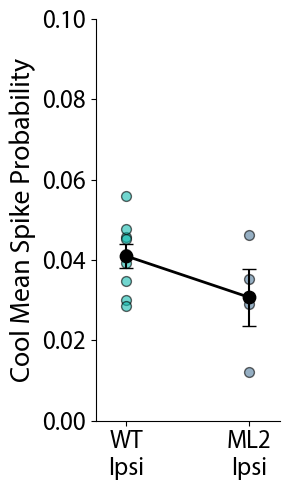

Moyenne et SEM pour:
Groupe: WT_Cont, Mean: 0.040990 ± SEM: 0.002941
Groupe: ML2_Cont, Mean: 0.030704 ± SEM: 0.007120

WT_contra: n_cluster : 296
ML2_contra: n_cluster : 141


In [7]:
# Charger les fichiers
WT_tac_cont_path = "U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/spyking_analysis/mean_sdf_period_cluster/split_files/Thq-cool_Wipsi_WT_grouped.xlsx"
df_WT_tac_cont = pd.read_excel(WT_tac_cont_path)

ML2_tac_cont_path = "U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/spyking_analysis/mean_sdf_period_cluster/split_files/Thq-cool_Wipsi_ML2_grouped.xlsx"
df_ML2_tac_cont = pd.read_excel(ML2_tac_cont_path)

# Filtrer pour obtenir uniquement les données où la période est 'Stim'
df_WT_tac_cont_ts = df_WT_tac_cont[df_WT_tac_cont['period'] == 'Post_stim']
df_ML2_tac_cont_ts = df_ML2_tac_cont[df_ML2_tac_cont['period'] == 'Post_stim']

# Calculer la moyenne de 'sdf' en groupant par 'directory'
df_WT_tac_cont_grouped = df_WT_tac_cont_ts.groupby('directory')['sdf'].mean().reset_index()
df_ML2_tac_cont_grouped = df_ML2_tac_cont_ts.groupby('directory')['sdf'].mean().reset_index()

# Ajouter une colonne pour différencier les groupes
df_WT_tac_cont_grouped['group'] = 'WT_Cont'
df_ML2_tac_cont_grouped['group'] = 'ML2_Cont'

n_WT_cont = len(df_WT_tac_cont_grouped)
n_ML2_cont = len(df_ML2_tac_cont_grouped)

# Effectuer le test de Wilcoxon pour comparer les groupes 'Cont' et 'Ipsi'
stat, p_value = mannwhitneyu(df_WT_tac_cont_grouped['sdf'], 
                             df_ML2_tac_cont_grouped['sdf'], 
                             alternative='two-sided')


# Afficher les résultats avec n et p-value
print(f"n (WT_Cont) = {n_WT_cont}")
print(f"n (ML2_Cont) = {n_ML2_cont}")
print(f"Wilcoxon test result: statistic = {stat:.4f}, p-value = {p_value:.4f}")


# Fusionner pour le tracé
combined_df_WT_ML2_sdf = pd.concat([df_WT_tac_cont_grouped, df_ML2_tac_cont_grouped])

# Couleurs
colors = {'WT_Cont': '#13bbaf', 'ML2_Cont': '#507b9c'}
border_colors = 'k'

# Création du plot
plt.figure(figsize=(3, 5))

# Ajouter les points individuels pour chaque 'directory'
for group in ['WT_Cont', 'ML2_Cont']:
    subset = combined_df_WT_ML2_sdf[combined_df_WT_ML2_sdf['group'] == group]
    plt.scatter(subset['group'], subset['sdf'], color=colors[group], edgecolor=border_colors, linewidth=1, alpha=0.6, s=50, zorder=6)


# Calcul des moyennes et SEM
mean_sdf = combined_df_WT_ML2_sdf.groupby('group')['sdf'].mean()
sem_sdf = combined_df_WT_ML2_sdf.groupby('group')['sdf'].sem()

# Ajouter les moyennes avec barres d'erreur
plt.scatter(mean_sdf.index, mean_sdf.values, color='black', s=80, label='Mean', zorder=10)
plt.errorbar(mean_sdf.index, mean_sdf.values, yerr=sem_sdf.values, fmt='o', color='black', capsize=5, zorder=8)

# Ajouter la ligne reliant les moyennes
plt.plot(mean_sdf.index, mean_sdf.values, color='k', linestyle='-', linewidth=2, zorder=7)

# Fonction pour ajouter une barre de significativité
def add_mannwhitneyu_sig_bar(x1, x2, y, p_val, height_offset=1.2, fontsize=18):
    if p_val < 0.001:
        significance = "***"
    elif p_val < 0.01:
        significance = "**"
    elif p_val < 0.05:
        significance = "*"
    else:
        return

    plt.plot([x1, x1, x2, x2], [y, y + height_offset, y + height_offset, y], lw=1, color='black')
    plt.text((x1 + x2) * 0.5, y , significance, ha='center', va='bottom', color='black', fontsize=fontsize)

# Ajouter la barre de significativité si p < 0.05
y_max = max(combined_df_WT_ML2_sdf['sdf']) + 0.02  # Ajustement vertical
if p_value < 0.05:
    add_mannwhitneyu_sig_bar(0, 1, y_max + 3, p_value)

# Paramètres des axes
plt.xlabel("")
plt.ylabel("Cool Mean Spike Probability")
plt.xticks([0, 1], ['WT\nIpsi', 'ML2\nIpsi'])
plt.xlim(-0.25, 1.25)
plt.ylim(0,0.1)

# Suppression des bordures superflues
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Afficher le plot
plt.tight_layout()


plt.show()

############################    Metrics   ############################ 

# Afficher les résultats
# Afficher les résultats des moyennes et SEM
print("Moyenne et SEM pour:")
for group in ['WT_Cont', 'ML2_Cont']:
    mean = mean_sdf[group]
    sem = sem_sdf[group]
    print(f"Groupe: {group}, Mean: {mean:.6f} ± SEM: {sem:.6f}")

# Calculer nombre cluster par conditions
n_cluster_WT_tac_cont = len(df_WT_tac_cont_ts)
n_cluster_ML2_tac_cont = len(df_ML2_tac_cont_ts)

print(f"\nWT_contra: n_cluster : {n_cluster_WT_tac_cont}")
print(f"ML2_contra: n_cluster : {n_cluster_ML2_tac_cont}")

### Selection des aniamux reactif au stim cool

In [54]:
# # Charger les fichiers
# WT_tac_cont_path = "U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/spyking_analysis/mean_sdf_period_cluster/split_files_filtered_shank_thq_cool/Thq-cool_Wcont_WT_sdf_mean_period_filtered.xlsx"
# df_WT_tac_cont = pd.read_excel(WT_tac_cont_path)

# ML2_tac_cont_path = "U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/spyking_analysis/mean_sdf_period_cluster/split_files_filtered_shank_thq_cool/Thq-cool_Wcont_ML2_sdf_mean_period_filtered.xlsx"
# df_ML2_tac_cont = pd.read_excel(ML2_tac_cont_path)

# # Filtrer pour obtenir uniquement les données où la période est 'Stim'
# df_WT_tac_cont_ts = df_WT_tac_cont[df_WT_tac_cont['period'] == 'Stim']
# df_ML2_tac_cont_ts = df_ML2_tac_cont[df_ML2_tac_cont['period'] == 'Stim']

# # Calculer la moyenne de 'sdf' en groupant par 'directory'
# df_WT_tac_cont_grouped = df_WT_tac_cont_ts.groupby('directory')['sdf'].mean().reset_index()
# df_ML2_tac_cont_grouped = df_ML2_tac_cont_ts.groupby('directory')['sdf'].mean().reset_index()

# # Ajouter une colonne pour différencier les groupes
# df_WT_tac_cont_grouped['group'] = 'WT_Cont'
# df_ML2_tac_cont_grouped['group'] = 'ML2_Cont'

# n_WT_cont = len(df_WT_tac_cont_grouped)
# n_ML2_cont = len(df_ML2_tac_cont_grouped)

# # Effectuer le test de Wilcoxon pour comparer les groupes 'Cont' et 'Ipsi'
# stat, p_value = mannwhitneyu(df_WT_tac_cont_grouped['sdf'], 
#                              df_ML2_tac_cont_grouped['sdf'], 
#                              alternative='two-sided')


# # Afficher les résultats avec n et p-value
# print(f"n (WT_Cont) = {n_WT_cont}")
# print(f"n (ML2_Cont) = {n_ML2_cont}")
# print(f"Wilcoxon test result: statistic = {stat:.4f}, p-value = {p_value:.4f}")


# # Fusionner pour le tracé
# combined_df_WT_ML2_sdf = pd.concat([df_WT_tac_cont_grouped, df_ML2_tac_cont_grouped])

# # Couleurs
# colors = {'WT_Cont': '#13bbaf', 'ML2_Cont': '#507b9c'}
# border_colors = 'k'

# # Création du plot
# plt.figure(figsize=(3, 5))

# # Ajouter les points individuels pour chaque 'directory'
# for group in ['WT_Cont', 'ML2_Cont']:
#     subset = combined_df_WT_ML2_sdf[combined_df_WT_ML2_sdf['group'] == group]
#     plt.scatter(subset['group'], subset['sdf'], color=colors[group], edgecolor=border_colors, linewidth=1, alpha=0.6, s=50, zorder=6)


# # Calcul des moyennes et SEM
# mean_sdf = combined_df_WT_ML2_sdf.groupby('group')['sdf'].mean()
# sem_sdf = combined_df_WT_ML2_sdf.groupby('group')['sdf'].sem()

# # Ajouter les moyennes avec barres d'erreur
# plt.scatter(mean_sdf.index, mean_sdf.values, color='black', s=80, label='Mean', zorder=10)
# plt.errorbar(mean_sdf.index, mean_sdf.values, yerr=sem_sdf.values, fmt='o', color='black', capsize=5, zorder=8)

# # Ajouter la ligne reliant les moyennes
# plt.plot(mean_sdf.index, mean_sdf.values, color='k', linestyle='-', linewidth=2, zorder=7)

# # Fonction pour ajouter une barre de significativité
# def add_mannwhitneyu_sig_bar(x1, x2, y, p_val, height_offset=1.2, fontsize=18):
#     if p_val < 0.001:
#         significance = "***"
#     elif p_val < 0.01:
#         significance = "**"
#     elif p_val < 0.05:
#         significance = "*"
#     else:
#         return

#     plt.plot([x1, x1, x2, x2], [y, y + height_offset, y + height_offset, y], lw=1, color='black')
#     plt.text((x1 + x2) * 0.5, y , significance, ha='center', va='bottom', color='black', fontsize=fontsize)

# # Ajouter la barre de significativité si p < 0.05
# y_max = max(combined_df_WT_ML2_sdf['sdf']) + 0.02  # Ajustement vertical
# if p_value < 0.05:
#     add_mannwhitneyu_sig_bar(0, 1, y_max + 3, p_value)

# # Paramètres des axes
# plt.xlabel("")
# plt.ylabel("Cool Mean Spike Probability")
# plt.xticks([0, 1], ['WT\nContra', 'ML2\nContra'])
# plt.xlim(-0.25, 1.25)
# plt.ylim(0,0.1)

# # Suppression des bordures superflues
# ax = plt.gca()
# ax.spines['top'].set_visible(False)
# ax.spines['right'].set_visible(False)

# # Afficher le plot
# plt.tight_layout()

# # # Sauvegarder la figure
# # plt.savefig(os.path.join(saving_dir, '4Kbis_SDF_ML2_vs_WT_TS_cool_cont.png'), format='png', dpi=300)
# # plt.savefig(os.path.join(saving_dir, '4Kbis_SDF_ML2_vs_WT_TS_cool_cont.svg'), format='svg', dpi=300)


# plt.show()

# ############################    Metrics   ############################ 

# # Afficher les résultats
# # Afficher les résultats des moyennes et SEM
# print("Moyenne et SEM pour:")
# for group in ['WT_Cont', 'ML2_Cont']:
#     mean = mean_sdf[group]
#     sem = sem_sdf[group]
#     print(f"Groupe: {group}, Mean: {mean:.6f} ± SEM: {sem:.6f}")

# # Calculer nombre cluster par conditions
# n_cluster_WT_tac_cont = len(df_WT_tac_cont_ts)
# n_cluster_ML2_tac_cont = len(df_ML2_tac_cont_ts)

# print(f"\nWT_contra: n_cluster : {n_cluster_WT_tac_cont}")
# print(f"ML2_contra: n_cluster : {n_cluster_ML2_tac_cont}")

### Fig 4.K_BIS - Cluster - ML2 vs WT cool contra SDF


Test de Mann-Whitney : Statistique=68256.5000, p-value=0.1409, n_cont=504, n_ipsi=289


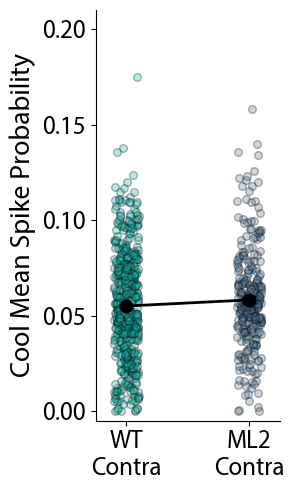

Moyenne et SEM pour chaque groupe :
WT_Cool : 0.055018 ± 0.001271
ML2_Cool : 0.058225 ± 0.001546

WT_Cool : n_cluster = 504
ML2_Cool   : n_cluster = 289
Le fichier a été sauvegardé sous : U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/spyking_analysis/plot_for_fig/Plot_svg_illustrator\Plot_Fig_4_WT_vs_ML2_Thq\df_sdf_WT_vs_ML2_cool_cluster.xlsx


In [17]:
# Charger les fichiers
WT_cool_cont_path = "U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/spyking_analysis/mean_sdf_period_cluster/split_files/Thq-cool_Wcont_WT_grouped.xlsx"
df_WT_cool_cont = pd.read_excel(WT_cool_cont_path)

ML2_cool_cont_path = "U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/spyking_analysis/mean_sdf_period_cluster/split_files/Thq-cool_Wcont_ML2_grouped.xlsx"
df_ML2_cool_cont = pd.read_excel(ML2_cool_cont_path)

# Filtrer pour obtenir uniquement les données où la période est 'Stim'
df_WT_cool_cont_ts = df_WT_cool_cont[df_WT_cool_cont['period'] == 'Stim']
df_ML2_cool_cont_ts = df_ML2_cool_cont[df_ML2_cool_cont['period'] == 'Stim']

# Regrouper par neurone unique et période pour s'assurer d'une entrée unique
df_WT_cool_cont_ts_cluster = df_WT_cool_cont_ts.groupby(['directory', 'file_name', 'neuron_id', 'period'], as_index=False, observed=True).mean(numeric_only=True)
df_ML2_cool_cont_ts_cluster = df_ML2_cool_cont_ts.groupby(['directory', 'file_name', 'neuron_id', 'period'], as_index=False, observed=True).mean(numeric_only=True)

# Ajouter une colonne pour différencier les groupes
df_WT_cool_cont_ts_cluster['group'] = 'WT_Cool'
df_ML2_cool_cont_ts_cluster['group'] = 'ML2_Cool'


# Mann-Whitney test sur les deux groupes
sdf_WT_Cool_cont = df_WT_cool_cont_ts_cluster['sdf']
sdf_ML2_Cool_cont = df_ML2_cool_cont_ts_cluster['sdf']

stat_mannwhit, p_value_mannwhit = mannwhitneyu(sdf_WT_Cool_cont, sdf_ML2_Cool_cont, alternative='two-sided')

print(f"\nTest de Mann-Whitney : Statistique={stat_mannwhit:.4f}, p-value={p_value_mannwhit:.4f}, n_cont={len(sdf_WT_Cool_cont)}, n_ipsi={len(sdf_ML2_Cool_cont)}")


# Fusionner pour le tracé
df_combined_cool_cluster = pd.concat([df_WT_cool_cont_ts_cluster, df_ML2_cool_cont_ts_cluster])

# Couleurs
colors = {'WT_Cool': '#13bbaf', 'ML2_Cool': '#507b9c'}

border_colors = 'k'

# Création du plot
plt.figure(figsize=(3, 5))

# Ajouter les points individuels avec léger jitter
group_mapping = {'WT_Cool': 0, 'ML2_Cool': 1}
for group in ['WT_Cool', 'ML2_Cool']:
    subset = df_combined_cool_cluster[df_combined_cool_cluster['group'] == group]
    x_vals = np.ones(len(subset)) * group_mapping[group]
    x_vals += np.random.uniform(-0.1, 0.1, size=len(subset))  # jitter horizontal
    plt.scatter(x_vals, subset['sdf'], color=colors[group], edgecolor=border_colors, linewidth=1, alpha=0.3, s=30, zorder=6)

# Calcul des moyennes et SEM
mean_sdf_cool_cluster = df_combined_cool_cluster.groupby('group')['sdf'].mean()
sem_sdf_cool_cluster = df_combined_cool_cluster.groupby('group')['sdf'].sem()


# Obtenir les positions numériques dans le même ordre que mean_sdf.index
x_pos = [group_mapping[group] for group in mean_sdf_cool_cluster.index]

# Ajouter les moyennes avec barres d'erreur
plt.scatter(x_pos, mean_sdf_cool_cluster.values, color='black', s=80, label='Mean', zorder=10)
plt.errorbar(x_pos, mean_sdf_cool_cluster.values, yerr=sem_sdf_cool_cluster.values, fmt='o', color='black', capsize=5, zorder=8)

# Ajouter la ligne reliant les moyennes
plt.plot(x_pos, mean_sdf_cool_cluster.values, color='k', linestyle='-', linewidth=2, zorder=7)



# # Ajouter la barre de significativité
# def add_MannWhitney_sig_bar(x1, x2, y, p_value_mannwhit, height_offset=0.005, fontsize=18):
#     if p_value_mannwhit < 0.001:
#         significance = "***"
#     elif p_value_mannwhit < 0.01:
#         significance = "**"
#     elif p_value_mannwhit < 0.05:
#         significance = "*"
#     else:
#         return
#     plt.plot([x1, x1, x2, x2], [y, y + height_offset, y + height_offset, y], lw=1, color='black')
#     plt.text((x1 + x2) * 0.5, y + height_offset, significance, ha='center', va='bottom', color='black', fontsize=fontsize)

# # Ajouter si p < 0.05
# y_max = max(df_combined_cool_cluster['sdf']) + 0.02
# if p_value_mannwhit < 0.05:
#     add_MannWhitney_sig_bar(0, 1, y_max, p_value_mannwhit)

# Mise en forme
plt.xlabel("")
plt.ylabel("Cool Mean Spike Probability")
plt.xticks([0, 1], ['WT\nContra', 'ML2\nContra'])
plt.xlim(-0.25, 1.25)
plt.ylim(-0.005, 0.21)

# Nettoyer les bords
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

# Sauvegarder la figure
plt.savefig(os.path.join(saving_dir, '4K_BIS_SDF_ML2_vs_WT_TS_cool_cont_cluster.png'), format='png', dpi=300)
plt.savefig(os.path.join(saving_dir, '4K_BIS_SDF_ML2_vs_WT_TS_cool_cont_cluster.svg'), format='svg', dpi=300)


plt.show()


############################    Metrics   ############################ 
print("Moyenne et SEM pour chaque groupe :")
for group in ['WT_Cool', 'ML2_Cool']:
    mean = mean_sdf_cool_cluster[group]
    sem = sem_sdf_cool_cluster[group]
    print(f"{group} : {mean:.6f} ± {sem:.6f}")

# Nombre de clusters
n_cluster_WT_cool = len(df_WT_cool_cont_ts)
n_cluster_ML2_cool = len(df_ML2_cool_cont_ts)
print(f"\nWT_Cool : n_cluster = {n_cluster_WT_cool}")
print(f"ML2_Cool   : n_cluster = {n_cluster_ML2_cool}")


###### VERIFICATION ######

file_name = "df_sdf_WT_vs_ML2_cool_cluster.xlsx"

anova_path = os.path.join(saving_dir,file_name)

# Sauvegarder le DataFrame `df_combined` dans le fichier Excel
df_combined_cool_cluster.to_excel(anova_path , index=False)

print(f"Le fichier a été sauvegardé sous : {anova_path}")




#

### Fig 4.L - ML2 vs WT Warm contra response rate

n (WT_Cont) = 10
n (ML2_cont) = 5
Wilcoxon test result: statistic = 29.0000, p-value = 0.5822


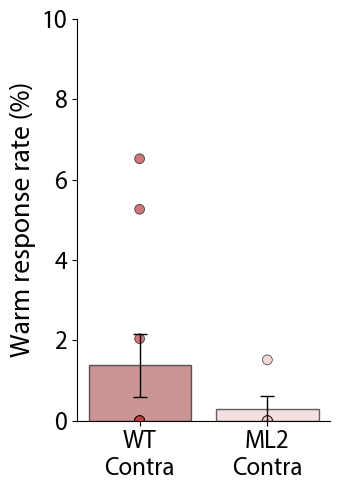


WT_tac_cont : mean = 1.38 ± 0.78
ML2_tac_cont : mean = 0.30 ± 0.30


In [67]:
# Charger les fichiers
WT_tac_cont_path = "U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/spyking_analysis/cluster_response_rate/Thq-hot_Wcont_WT_resp_rate.xlsx"
df_WT_tac_cont = pd.read_excel(WT_tac_cont_path)

ML2_tac_cont_path = "U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/spyking_analysis/cluster_response_rate/Thq-hot_Wcont_ML2_resp_rate.xlsx"
df_ML2_tac_cont = pd.read_excel(ML2_tac_cont_path)

# Calcul du pourcentage de '1' dans la colonne 'response' pour chaque combinaison de 'directory' et 'file_name'
def calculate_response_percentage(df):
    # Grouper par 'directory' et 'file_name' et calculer le pourcentage de 1 dans la colonne 'response'
    response_percentage = df.groupby(['directory', 'file_name'])['response'].agg(
        lambda x: (x.sum() / len(x)) * 100
    ).reset_index()
    
    # Renommer la colonne pour plus de clarté
    response_percentage.rename(columns={'response': 'response_percentage'}, inplace=True)
    
    return response_percentage

# Appliquer la fonction sur chaque DataFrame
response_percentage_WT_tac_cont = calculate_response_percentage(df_WT_tac_cont)
response_percentage_ML2_tac_cont = calculate_response_percentage(df_ML2_tac_cont)


# Calculer la moyenne des pourcentages de réponse pour chaque 'directory' commun
average_response_percentage_WT_cont = response_percentage_WT_tac_cont.groupby('directory')['response_percentage'].mean().reset_index()
average_response_percentage_ML2_cont = response_percentage_ML2_tac_cont.groupby('directory')['response_percentage'].mean().reset_index()

# Créer une nouvelle colonne 'group' pour identifier chaque DataFrame
average_response_percentage_WT_cont['group'] = 'WT_Cont'
average_response_percentage_ML2_cont['group'] = 'ML2_cont'

# Fusionner les deux DataFrames en un seul
combined_df_WT_ML2 = pd.concat([average_response_percentage_WT_cont, average_response_percentage_ML2_cont])

# Calculer la SEM pour chaque groupe
combined_df_WT_ML2['sem'] = combined_df_WT_ML2.groupby('group')['response_percentage'].transform(sem)

# Calculer n (le nombre d'observations pour chaque groupe)
n_WT_cont = len(average_response_percentage_WT_cont)
n_ML2_cont = len(average_response_percentage_ML2_cont)


# Effectuer le test de Wilcoxon pour comparer les groupes 'Cont' et 'Ipsi'
stat, p_value = mannwhitneyu(average_response_percentage_WT_cont['response_percentage'], 
                             average_response_percentage_ML2_cont['response_percentage'], 
                             alternative='two-sided')


# Afficher les résultats avec n et p-value
print(f"n (WT_Cont) = {n_WT_cont}")
print(f"n (ML2_cont) = {n_ML2_cont}")
print(f"Wilcoxon test result: statistic = {stat:.4f}, p-value = {p_value:.4f}")

# Couleurs
colors = {'WT_Cont': '#bb3f3f', 'ML2_cont': '#F2C7C7'}
border_colors = 'k'

# Plot
plt.figure(figsize=(3.5, 5))

# Créer un barplot par groupe (moyenne des response_percentage par group) avec des couleurs personnalisées
sns.barplot(x='group', y='response_percentage', data=combined_df_WT_ML2, 
            errorbar=None,  # Désactive les barres d'erreur
            hue='group', palette=colors, capsize=0.1, err_kws={'linewidth': 1}, alpha=0.6, edgecolor=border_colors)

# Ajouter des points de scatter pour chaque directory avec des couleurs personnalisées pour chaque groupe
sns.scatterplot(x='group', y='response_percentage', hue='group', data=combined_df_WT_ML2, 
                palette=colors, s=50, legend=None, marker='o', edgecolor=border_colors, alpha=0.7)


# Ajouter les barres d'erreur (SEM)
for i, group in enumerate(combined_df_WT_ML2['group'].unique()):
    group_data = combined_df_WT_ML2[combined_df_WT_ML2['group'] == group]
    plt.errorbar(x=[i], y=group_data['response_percentage'].mean(), yerr=group_data['sem'].mean(),
                 fmt='none', color=border_colors, capsize=5, elinewidth=1)


# Fonction pour ajouter une barre de significativité
def add_mannwhitneyu_sig_bar(x1, x2, y, p_val, height_offset=1.2, fontsize=18):
    if p_val < 0.001:
        significance = "***"
    elif p_val < 0.01:
        significance = "**"
    elif p_val < 0.05:
        significance = "*"
    else:
        return

    plt.plot([x1, x1, x2, x2], [y, y + height_offset, y + height_offset, y], lw=1, color='black')
    plt.text((x1 + x2) * 0.5, y , significance, ha='center', va='bottom', color='black', fontsize=fontsize)

# Ajouter la barre de significativité si p < 0.05
y_max = max(combined_df_WT_ML2['response_percentage']) + 0.02  # Ajustement vertical
if p_value < 0.05:
    add_mannwhitneyu_sig_bar(0, 1, y_max + 3, p_value)


# Ajouter le titre et les labels
plt.xlabel('')
plt.ylabel('Warm response rate (%)')
xtick_labels = ['WT\nContra', 'ML2\nContra']  # Les nouveaux labels pour les xticks
plt.xticks(ticks=[0, 1], labels=xtick_labels)
plt.yticks(range(0, 11, 2))
plt.ylim(0, 10)


# Suppression des bordures superflues
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Afficher le graphique
plt.tight_layout()

# Sauvegarder la figure
plt.savefig(os.path.join(saving_dir, '4L_WT_vs_ML2_warm_cont_resp_rate.png'), format='png', dpi=300)
plt.savefig(os.path.join(saving_dir, '4L_WT_vs_ML2_warm_cont_resp_rate.svg'), format='svg', dpi=300)

plt.show()


############################    Metrics   ############################ 

# Calculer la moyenne et SEM pour 'WT_tac_cont'
mean_WT_cont = average_response_percentage_WT_cont['response_percentage'].mean()
sem_WT_cont = sem(average_response_percentage_WT_cont['response_percentage'])

# Calculer la moyenne et SEM pour 'ML2_tac_cont'
mean_ML2_cont = average_response_percentage_ML2_cont['response_percentage'].mean()
sem_ML2_cont = sem(average_response_percentage_ML2_cont['response_percentage'])

# Afficher les résultats
print(f"\nWT_tac_cont : mean = {mean_WT_cont:.2f} ± {sem_WT_cont:.2f}")
print(f"ML2_tac_cont : mean = {mean_ML2_cont:.2f} ± {sem_ML2_cont:.2f}")


### Fig 4.L_BIS - Cluster - ML2 vs WT Warm contra response rate


Table de contingence (nombre d'occurences de 0 et 1 par groupe) :
response    0  1
Warm_WT   415  7
Warm_ML2  169  1

Test chi2 de contingence entre groupes : chi2 = 0.393, p = 0.5305, dof = 1
=> Pas de différence significative entre groupes

Tests post-hoc (test exact de Fisher) avec correction de Bonferroni :
Warm_WT vs Warm_ML2 : p = 0.4497, p corrigé = 0.4497 -> non significatif


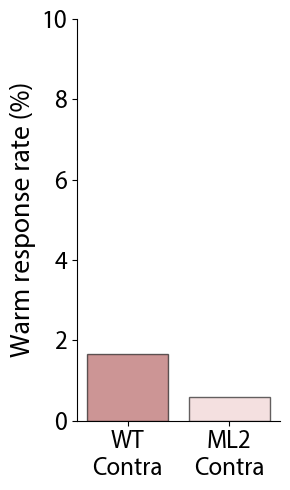


Métriques des réponses par groupe :
Warm_WT : Moyenne = 0.02, Nombre de clusters = 422, Pourcentage de réponse = 1.7%
Warm_ML2 : Moyenne = 0.01, Nombre de clusters = 170, Pourcentage de réponse = 0.6%


In [12]:
# Chemins fichiers
file_paths = {
    "Warm_WT": "U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/spyking_analysis/cluster_response_rate/Thq-hot_Wcont_WT_resp_rate.xlsx",
    "Warm_ML2": "U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/spyking_analysis/cluster_response_rate/Thq-hot_Wcont_ML2_resp_rate.xlsx"
}


# Chargement des données
dfs = {}
for key, path in file_paths.items():
    if os.path.exists(path):
        dfs[key] = pd.read_excel(path)
    else:
        print(f"⚠️ Fichier non trouvé : {path}")


# Calcul pourcentages réponse/non-réponse
group_counts = {}
for key, df in dfs.items():
    counts = df['response'].value_counts(normalize=True) * 100
    group_counts[key] = {
        'No Response (0)': counts.get(0, 0),
        'Response (1)': counts.get(1, 0)
    }


# DataFrame pour plot
contingency_df = pd.DataFrame(group_counts).T.reset_index().rename(columns={'index': 'group'})
contingency_melted = contingency_df.melt(id_vars='group', var_name='Response Type', value_name='Percentage')
contingency_melted_response_only = contingency_melted[contingency_melted['Response Type'] == 'Response (1)']


# Couleurs personnalisées
response_colors = {
    'Warm_WT': '#bb3f3f',
    'Warm_ML2': '#F2C7C7'
}

border_colors = 'k'

# Plot barplot
plt.figure(figsize=(3, 5))
ax = sns.barplot(
    data=contingency_melted_response_only,
    x='group', y='Percentage', hue='group',
    palette=response_colors,
    edgecolor=border_colors,
    alpha=0.6, errorbar=None
)

# Table de contingence brute
contingency_table = pd.DataFrame({
    key: dfs[key]['response'].value_counts() for key in dfs.keys()
}).fillna(0).astype(int).T

print("\nTable de contingence (nombre d'occurences de 0 et 1 par groupe) :")
print(contingency_table)

# Test global chi2
chi2, p, dof, expected = chi2_contingency(contingency_table.values)
print(f"\nTest chi2 de contingence entre groupes : chi2 = {chi2:.3f}, p = {p:.4g}, dof = {dof}")
if p < 0.05:
    print("=> Différence significative entre groupes")
else:
    print("=> Pas de différence significative entre groupes")

# Tests post-hoc (Fisher exact test)
groups = contingency_table.index.tolist()
results = []

for g1, g2 in combinations(groups, 2):
    table = contingency_table.loc[[g1, g2], [0, 1]].values
    oddsratio, pvalue = fisher_exact(table)
    results.append({'Group1': g1, 'Group2': g2, 'pvalue': pvalue})

# Correction Bonferroni
num_tests = len(results)
for res in results:
    res['pvalue_corrected'] = min(res['pvalue'] * num_tests, 1.0)

print("\nTests post-hoc (test exact de Fisher) avec correction de Bonferroni :")
for res in results:
    signif = "SIGNIFICATIF" if res['pvalue_corrected'] < 0.05 else "non significatif"
    print(f"{res['Group1']} vs {res['Group2']} : p = {res['pvalue']:.4g}, p corrigé = {res['pvalue_corrected']:.4g} -> {signif}")


# # Annoter les significativités sur le plot
# def add_contingence_sig_bar(ax, x1, x2, y, p_val, height_offset=1, fontsize=18):
#     significance = ""
#     if p_val < 0.001:
#         significance = "***"
#     elif p_val < 0.01:
#         significance = "**"
#     elif p_val < 0.05:
#         significance = "*"
#     if significance:
#         ax.plot([x1, x1, x2, x2], [y, y + height_offset, y + height_offset, y], lw=1, color='black')
#         ax.text((x1 + x2) * 0.5, y - 0.05 , significance,
#                 ha='center', va='bottom', color='black', fontsize=fontsize)

# positions = {g: i for i, g in enumerate(contingency_df['group'])}
# y_offset = contingency_melted_response_only['Percentage'].max() + 5
# spacing_between_bars = 0.8

# for res in results:
#     if res['pvalue_corrected'] < 0.05:
#         x1 = positions[res['Group1']]
#         x2 = positions[res['Group2']]
#         add_contingence_sig_bar(ax, x1, x2, y_offset, res['pvalue_corrected'])
#         y_offset += spacing_between_bars

# Labels
plt.xlabel('')
plt.ylabel('Warm response rate (%)')
plt.xticks(ticks=[0, 1], labels=['WT\nContra', 'ML2\nContra'])
plt.yticks(range(0, 11, 2))
plt.ylim(0, 10)

# Suppression bordures inutiles
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

# Sauvegarder la figure
plt.savefig(os.path.join(saving_dir, '4L_BIS_WT_vs_ML2_warm_cont_resp_rate_cluster_contingence.png'), format='png', dpi=300)
plt.savefig(os.path.join(saving_dir, '4L_BIS_WT_vs_ML2_warm_cont_resp_rate_cluster_contingence.svg'), format='svg', dpi=300)


plt.show()


############################ Metrics ############################

print("\nMétriques des réponses par groupe :")
for key, df in dfs.items():
    mean_response = df['response'].mean()  # moyenne des 0 et 1 = taux de réponse en fraction
    n_clusters = len(df)
    response_percentage = mean_response * 100
    print(f"{key} : Moyenne = {mean_response:.2f}, Nombre de clusters = {n_clusters}, Pourcentage de réponse = {response_percentage:.1f}%")



#

### Fig 4.M - ML2 vs WT Warm contra SDF

n (WT_Cont) = 10
n (ML2_Cont) = 5
Wilcoxon test result: statistic = 34.0000, p-value = 0.3097


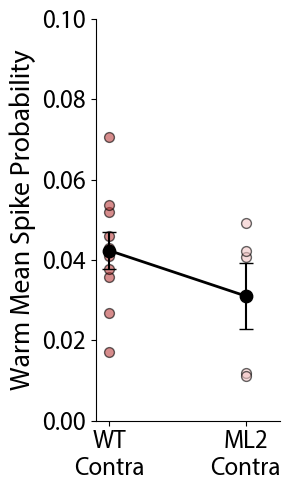

Moyenne et SEM pour:
Groupe: WT_Cont, Mean: 0.042356 ± SEM: 0.004705
Groupe: ML2_Cont, Mean: 0.031028 ± SEM: 0.008114

WT_contra: n_cluster : 422
ML2_contra: n_cluster : 170


In [ ]:
# Charger les fichiers
WT_tac_cont_path = "U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/spyking_analysis/mean_sdf_period_cluster/split_files/Thq-hot_Wcont_WT_grouped.xlsx"
df_WT_tac_cont = pd.read_excel(WT_tac_cont_path)

ML2_tac_cont_path = "U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/spyking_analysis/mean_sdf_period_cluster/split_files/Thq-hot_Wcont_ML2_grouped.xlsx"
df_ML2_tac_cont = pd.read_excel(ML2_tac_cont_path)

# Filtrer pour obtenir uniquement les données où la période est 'Stim'
df_WT_tac_cont_ts = df_WT_tac_cont[df_WT_tac_cont['period'] == 'Stim']
df_ML2_tac_cont_ts = df_ML2_tac_cont[df_ML2_tac_cont['period'] == 'Stim']

# Calculer la moyenne de 'sdf' en groupant par 'directory'
df_WT_tac_cont_grouped = df_WT_tac_cont_ts.groupby('directory')['sdf'].mean().reset_index()
df_ML2_tac_cont_grouped = df_ML2_tac_cont_ts.groupby('directory')['sdf'].mean().reset_index()

# Ajouter une colonne pour différencier les groupes
df_WT_tac_cont_grouped['group'] = 'WT_Cont'
df_ML2_tac_cont_grouped['group'] = 'ML2_Cont'

n_WT_cont = len(df_WT_tac_cont_grouped)
n_ML2_cont = len(df_ML2_tac_cont_grouped)

# Effectuer le test de Wilcoxon pour comparer les groupes 'Cont' et 'Ipsi'
stat, p_value = mannwhitneyu(df_WT_tac_cont_grouped['sdf'], 
                             df_ML2_tac_cont_grouped['sdf'], 
                             alternative='two-sided')


# Afficher les résultats avec n et p-value
print(f"n (WT_Cont) = {n_WT_cont}")
print(f"n (ML2_Cont) = {n_ML2_cont}")
print(f"Wilcoxon test result: statistic = {stat:.4f}, p-value = {p_value:.4f}")


# Fusionner pour le tracé
combined_df_WT_ML2_sdf = pd.concat([df_WT_tac_cont_grouped, df_ML2_tac_cont_grouped])

# Couleurs
colors = {'WT_Cont': '#bb3f3f', 'ML2_Cont': '#F2C7C7'}
border_colors = 'k'


# Création du plot
plt.figure(figsize=(3, 5))

# Ajouter les points individuels pour chaque 'directory'
for group in ['WT_Cont', 'ML2_Cont']:
    subset = combined_df_WT_ML2_sdf[combined_df_WT_ML2_sdf['group'] == group]
    plt.scatter(subset['group'], subset['sdf'], color=colors[group], edgecolor=border_colors, linewidth=1, alpha=0.6, s=50, zorder=6)


# Calcul des moyennes et SEM
mean_sdf = combined_df_WT_ML2_sdf.groupby('group')['sdf'].mean()
sem_sdf = combined_df_WT_ML2_sdf.groupby('group')['sdf'].sem()

# Ajouter les moyennes avec barres d'erreur
plt.scatter(mean_sdf.index, mean_sdf.values, color='black', s=80, label='Mean', zorder=10)
plt.errorbar(mean_sdf.index, mean_sdf.values, yerr=sem_sdf.values, fmt='o', color='black', capsize=5, zorder=8)

# Ajouter la ligne reliant les moyennes
plt.plot(mean_sdf.index, mean_sdf.values, color='k', linestyle='-', linewidth=2, zorder=7)

# Fonction pour ajouter une barre de significativité
def add_mannwhitneyu_sig_bar(x1, x2, y, p_val, height_offset=1.2, fontsize=18):
    if p_val < 0.001:
        significance = "***"
    elif p_val < 0.01:
        significance = "**"
    elif p_val < 0.05:
        significance = "*"
    else:
        return

    plt.plot([x1, x1, x2, x2], [y, y + height_offset, y + height_offset, y], lw=1, color='black')
    plt.text((x1 + x2) * 0.5, y , significance, ha='center', va='bottom', color='black', fontsize=fontsize)

# Ajouter la barre de significativité si p < 0.05
y_max = max(combined_df_WT_ML2_sdf['sdf']) + 0.02  # Ajustement vertical
if p_value < 0.05:
    add_mannwhitneyu_sig_bar(0, 1, y_max + 3, p_value)

# Paramètres des axes
plt.xlabel("")
plt.ylabel("Warm Mean Spike Probability")
plt.xticks([0, 1], ['WT\nContra', 'ML2\nContra'])
plt.xlim(-0.25, 1.25)
plt.ylim(0, 0.1)


# Suppression des bordures superflues
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Afficher le plot
plt.tight_layout()

# Sauvegarder la figure
plt.savefig(os.path.join(saving_dir, '4M_SDF_ML2_vs_WT_TS_warm_cont.png'), format='png', dpi=300)
plt.savefig(os.path.join(saving_dir, '4M_SDF_ML2_vs_WT_TS_warm_cont.svg'), format='svg', dpi=300)


plt.show()

############################    Metrics   ############################ 

# Afficher les résultats
# Afficher les résultats des moyennes et SEM
print("Moyenne et SEM pour:")
for group in ['WT_Cont', 'ML2_Cont']:
    mean = mean_sdf[group]
    sem = sem_sdf[group]
    print(f"Groupe: {group}, Mean: {mean:.6f} ± SEM: {sem:.6f}")

# Calculer nombre cluster par conditions
n_cluster_WT_tac_cont = len(df_WT_tac_cont_ts)
n_cluster_ML2_tac_cont = len(df_ML2_tac_cont_ts)

print(f"\nWT_contra: n_cluster : {n_cluster_WT_tac_cont}")
print(f"ML2_contra: n_cluster : {n_cluster_ML2_tac_cont}")

### Fig 4.M_BIS - Cluster - ML2 vs WT Warm contra SDF


Test de Mann-Whitney : Statistique=41016.5000, p-value=0.0063, n_cont=422, n_ipsi=170


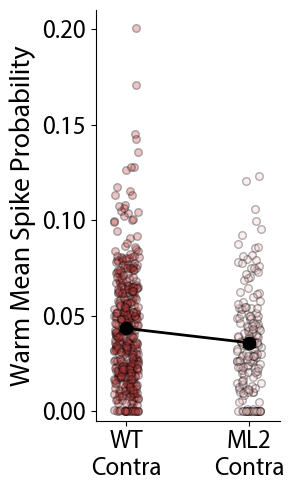

Moyenne et SEM pour chaque groupe :
WT_Warm : 0.043330 ± 0.001464
ML2_Warm : 0.035800 ± 0.002039

WT_Warm : n_cluster = 422
ML2_Warm   : n_cluster = 170


In [16]:
# Charger les fichiers
WT_Warm_cont_path = "U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/spyking_analysis/mean_sdf_period_cluster/split_files/Thq-hot_Wcont_WT_grouped.xlsx"
df_WT_Warm_cont = pd.read_excel(WT_Warm_cont_path)

ML2_Warm_cont_path = "U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/spyking_analysis/mean_sdf_period_cluster/split_files/Thq-hot_Wcont_ML2_grouped.xlsx"
df_ML2_Warm_cont = pd.read_excel(ML2_Warm_cont_path)

# Filtrer pour obtenir uniquement les données où la période est 'Stim'
df_WT_Warm_cont_ts = df_WT_Warm_cont[df_WT_Warm_cont['period'] == 'Stim']
df_ML2_Warm_cont_ts = df_ML2_Warm_cont[df_ML2_Warm_cont['period'] == 'Stim']

# Regrouper par neurone unique et période pour s'assurer d'une entrée unique
df_WT_Warm_cont_ts_cluster = df_WT_Warm_cont_ts.groupby(['directory', 'file_name', 'neuron_id', 'period'], as_index=False, observed=True).mean(numeric_only=True)
df_ML2_Warm_cont_ts_cluster = df_ML2_Warm_cont_ts.groupby(['directory', 'file_name', 'neuron_id', 'period'], as_index=False, observed=True).mean(numeric_only=True)

# Ajouter une colonne pour différencier les groupes
df_WT_Warm_cont_ts_cluster['group'] = 'WT_Warm'
df_ML2_Warm_cont_ts_cluster['group'] = 'ML2_Warm'


# Mann-Whitney test sur les deux groupes
sdf_WT_Warm_cont = df_WT_Warm_cont_ts_cluster['sdf']
sdf_ML2_Warm_cont = df_ML2_Warm_cont_ts_cluster['sdf']

stat_mannwhit, p_value_mannwhit = mannwhitneyu(sdf_WT_Warm_cont, sdf_ML2_Warm_cont, alternative='two-sided')

print(f"\nTest de Mann-Whitney : Statistique={stat_mannwhit:.4f}, p-value={p_value_mannwhit:.4f}, n_cont={len(sdf_WT_Warm_cont)}, n_ipsi={len(sdf_ML2_Warm_cont)}")


# Fusionner pour le tracé
df_combined_Warm_cluster = pd.concat([df_WT_Warm_cont_ts_cluster, df_ML2_Warm_cont_ts_cluster])

# Couleurs
colors = {'WT_Warm': '#bb3f3f', 'ML2_Warm': '#F2C7C7'}

border_colors = 'k'

# Création du plot
plt.figure(figsize=(3, 5))

# Ajouter les points individuels avec léger jitter
group_mapping = {'WT_Warm': 0, 'ML2_Warm': 1}
for group in ['WT_Warm', 'ML2_Warm']:
    subset = df_combined_Warm_cluster[df_combined_Warm_cluster['group'] == group]
    x_vals = np.ones(len(subset)) * group_mapping[group]
    x_vals += np.random.uniform(-0.1, 0.1, size=len(subset))  # jitter horizontal
    plt.scatter(x_vals, subset['sdf'], color=colors[group], edgecolor=border_colors, linewidth=1, alpha=0.3, s=30, zorder=6)

# Calcul des moyennes et SEM
mean_sdf_Warm_cluster = df_combined_Warm_cluster.groupby('group')['sdf'].mean()
sem_sdf_Warm_cluster = df_combined_Warm_cluster.groupby('group')['sdf'].sem()


# Obtenir les positions numériques dans le même ordre que mean_sdf.index
x_pos = [group_mapping[group] for group in mean_sdf_Warm_cluster.index]

# Ajouter les moyennes avec barres d'erreur
plt.scatter(x_pos, mean_sdf_Warm_cluster.values, color='black', s=80, label='Mean', zorder=10)
plt.errorbar(x_pos, mean_sdf_Warm_cluster.values, yerr=sem_sdf_Warm_cluster.values, fmt='o', color='black', capsize=5, zorder=8)

# Ajouter la ligne reliant les moyennes
plt.plot(x_pos, mean_sdf_Warm_cluster.values, color='k', linestyle='-', linewidth=2, zorder=7)



# # Ajouter la barre de significativité
# def add_MannWhitney_sig_bar(x1, x2, y, p_value_mannwhit, height_offset=0.005, fontsize=18):
#     if p_value_mannwhit < 0.001:
#         significance = "***"
#     elif p_value_mannwhit < 0.01:
#         significance = "**"
#     elif p_value_mannwhit < 0.05:
#         significance = "*"
#     else:
#         return
#     plt.plot([x1, x1, x2, x2], [y, y + height_offset, y + height_offset, y], lw=1, color='black')
#     plt.text((x1 + x2) * 0.5, y + height_offset, significance, ha='center', va='bottom', color='black', fontsize=fontsize)

# # Ajouter si p < 0.05
# y_max = max(df_combined_Warm_cluster['sdf']) + 0.02
# if p_value_mannwhit < 0.05:
#     add_MannWhitney_sig_bar(0, 1, y_max, p_value_mannwhit)

# Mise en forme
plt.xlabel("")
plt.ylabel("Warm Mean Spike Probability")
plt.xticks([0, 1], ['WT\nContra', 'ML2\nContra'])
plt.xlim(-0.25, 1.25)
plt.ylim(-0.005, 0.21)

# Nettoyer les bords
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

# Sauvegarder la figure
plt.savefig(os.path.join(saving_dir, '4M_BIS_SDF_ML2_vs_WT_TS_warm_cont_cluster.png'), format='png', dpi=300)
plt.savefig(os.path.join(saving_dir, '4M_BIS_SDF_ML2_vs_WT_TS_warm_cont_cluster.svg'), format='svg', dpi=300)



plt.show()


############################    Metrics   ############################ 
print("Moyenne et SEM pour chaque groupe :")
for group in ['WT_Warm', 'ML2_Warm']:
    mean = mean_sdf_Warm_cluster[group]
    sem = sem_sdf_Warm_cluster[group]
    print(f"{group} : {mean:.6f} ± {sem:.6f}")

# Nombre de clusters
n_cluster_WT_Warm = len(df_WT_Warm_cont_ts)
n_cluster_ML2_Warm = len(df_ML2_Warm_cont_ts)
print(f"\nWT_Warm : n_cluster = {n_cluster_WT_Warm}")
print(f"ML2_Warm   : n_cluster = {n_cluster_ML2_Warm}")
